# PAD-UFES — Análise Exploratória de Dados
Dataset de lesões cutâneas com metadados clínicos e imagens dermatoscópicas.

In [1]:
import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from PIL import Image

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', None)

CLASS_ORDER  = ['ACK', 'BCC', 'MEL', 'NEV', 'SCC', 'SEK']
CLASS_COLORS = dict(zip(CLASS_ORDER, sns.color_palette('tab10', len(CLASS_ORDER))))

MALIGNANT = ['BCC', 'SCC', 'MEL']
BENIGN    = ['ACK', 'NEV', 'SEK']

CLASS_LABELS = {
    'ACK': 'Actinic Keratosis',
    'BCC': 'Basal Cell Carcinoma',
    'MEL': 'Melanoma',
    'NEV': 'Nevus',
    'SCC': 'Squamous Cell Carcinoma',
    'SEK': 'Seborrheic Keratosis'
}

In [2]:
BASE_DIR   = Path('..') / 'data' / 'raw'
METADATA   = BASE_DIR / 'metadata.csv'
IMAGES_DIR = BASE_DIR / 'images'

print(f'Metadata : {METADATA.resolve()}')
print(f'Imagens  : {IMAGES_DIR.resolve()}')
print(f'Metadata existe        : {METADATA.exists()}')
print(f'Pasta de imagens existe: {IMAGES_DIR.exists()}')

Metadata : /home/icaro/Documentos/projeto_pad_ufes/data/raw/metadata.csv
Imagens  : /home/icaro/Documentos/projeto_pad_ufes/data/raw/images
Metadata existe        : True
Pasta de imagens existe: True


## 1. Carregamento e Integração

In [3]:
df = pd.read_csv(METADATA)

bool_cols = [
    'smoke', 'drink', 'pesticide', 'skin_cancer_history', 'cancer_history',
    'has_piped_water', 'has_sewage_system', 'itch', 'grew', 'hurt',
    'changed', 'bleed', 'elevation', 'biopsed'
]
for col in bool_cols:
    df[col] = df[col].map({'True': True, 'False': False, True: True, False: False})

df['age']         = pd.to_numeric(df['age'],         errors='coerce')
df['diameter_1']  = pd.to_numeric(df['diameter_1'],  errors='coerce')
df['diameter_2']  = pd.to_numeric(df['diameter_2'],  errors='coerce')
df['fitspatrick'] = pd.to_numeric(df['fitspatrick'], errors='coerce')

df['grupo'] = df['diagnostic'].apply(lambda x: 'Maligno' if x in MALIGNANT else 'Benigno')

def resolve_image(img_id):
    path = IMAGES_DIR / img_id
    return str(path) if path.exists() else None

df['img_path'] = df['img_id'].apply(resolve_image)
df = df.dropna(subset=['img_path']).reset_index(drop=True)

print(f'Shape final: {df.shape}')
df.head(3)

Shape final: (2298, 28)


,patient_id,lesion_id,smoke,drink,background_father,background_mother,age,pesticide,gender,skin_cancer_history,cancer_history,has_piped_water,has_sewage_system,fitspatrick,region,diameter_1,diameter_2,diagnostic,itch,grew,hurt,changed,bleed,elevation,img_id,biopsed,grupo,img_path
0,PAT_1516,1765,NaN,NaN,NaN,NaN,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ARM,NaN,NaN,NEV,False,False,False,False,False,False,PAT_1516_1765_530.png,False,Benigno,../data/raw/images/PAT_1516_1765_530.png
1,PAT_46,881,False,False,POMERANIA,POMERANIA,55,False,FEMALE,True,True,True,True,3.0,NECK,6.0,5.0,BCC,True,True,False,True,True,True,PAT_46_881_939.png,True,Maligno,../data/raw/images/PAT_46_881_939.png
2,PAT_1545,1867,NaN,NaN,NaN,NaN,77,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FACE,NaN,NaN,ACK,True,False,False,False,False,False,PAT_1545_1867_547.png,False,Benigno,../data/raw/images/PAT_1545_1867_547.png


---
## EDA — Parte 1: Variável Alvo e Desbalanceamento

In [4]:
target_counts = df['diagnostic'].value_counts().reindex(CLASS_ORDER)
target_pct    = (target_counts / len(df) * 100).round(1)

print('Distribuição por classe:')
for cls in CLASS_ORDER:
    grp = 'Maligno' if cls in MALIGNANT else 'Benigno '
    print(f'  {cls} ({grp}) — {CLASS_LABELS[cls]:<26}: {target_counts[cls]:>4}  ({target_pct[cls]:>5.1f}%)')

print(f'\nRatio majoritária/minoritária: {target_counts.max()/target_counts.min():.1f}x  '
      f'({target_counts.idxmax()} vs {target_counts.idxmin()})')

grp_counts = df['grupo'].value_counts()
print(f'\nBenigno : {grp_counts.get("Benigno",0)} ({grp_counts.get("Benigno",0)/len(df)*100:.1f}%)')
print(f'Maligno : {grp_counts.get("Maligno",0)} ({grp_counts.get("Maligno",0)/len(df)*100:.1f}%)')

Distribuição por classe:
  ACK (Benigno ) — Actinic Keratosis         :  730  ( 31.8%)
  BCC (Maligno) — Basal Cell Carcinoma      :  845  ( 36.8%)
  MEL (Maligno) — Melanoma                  :   52  (  2.3%)
  NEV (Benigno ) — Nevus                     :  244  ( 10.6%)
  SCC (Maligno) — Squamous Cell Carcinoma   :  192  (  8.4%)
  SEK (Benigno ) — Seborrheic Keratosis      :  235  ( 10.2%)

Ratio majoritária/minoritária: 16.2x  (BCC vs MEL)

Benigno : 1209 (52.6%)
Maligno : 1089 (47.4%)


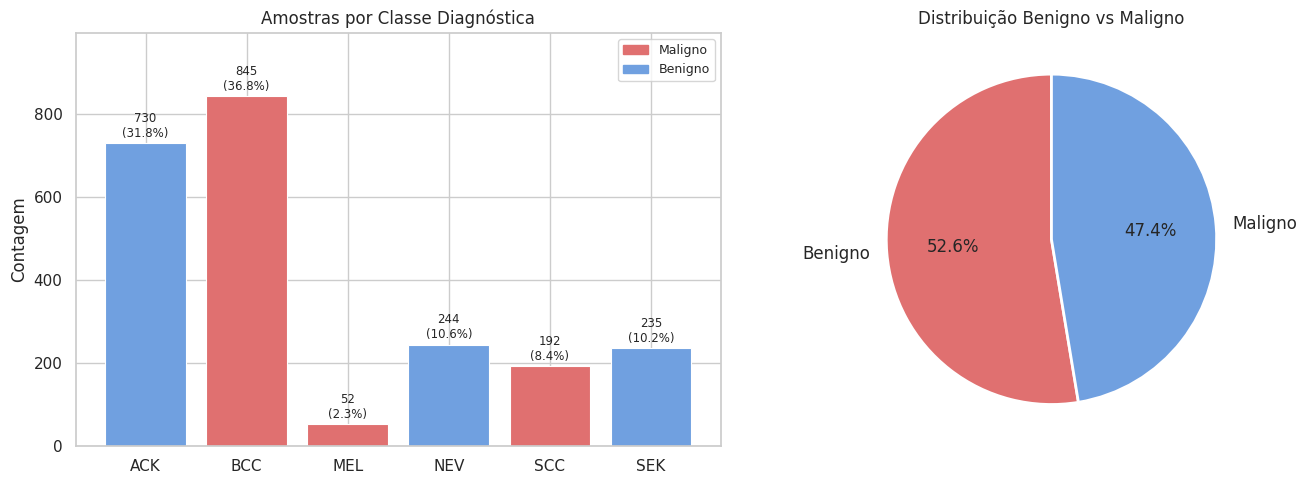

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart por classe
bar_colors = ['#e07070' if c in MALIGNANT else '#70a0e0' for c in CLASS_ORDER]
bars = axes[0].bar(CLASS_ORDER, target_counts, color=bar_colors, edgecolor='white', linewidth=0.8)
for bar, cnt, pct in zip(bars, target_counts, target_pct):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
                 f'{cnt}\n({pct}%)', ha='center', va='bottom', fontsize=8.5)
axes[0].set_title('Amostras por Classe Diagnóstica', fontsize=12)
axes[0].set_ylabel('Contagem')
axes[0].set_xlabel('')
from matplotlib.patches import Patch
legend_els = [Patch(color='#e07070', label='Maligno'), Patch(color='#70a0e0', label='Benigno')]
axes[0].legend(handles=legend_els, fontsize=9)
axes[0].set_ylim(0, target_counts.max() * 1.18)

# Pie: benigno vs maligno
axes[1].pie(grp_counts, labels=grp_counts.index, autopct='%1.1f%%',
            colors=['#e07070', '#70a0e0'], startangle=90,
            textprops={'fontsize': 12},
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Distribuição Benigno vs Maligno', fontsize=12)

plt.tight_layout()
plt.show()

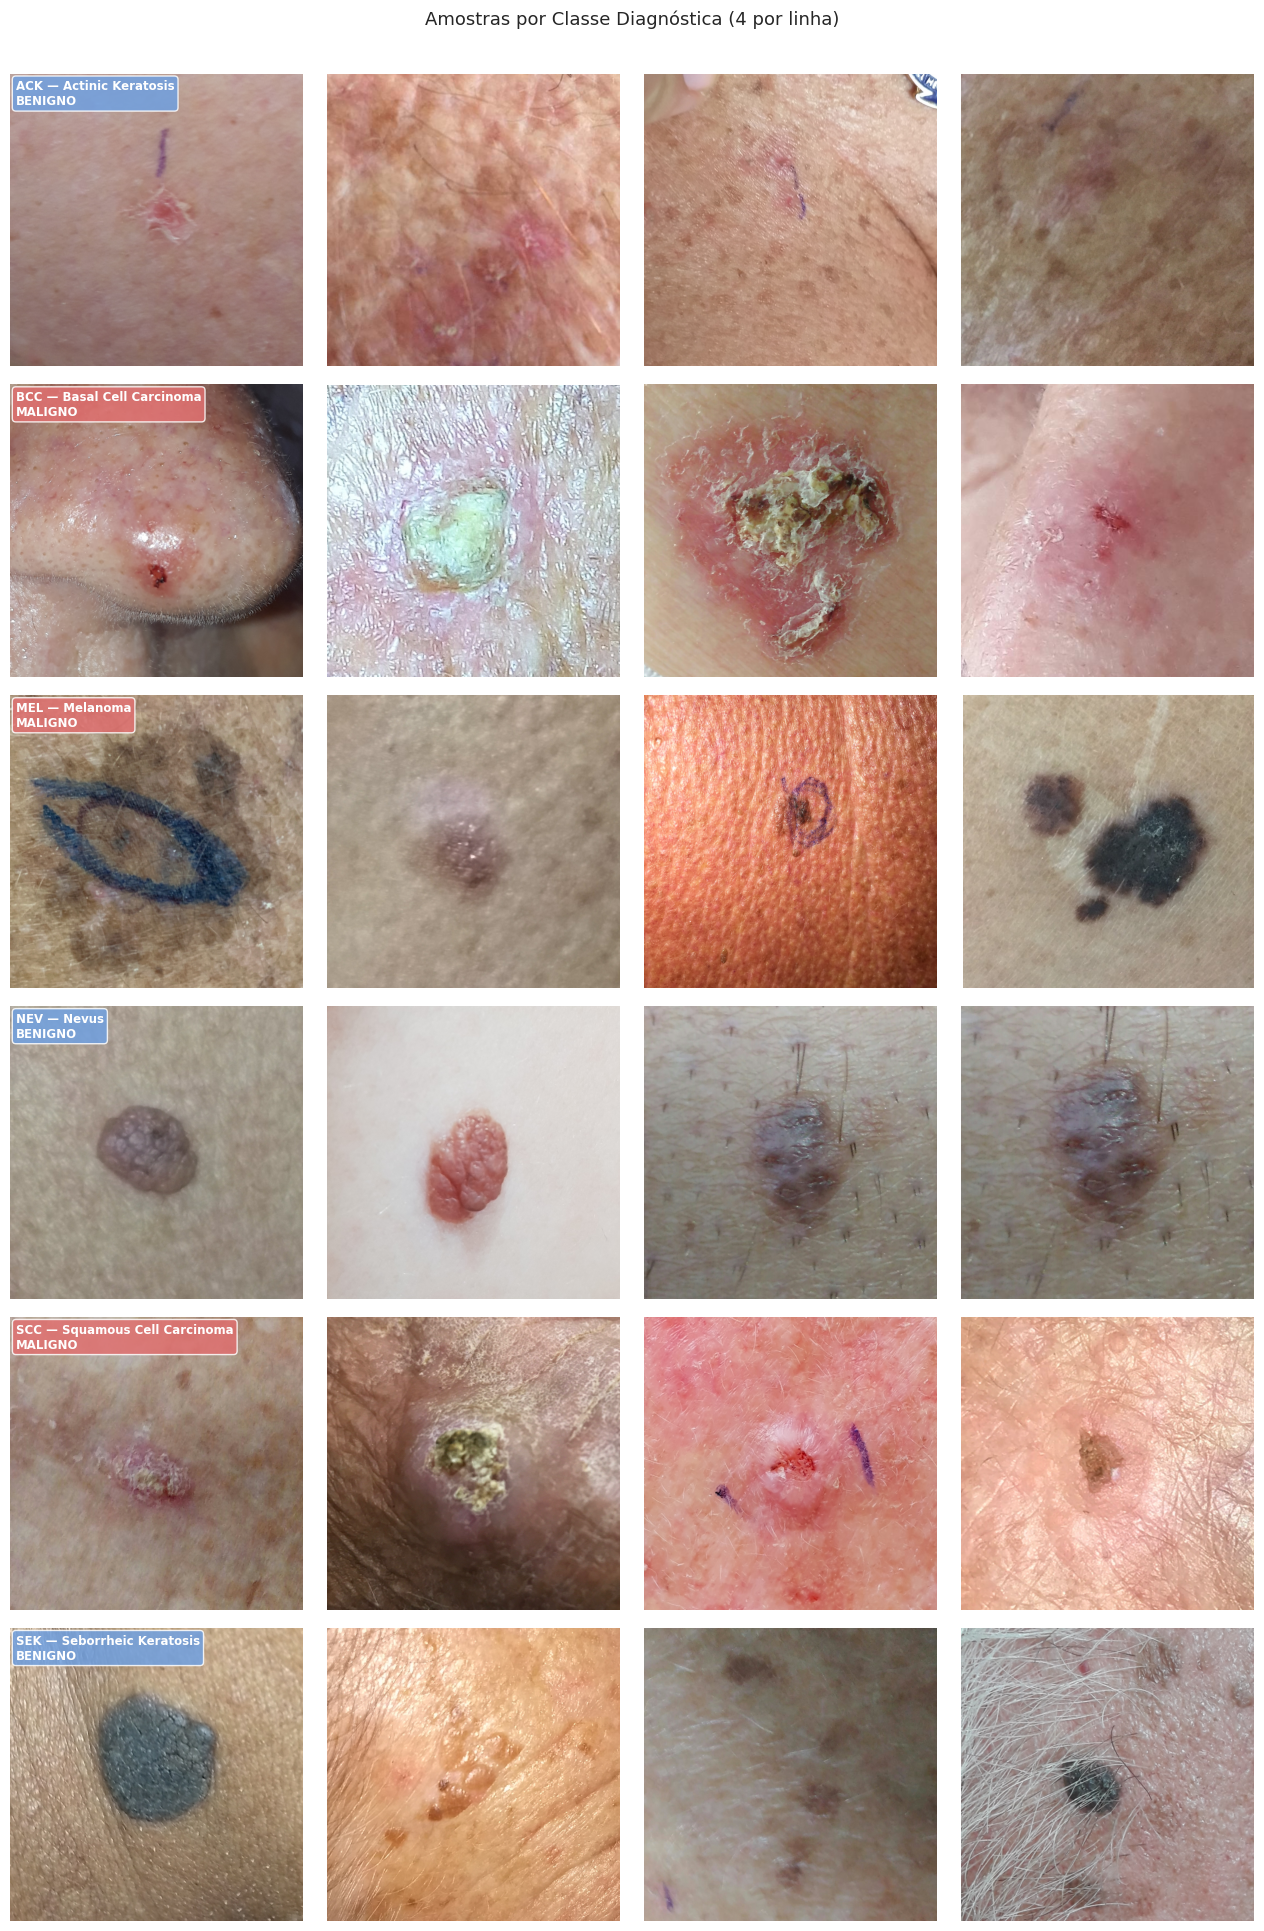

In [6]:
# Grade de amostras — 4 por classe, com nome da classe e diagnóstico completo
N_SAMPLES = 4
fig, axes = plt.subplots(len(CLASS_ORDER), N_SAMPLES,
                          figsize=(N_SAMPLES * 3.2, len(CLASS_ORDER) * 3.2))

for row, cls in enumerate(CLASS_ORDER):
    subset = df[df['diagnostic'] == cls].sample(
        min(N_SAMPLES, len(df[df['diagnostic'] == cls])), random_state=42
    )
    grp_label = 'MALIGNO' if cls in MALIGNANT else 'BENIGNO'
    grp_color = '#e07070' if cls in MALIGNANT else '#70a0e0'

    for col, (_, sample) in enumerate(subset.iterrows()):
        img = mpimg.imread(sample['img_path'])
        axes[row, col].imshow(img)
        axes[row, col].axis('off')

        # Nome da classe na primeira imagem de cada linha
        if col == 0:
            axes[row, col].text(
                0.02, 0.98,
                f'{cls} — {CLASS_LABELS[cls]}\n{grp_label}',
                transform=axes[row, col].transAxes,
                fontsize=8.5, fontweight='bold',
                color='white', va='top', ha='left',
                bbox=dict(boxstyle='round,pad=0.3', facecolor=grp_color, alpha=0.85)
            )

plt.suptitle('Amostras por Classe Diagnóstica (4 por linha)', fontsize=13, y=1.005)
plt.tight_layout()
plt.show()

---
## EDA — Parte 2: Valores Ausentes

In [7]:
null_info = pd.DataFrame({
    'nulos'   : df.isnull().sum(),
    'nulos_%' : (df.isnull().mean() * 100).round(1)
}).sort_values('nulos_%', ascending=False)
null_info = null_info[null_info['nulos'] > 0]

print(f'Colunas sem nenhum nulo : {(df.isnull().sum() == 0).sum()}')
print(f'Colunas com algum nulo  : {len(null_info)}')
print()
print(null_info.to_string())

Colunas sem nenhum nulo : 9
Colunas com algum nulo  : 19

                     nulos  nulos_%
background_mother      822     35.8
background_father      818     35.6
drink                  804     35.0
smoke                  804     35.0
cancer_history         804     35.0
skin_cancer_history    804     35.0
pesticide              804     35.0
gender                 804     35.0
has_piped_water        804     35.0
diameter_1             804     35.0
fitspatrick            804     35.0
has_sewage_system      804     35.0
diameter_2             804     35.0
grew                   402     17.5
changed                396     17.2
hurt                    10      0.4
bleed                    6      0.3
itch                     6      0.3
elevation                2      0.1


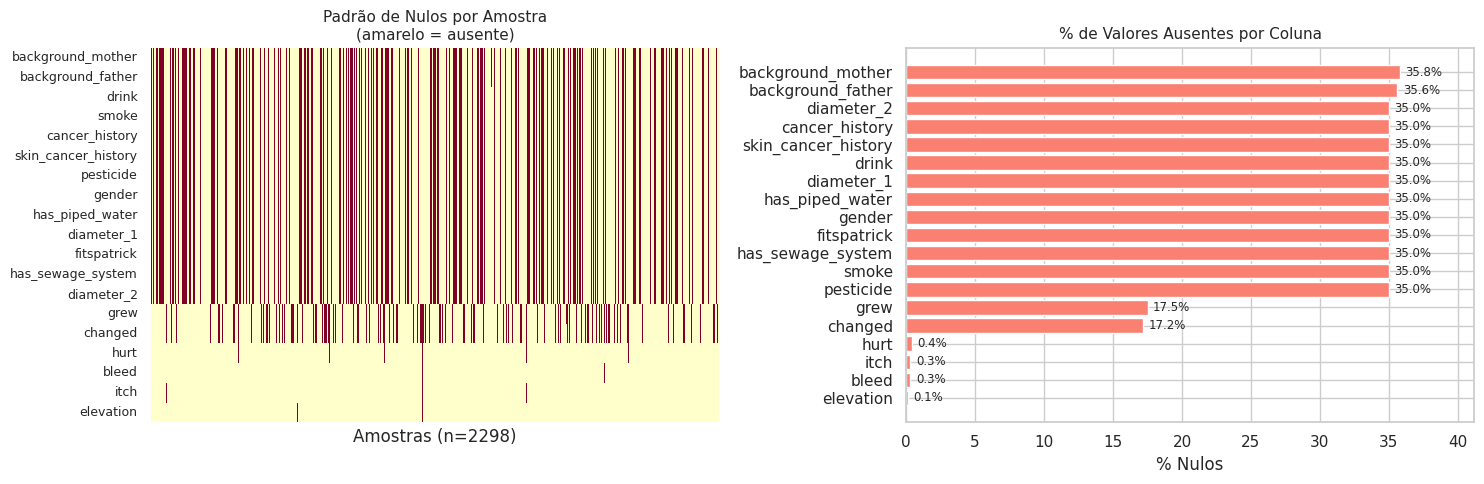

In [8]:
cols_with_nulls = null_info.index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Heatmap do padrão de nulos
null_matrix = df[cols_with_nulls].isnull().astype(int)
sns.heatmap(null_matrix.T, ax=axes[0], cbar=False,
            yticklabels=cols_with_nulls, xticklabels=False,
            cmap='YlOrRd')
axes[0].set_title('Padrão de Nulos por Amostra\n(amarelo = ausente)', fontsize=11)
axes[0].set_xlabel(f'Amostras (n={len(df)})')
axes[0].tick_params(axis='y', labelsize=9)

# Bar chart % missing
null_pct_sorted = null_info['nulos_%'].sort_values(ascending=True)
bars = axes[1].barh(null_pct_sorted.index, null_pct_sorted.values, color='salmon', edgecolor='white')
axes[1].set_title('% de Valores Ausentes por Coluna', fontsize=11)
axes[1].set_xlabel('% Nulos')
for bar, v in zip(bars, null_pct_sorted.values):
    axes[1].text(v + 0.4, bar.get_y() + bar.get_height()/2,
                 f'{v:.1f}%', va='center', fontsize=8.5)
axes[1].set_xlim(0, null_pct_sorted.max() * 1.15)

plt.tight_layout()
plt.show()

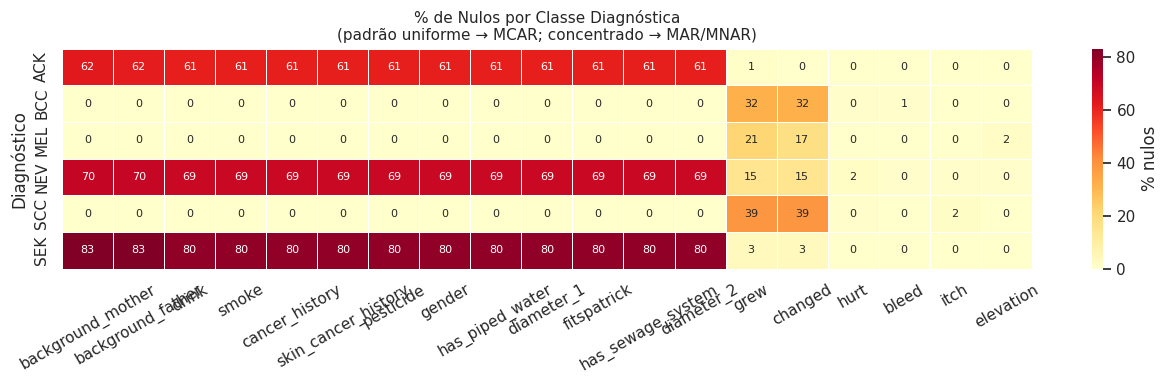

In [9]:
# Nulos por classe: o dado ausente é aleatório ou concentrado em algum diagnóstico?
null_by_class = df.groupby('diagnostic')[cols_with_nulls].apply(
    lambda g: g.isnull().mean() * 100
).round(1)

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(null_by_class, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': '% nulos'},
            annot_kws={'size': 8})
ax.set_title('% de Nulos por Classe Diagnóstica\n(padrão uniforme → MCAR; concentrado → MAR/MNAR)', fontsize=11)
ax.set_ylabel('Diagnóstico')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

---
## EDA — Parte 3: Features Numéricas

In [10]:
num_cols = ['age', 'diameter_1', 'diameter_2', 'fitspatrick']
print(df[num_cols].describe().round(2))

           age  diameter_1  diameter_2  fitspatrick
count  2298.00     1494.00     1494.00      1494.00
mean     60.46       11.90        8.85         2.27
std      15.89        8.63        5.80         0.73
min       6.00        0.00        0.00         1.00
25%      52.00        7.00        5.00         2.00
50%      62.00       10.00        8.00         2.00
75%      72.00       15.00       10.00         3.00
max      94.00      100.00       70.00         6.00


/tmp/ipykernel_88096/172133941.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diagnostic', y='age', order=CLASS_ORDER,


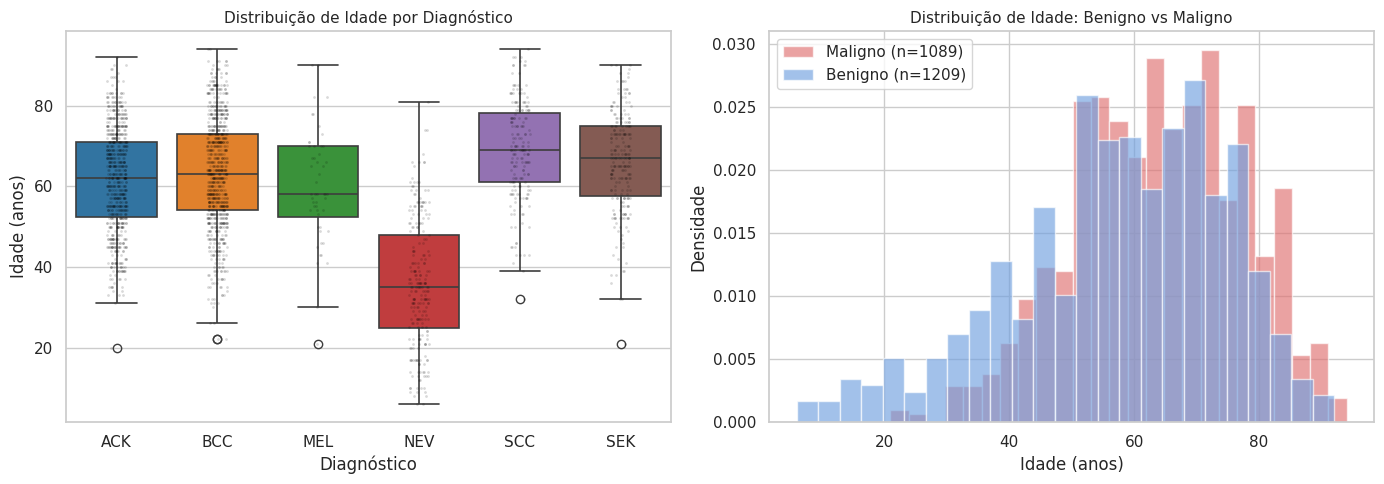

In [11]:
# Idade por classe e por grupo
palette = [CLASS_COLORS[c] for c in CLASS_ORDER]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='diagnostic', y='age', order=CLASS_ORDER,
            palette=palette, ax=axes[0], linewidth=1.2)
sns.stripplot(data=df, x='diagnostic', y='age', order=CLASS_ORDER,
              color='black', alpha=0.15, size=2, ax=axes[0], jitter=True)
axes[0].set_title('Distribuição de Idade por Diagnóstico', fontsize=11)
axes[0].set_xlabel('Diagnóstico')
axes[0].set_ylabel('Idade (anos)')

for grp, color in [('Maligno', '#e07070'), ('Benigno', '#70a0e0')]:
    subset = df[df['grupo'] == grp]['age'].dropna()
    axes[1].hist(subset, bins=25, alpha=0.65, label=f'{grp} (n={len(subset)})',
                 color=color, density=True, edgecolor='white')
axes[1].set_title('Distribuição de Idade: Benigno vs Maligno', fontsize=11)
axes[1].set_xlabel('Idade (anos)')
axes[1].set_ylabel('Densidade')
axes[1].legend()

plt.tight_layout()
plt.show()

/tmp/ipykernel_88096/3363987652.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diagnostic', y=col, order=CLASS_ORDER,
/tmp/ipykernel_88096/3363987652.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diagnostic', y=col, order=CLASS_ORDER,


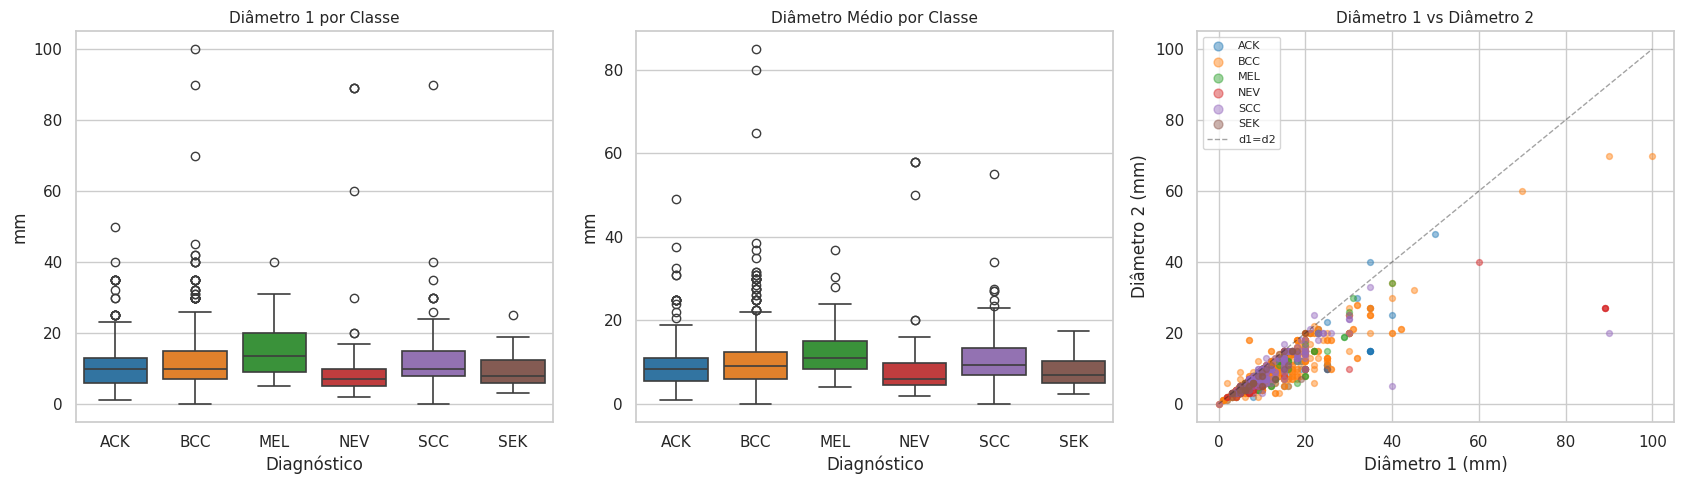

In [12]:
# Diâmetros
df['diameter_mean'] = (df['diameter_1'] + df['diameter_2']) / 2

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, col, title in [
    (axes[0], 'diameter_1',    'Diâmetro 1 por Classe'),
    (axes[1], 'diameter_mean', 'Diâmetro Médio por Classe'),
]:
    sns.boxplot(data=df, x='diagnostic', y=col, order=CLASS_ORDER,
                palette=palette, ax=ax, linewidth=1.2)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Diagnóstico')
    ax.set_ylabel('mm')

# Scatter diameter_1 vs diameter_2
for cls in CLASS_ORDER:
    sub = df[df['diagnostic'] == cls]
    axes[2].scatter(sub['diameter_1'], sub['diameter_2'],
                    c=[CLASS_COLORS[cls]], label=cls, alpha=0.45, s=18)
# Linha de referência y=x (diâmetros iguais)
lim = df[['diameter_1','diameter_2']].max().max()
axes[2].plot([0, lim], [0, lim], 'k--', alpha=0.4, linewidth=1, label='d1=d2')
axes[2].set_title('Diâmetro 1 vs Diâmetro 2', fontsize=11)
axes[2].set_xlabel('Diâmetro 1 (mm)')
axes[2].set_ylabel('Diâmetro 2 (mm)')
axes[2].legend(fontsize=8, markerscale=1.5)

plt.tight_layout()
plt.show()

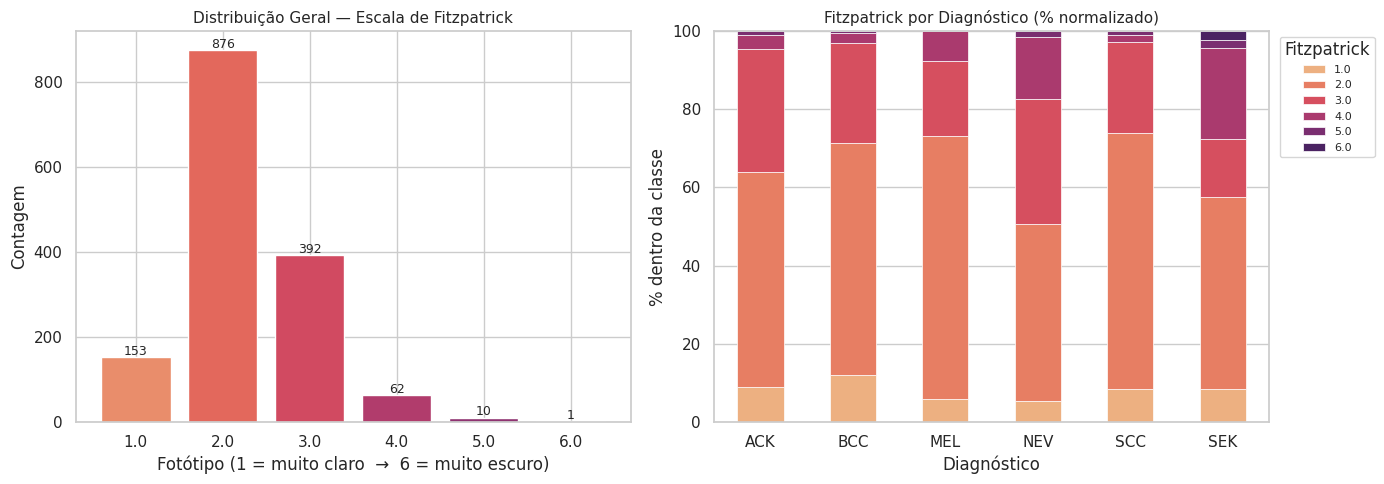

In [13]:
# Escala de Fitzpatrick
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuição geral
fitz_dist = df['fitspatrick'].value_counts().sort_index()
axes[0].bar(fitz_dist.index.astype(str), fitz_dist.values,
            color=sns.color_palette('flare', len(fitz_dist)), edgecolor='white')
axes[0].set_title('Distribuição Geral — Escala de Fitzpatrick', fontsize=11)
axes[0].set_xlabel('Fotótipo (1 = muito claro  →  6 = muito escuro)')
axes[0].set_ylabel('Contagem')
for i, (idx, v) in enumerate(fitz_dist.items()):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=9)

# % por classe (stacked normalizado)
fitz_cls = df.groupby(['diagnostic', 'fitspatrick']).size().unstack(fill_value=0)
fitz_pct = fitz_cls.div(fitz_cls.sum(axis=1), axis=0) * 100
fitz_pct.reindex(CLASS_ORDER).plot(
    kind='bar', stacked=True, ax=axes[1],
    colormap='flare', edgecolor='white', linewidth=0.5
)
axes[1].set_title('Fitzpatrick por Diagnóstico (% normalizado)', fontsize=11)
axes[1].set_xlabel('Diagnóstico')
axes[1].set_ylabel('% dentro da classe')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Fitzpatrick', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

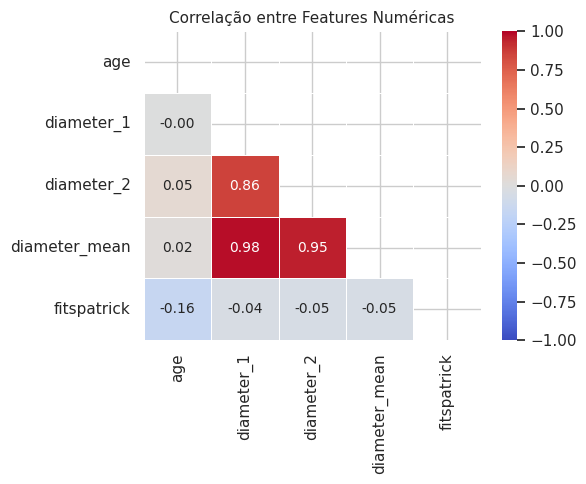

In [14]:
# Correlação entre features numéricas
corr_df = df[['age', 'diameter_1', 'diameter_2', 'diameter_mean', 'fitspatrick']].corr()

fig, ax = plt.subplots(figsize=(6, 5))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, ax=ax, vmin=-1, vmax=1,
            linewidths=0.5, annot_kws={'size': 10})
ax.set_title('Correlação entre Features Numéricas', fontsize=11)
plt.tight_layout()
plt.show()

---
## EDA — Parte 4: Features Categóricas e Booleanas

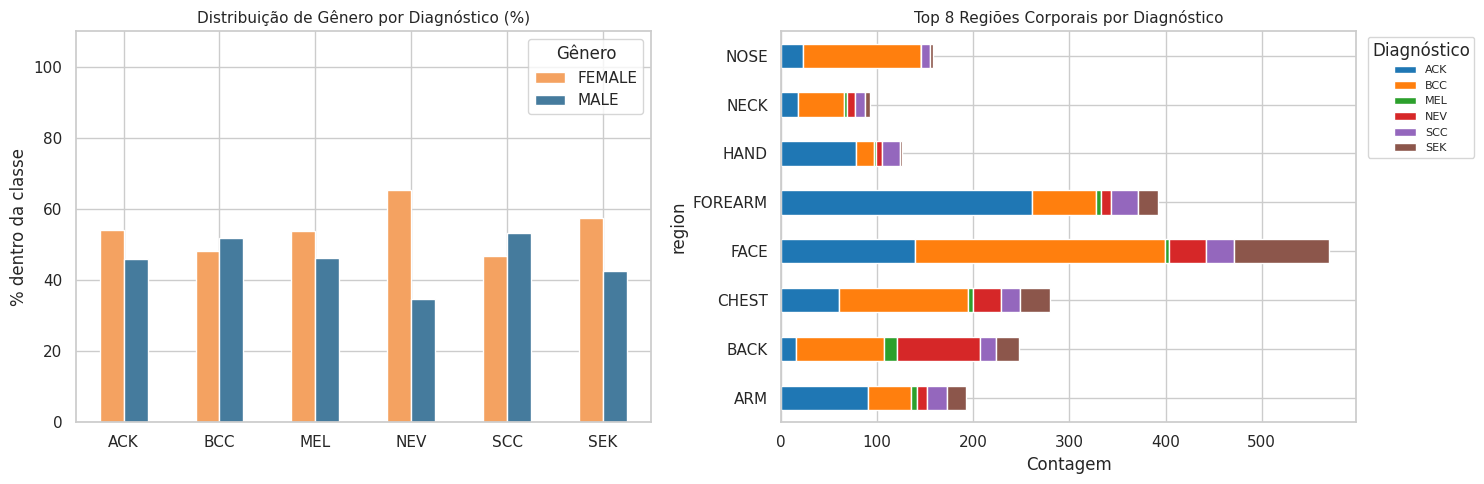

In [15]:
# Gênero e Região
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

gender_cls = df.groupby(['diagnostic', 'gender']).size().unstack(fill_value=0)
gender_pct = gender_cls.div(gender_cls.sum(axis=1), axis=0) * 100
gender_pct.reindex(CLASS_ORDER).plot(
    kind='bar', ax=axes[0], color=['#f4a261', '#457b9d'], edgecolor='white'
)
axes[0].set_title('Distribuição de Gênero por Diagnóstico (%)', fontsize=11)
axes[0].set_xlabel('')
axes[0].set_ylabel('% dentro da classe')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Gênero')
axes[0].set_ylim(0, 110)

# Top regiões — contagem absoluta por classe
top_regions = df['region'].value_counts().head(8).index
region_counts = (
    df[df['region'].isin(top_regions)]
    .groupby(['region', 'diagnostic']).size().unstack(fill_value=0)
    .reindex(columns=CLASS_ORDER, fill_value=0)
)
region_counts.plot(kind='barh', ax=axes[1], stacked=True,
                   color=[CLASS_COLORS[c] for c in CLASS_ORDER], edgecolor='white')
axes[1].set_title('Top 8 Regiões Corporais por Diagnóstico', fontsize=11)
axes[1].set_xlabel('Contagem')
axes[1].legend(title='Diagnóstico', fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

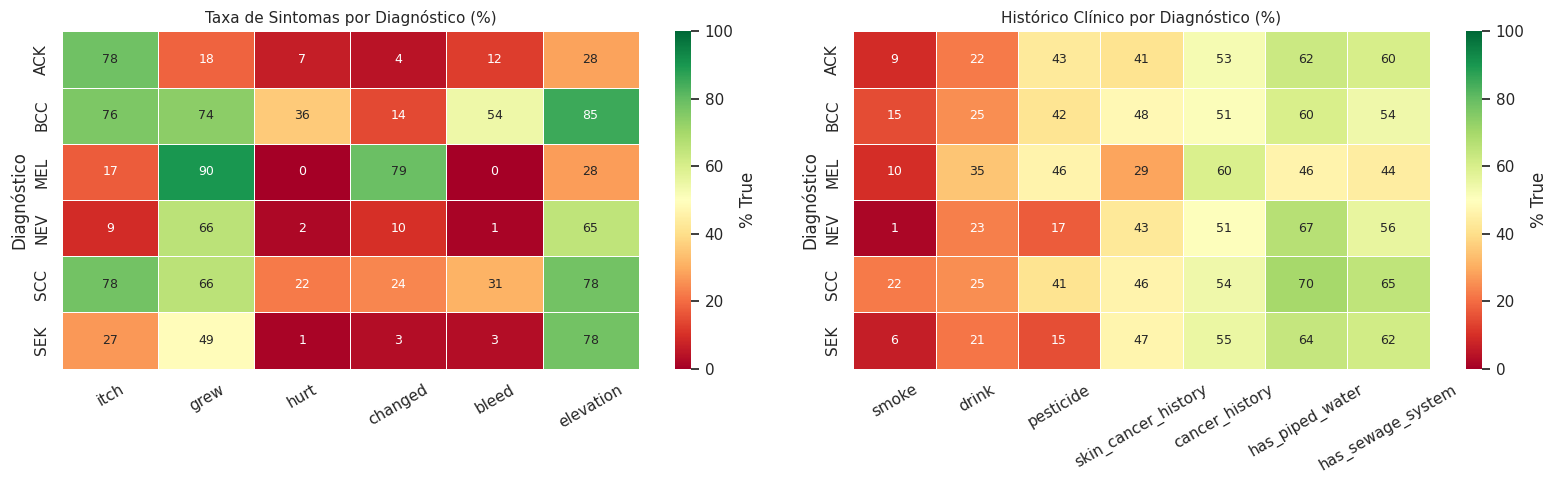

In [16]:
# Heatmaps de features booleanas: taxa de True por classe
symptom_cols = ['itch', 'grew', 'hurt', 'changed', 'bleed', 'elevation']
history_cols = ['smoke', 'drink', 'pesticide', 'skin_cancer_history',
                'cancer_history', 'has_piped_water', 'has_sewage_system']

def bool_rate_by_class(cols):
    return df.groupby('diagnostic')[cols].apply(
        lambda g: g.mean(skipna=True) * 100
    ).round(1).reindex(CLASS_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, cols, title in [
    (axes[0], symptom_cols, 'Taxa de Sintomas por Diagnóstico (%)'),
    (axes[1], history_cols, 'Histórico Clínico por Diagnóstico (%)'),
]:
    rates = bool_rate_by_class(cols)
    sns.heatmap(rates, annot=True, fmt='.0f', cmap='RdYlGn',
                linewidths=0.5, ax=ax, vmin=0, vmax=100,
                cbar_kws={'label': '% True'},
                annot_kws={'size': 9})
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Diagnóstico')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

---
## EDA — Parte 5: Análise das Imagens
> Relevante para orientar a extração de features de PDI.

In [17]:
# Dimensões das imagens
print('Coletando dimensões (pode levar alguns segundos)...')
sizes = [Image.open(p).size for p in df['img_path']]
df['img_width']  = [s[0] for s in sizes]
df['img_height'] = [s[1] for s in sizes]

n_unique = df.groupby(['img_width', 'img_height']).ngroups
n_square = (df['img_width'] == df['img_height']).sum()

print(f'\nTamanhos únicos : {n_unique}')
print(f'Imagens quadradas: {n_square} / {len(df)} ({n_square/len(df)*100:.1f}%)')
print(f'Width  — min: {df["img_width"].min()}  max: {df["img_width"].max()}  '
      f'mediana: {int(df["img_width"].median())}  p5: {int(df["img_width"].quantile(0.05))}  p95: {int(df["img_width"].quantile(0.95))}')
print(f'Height — min: {df["img_height"].min()}  max: {df["img_height"].max()}  '
      f'mediana: {int(df["img_height"].median())}  p5: {int(df["img_height"].quantile(0.05))}  p95: {int(df["img_height"].quantile(0.95))}')

Coletando dimensões (pode levar alguns segundos)...

Tamanhos únicos : 1450
Imagens quadradas: 1876 / 2298 (81.6%)
Width  — min: 147  max: 3474  mediana: 779  p5: 302  p95: 2025
Height — min: 147  max: 3476  mediana: 779  p5: 303  p95: 2025


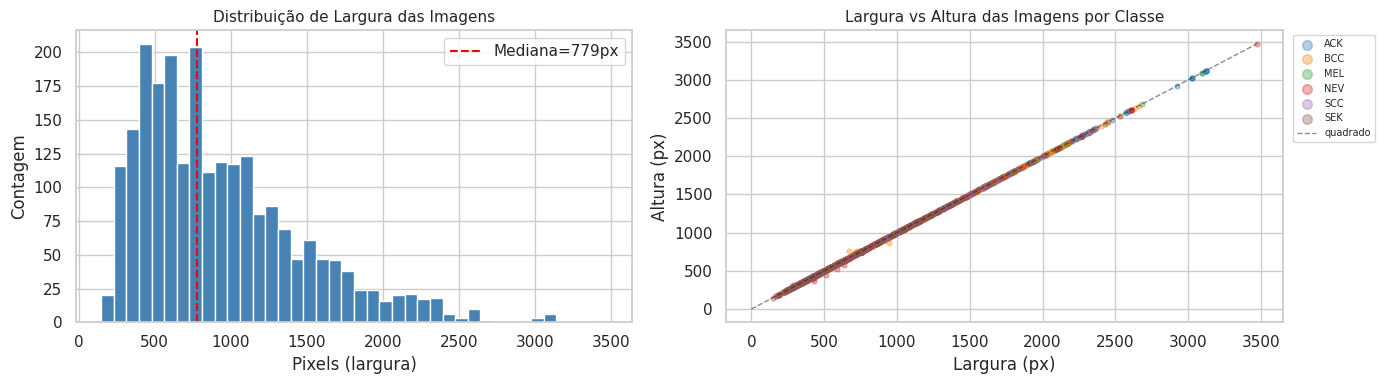

In [18]:
# Distribuição de tamanhos
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['img_width'], bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(df['img_width'].median(), color='red', linestyle='--', label=f'Mediana={int(df["img_width"].median())}px')
axes[0].set_title('Distribuição de Largura das Imagens', fontsize=11)
axes[0].set_xlabel('Pixels (largura)')
axes[0].set_ylabel('Contagem')
axes[0].legend()

# Scatter width x height para ver padrão de proporção
for cls in CLASS_ORDER:
    sub = df[df['diagnostic'] == cls]
    axes[1].scatter(sub['img_width'], sub['img_height'],
                    c=[CLASS_COLORS[cls]], label=cls, alpha=0.35, s=12)
lim = max(df['img_width'].max(), df['img_height'].max())
axes[1].plot([0, lim], [0, lim], 'k--', alpha=0.5, linewidth=1, label='quadrado')
axes[1].set_title('Largura vs Altura das Imagens por Classe', fontsize=11)
axes[1].set_xlabel('Largura (px)')
axes[1].set_ylabel('Altura (px)')
axes[1].legend(fontsize=7, markerscale=2, bbox_to_anchor=(1.01,1), loc='upper left')

plt.tight_layout()
plt.show()

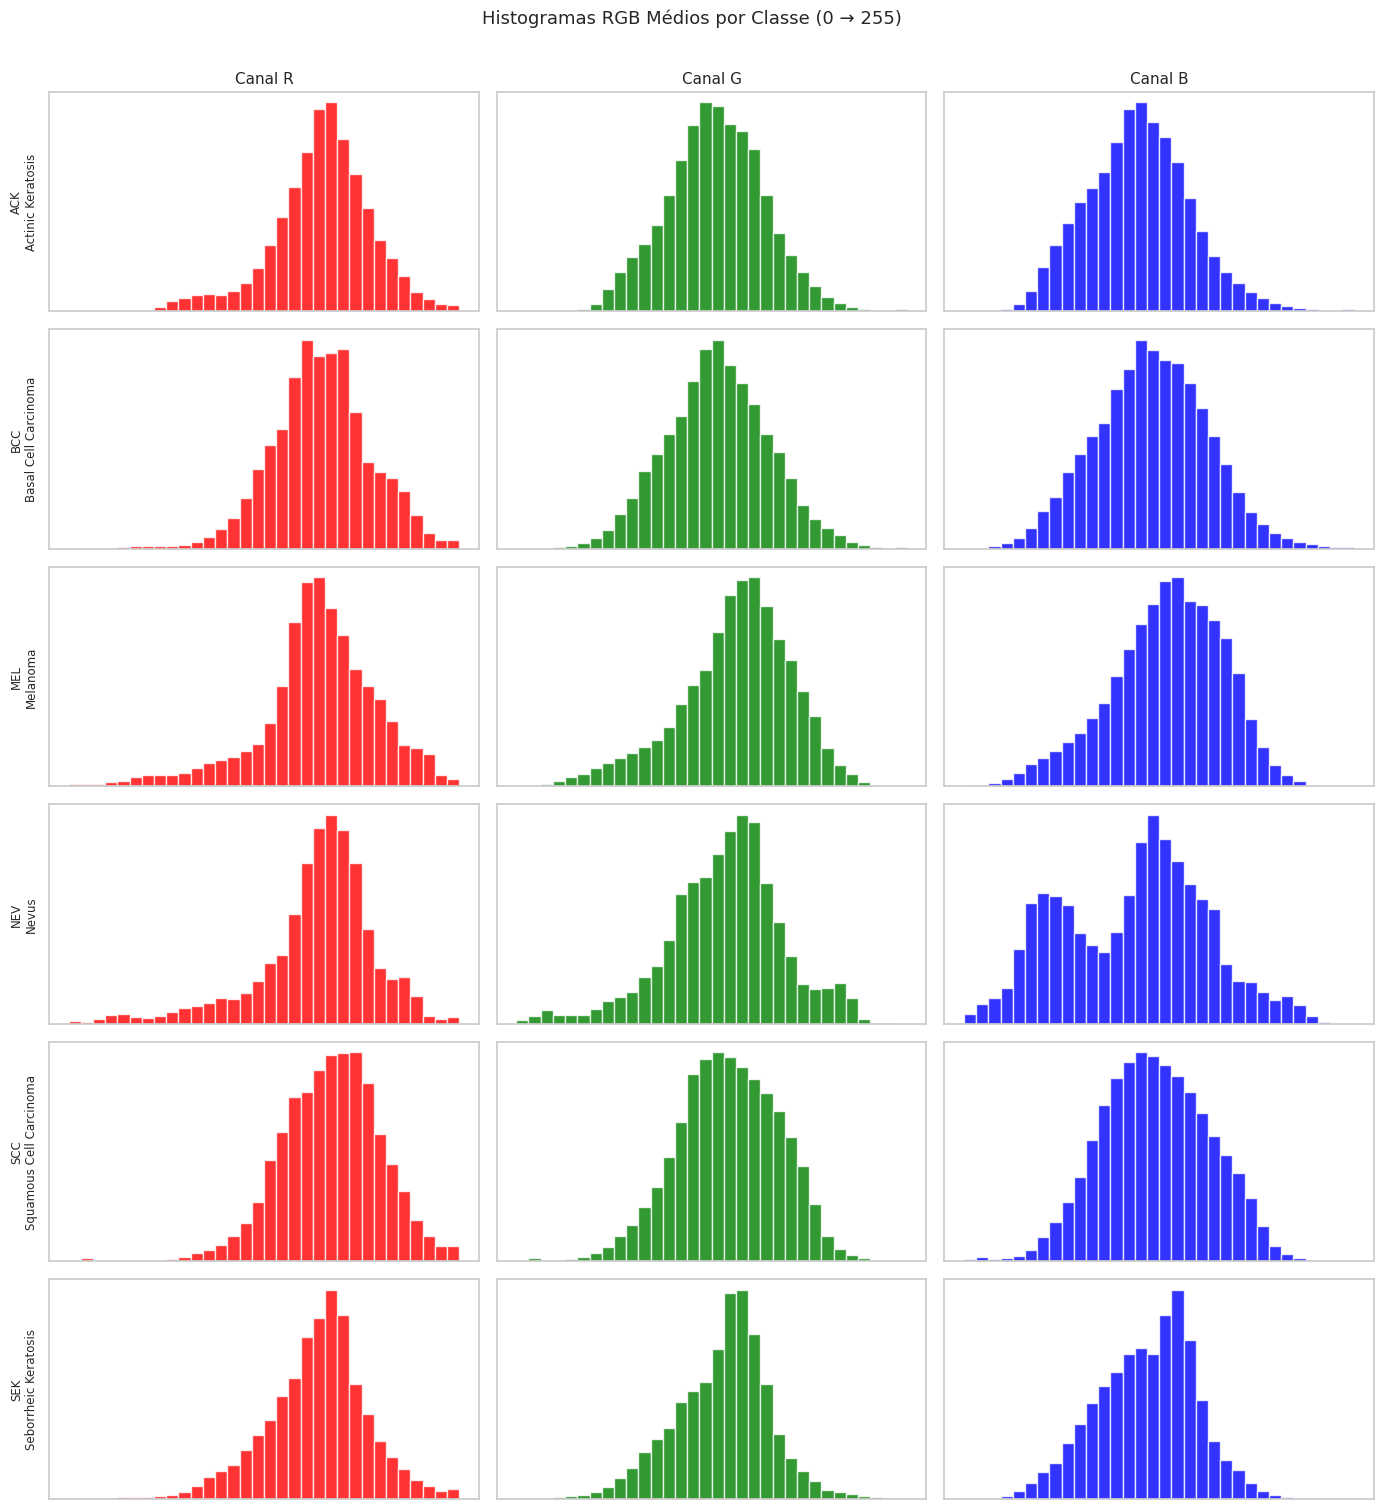

In [19]:
# Histogramas RGB médios por classe
N_HIST_SAMPLE = 50
BINS = 32
channel_colors = ['red', 'green', 'blue']
channel_names  = ['R', 'G', 'B']

fig, axes = plt.subplots(len(CLASS_ORDER), 3,
                          figsize=(14, len(CLASS_ORDER) * 2.5))

for row, cls in enumerate(CLASS_ORDER):
    subset = df[df['diagnostic'] == cls].sample(
        min(N_HIST_SAMPLE, len(df[df['diagnostic'] == cls])), random_state=42
    )
    hists = [np.zeros(BINS) for _ in range(3)]
    for path in subset['img_path']:
        img_arr = np.array(Image.open(path).convert('RGB'))
        for ch in range(3):
            h, _ = np.histogram(img_arr[:, :, ch], bins=BINS, range=(0, 255))
            hists[ch] += h
    for ch in range(3):
        hists[ch] /= len(subset)
        axes[row, ch].bar(range(BINS), hists[ch],
                          color=channel_colors[ch], alpha=0.8, width=1.0)
        axes[row, ch].set_xticks([])
        axes[row, ch].set_yticks([])
        if row == 0:
            axes[row, ch].set_title(f'Canal {channel_names[ch]}', fontsize=11)
        if ch == 0:
            grp_color = '#e07070' if cls in MALIGNANT else '#70a0e0'
            axes[row, ch].set_ylabel(
                f'{cls}\n{CLASS_LABELS[cls]}',
                fontsize=8.5, rotation=90, labelpad=8
            )

plt.suptitle('Histogramas RGB Médios por Classe (0 → 255)', fontsize=13, y=1.005)
plt.tight_layout()
plt.show()

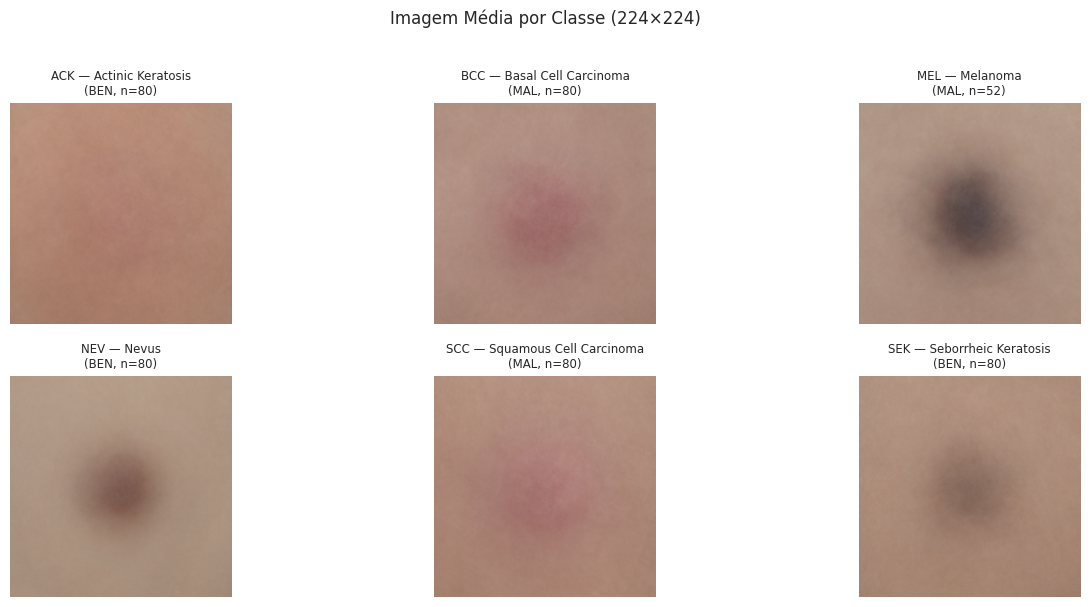

In [20]:
# Imagem média por classe (mean image)
TARGET_SIZE = (224, 224)

fig, axes = plt.subplots(2, len(CLASS_ORDER)//2, figsize=(14, 6))
axes = axes.flatten()

for ax, cls in zip(axes, CLASS_ORDER):
    subset = df[df['diagnostic'] == cls].sample(
        min(80, len(df[df['diagnostic'] == cls])), random_state=42
    )
    imgs = np.stack([
        np.array(Image.open(p).convert('RGB').resize(TARGET_SIZE)) / 255.0
        for p in subset['img_path']
    ])
    mean_img = imgs.mean(axis=0)
    ax.imshow(mean_img)
    grp = 'MAL' if cls in MALIGNANT else 'BEN'
    ax.set_title(f'{cls} — {CLASS_LABELS[cls]}\n({grp}, n={len(subset)})', fontsize=8.5)
    ax.axis('off')

plt.suptitle('Imagem Média por Classe (224×224)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

Calculando estatísticas de cor HSV por imagem...


/tmp/ipykernel_88096/1391072815.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diagnostic', y=col, order=CLASS_ORDER,
/tmp/ipykernel_88096/1391072815.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diagnostic', y=col, order=CLASS_ORDER,


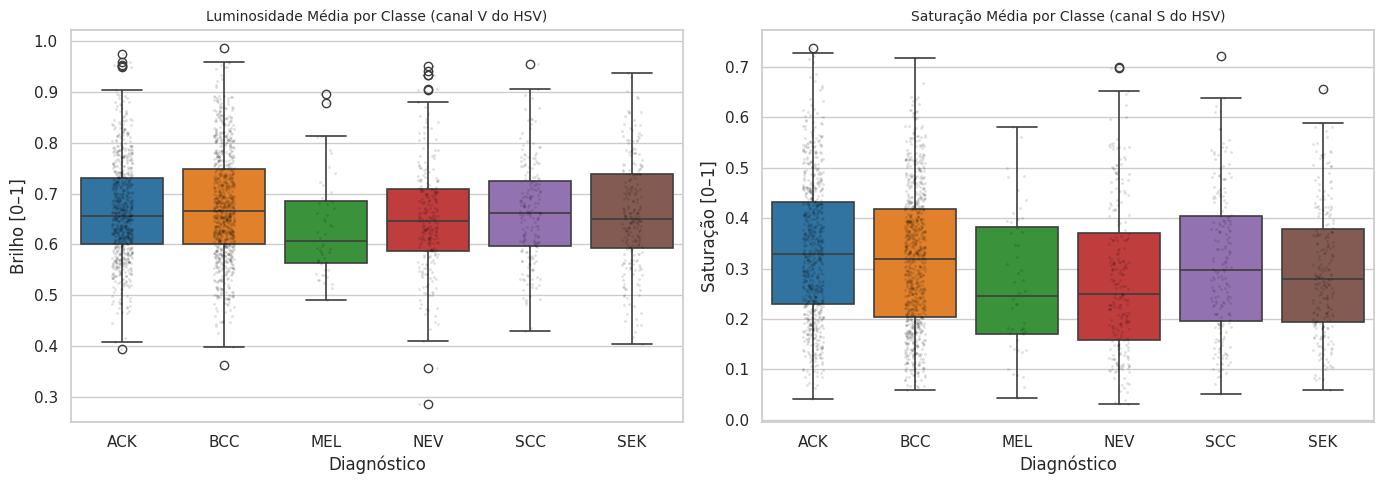

In [21]:
# Luminosidade e Saturação média por classe (espaço HSV)
# FIX: np.where avalia ambas as branches antes da máscara → usa np.divide com where
print('Calculando estatísticas de cor HSV por imagem...')

brightness_list = []
saturation_list = []

for path in df['img_path']:
    img_arr = np.array(Image.open(path).convert('RGB')) / 255.0
    v   = img_arr.max(axis=2)                    # Value (brilho)
    v_min = img_arr.min(axis=2)
    # Saturação: S = (V - min) / V  se V > 0, senão 0
    s = np.zeros_like(v)
    np.divide(v - v_min, v, out=s, where=(v > 0))
    brightness_list.append(float(v.mean()))
    saturation_list.append(float(s.mean()))

df['img_brightness'] = brightness_list
df['img_saturation'] = saturation_list

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title, ylabel in [
    (axes[0], 'img_brightness', 'Luminosidade Média por Classe (canal V do HSV)', 'Brilho [0–1]'),
    (axes[1], 'img_saturation', 'Saturação Média por Classe (canal S do HSV)',    'Saturação [0–1]'),
]:
    sns.boxplot(data=df, x='diagnostic', y=col, order=CLASS_ORDER,
                palette=palette, ax=ax, linewidth=1.2)
    sns.stripplot(data=df, x='diagnostic', y=col, order=CLASS_ORDER,
                  color='black', alpha=0.12, size=2, ax=ax, jitter=True)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Diagnóstico')
    ax.set_ylabel(ylabel)

plt.tight_layout()
plt.show()

---
## EDA — Parte 6: Síntese, Achados e Decisões de Preprocessing

In [22]:
print('=' * 65)
print('SÍNTESE DOS ACHADOS — PAD-UFES EDA')
print('=' * 65)

tc = df['diagnostic'].value_counts().reindex(CLASS_ORDER)
print('\n[ TARGET ]')
for c in CLASS_ORDER:
    print(f'  {c}: {tc[c]:>4}  ({tc[c]/len(df)*100:.1f}%)')
print(f'  Ratio max/min: {tc.max()/tc.min():.1f}x  ({tc.idxmax()} vs {tc.idxmin()})')

print('\n[ IMAGENS ]')
print(f'  Tamanhos únicos  : {df.groupby(["img_width","img_height"]).ngroups}')
print(f'  Imagens quadradas: {(df["img_width"]==df["img_height"]).sum()/len(df)*100:.1f}%')
print(f'  Width mediana    : {int(df["img_width"].median())}px  '
      f'(p5={int(df["img_width"].quantile(0.05))}px, p95={int(df["img_width"].quantile(0.95))}px)')

print('\n[ NULOS ]')
for col in df.columns:
    pct = df[col].isnull().mean()*100
    if pct > 0:
        print(f'  {col:<30}: {pct:.1f}%')

print('\n[ ACHADOS CLÍNICOS ]')
age_mal = df[df['grupo']=='Maligno']['age'].median()
age_ben = df[df['grupo']=='Benigno']['age'].median()
print(f'  Mediana de idade — Maligno: {age_mal:.0f} anos | Benigno: {age_ben:.0f} anos')
dm_mal = df[df['grupo']=='Maligno']['diameter_mean'].median()
dm_ben = df[df['grupo']=='Benigno']['diameter_mean'].median()
print(f'  Diâmetro médio  — Maligno: {dm_mal:.1f} mm   | Benigno: {dm_ben:.1f} mm')

SÍNTESE DOS ACHADOS — PAD-UFES EDA

[ TARGET ]
  ACK:  730  (31.8%)
  BCC:  845  (36.8%)
  MEL:   52  (2.3%)
  NEV:  244  (10.6%)
  SCC:  192  (8.4%)
  SEK:  235  (10.2%)
  Ratio max/min: 16.2x  (BCC vs MEL)

[ IMAGENS ]
  Tamanhos únicos  : 1450
  Imagens quadradas: 81.6%
  Width mediana    : 779px  (p5=302px, p95=2025px)

[ NULOS ]
  smoke                         : 35.0%
  drink                         : 35.0%
  background_father             : 35.6%
  background_mother             : 35.8%
  pesticide                     : 35.0%
  gender                        : 35.0%
  skin_cancer_history           : 35.0%
  cancer_history                : 35.0%
  has_piped_water               : 35.0%
  has_sewage_system             : 35.0%
  fitspatrick                   : 35.0%
  diameter_1                    : 35.0%
  diameter_2                    : 35.0%
  itch                          : 0.3%
  grew                          : 17.5%
  hurt                          : 0.4%
  changed                 

---
## Documentação de Decisões — Pré-Processamento

Cada decisão abaixo é justificada pelos achados da EDA.

---

### D1 — Desbalanceamento de Classes

**Achado:** Ratio de **16.3×** entre a classe majoritária (BCC, n=845) e a minoritária (MEL, n=52).  
MEL e SCC são as classes mais críticas clinicamente (malignos graves) e as mais sub-representadas.

**Decisão:** Utilizar `class_weight='balanced'` nos modelos de ML clássico como primeira abordagem, sem alterar o dataset.  
Caso o desempenho em MEL e SCC permaneça insuficiente, aplicar **oversampling** (SMOTE ou RandomOverSampler) apenas no conjunto de treino, **nunca no teste**.  
Para CNN: usar pesos de classe no `loss` ou `WeightedRandomSampler`.

---

### D2 — Redimensionamento das Imagens

**Achado:** **1.450 tamanhos distintos** de imagem, com largura variando de ~247px a ~3.120px (mediana ≈ 779px). 82% das imagens são quadradas, mas os tamanhos absolutos são muito heterogêneos.

**Decisão:**
- **PDI + ML clássico:** Resize para **128×128** (balanceia detalhe textural vs custo computacional de extração de features).
- **CNN:** Resize para **224×224** (padrão para redes pré-treinadas como ResNet/EfficientNet).
- **Normalização:** pixels divididos por 255, seguido de normalização por média/desvio da ImageNet para CNN com transfer learning.

---

### D3 — Valores Ausentes nos Metadados Clínicos

**Achado:** Colunas com nulos relevantes identificadas na EDA. O heatmap por classe indica que os nulos são distribuídos de forma relativamente uniforme entre as classes (padrão **MCAR/MAR**), não concentrados em um diagnóstico específico.

**Decisão por tipo de coluna:**
- **`age` (numérica):** Imputar com a **mediana por classe diagnóstica** (distribuição assimétrica observada no boxplot).
- **`diameter_1`, `diameter_2` (numéricas):** Imputar com a **mediana global** (correlação alta entre si, distribuição similar entre classes).
- **`fitspatrick` (ordinal):** Imputar com a **moda global** (fotótipo 3 predominante na amostra).
- **`background_father`, `background_mother` (categóricas, alta cardinalidade):** Criar categoria `'Unknown'` para nulos; considerar descarte se importância for baixa após análise de feature importance.
- **Features booleanas** (`smoke`, `drink`, etc.): Nulos tratados como categoria separada (`-1` ou flag `_missing`) — **nulo pode ser informativo** (dado não coletado ≠ resposta negativa).

---

### D4 — Encoding de Features Categóricas

**Achado:**  
- `gender`: 2 categorias → **Label Encoding** (binário).
- `region`: ~10–15 categorias com distribuição desigual → **One-Hot Encoding**.
- `background_father`, `background_mother`: alta cardinalidade → **Target Encoding** ou agrupamento em clusters étnicos, descartando categorias com frequência < 1%.

---

### D5 — Feature Engineering nos Metadados

**Achado:** `diameter_1` e `diameter_2` têm correlação altíssima entre si (~0.95) e ambos isoladamente não adicionam informação nova.

**Decisão:** Criar `diameter_mean = (diameter_1 + diameter_2) / 2` como feature derivada e remover as originais para evitar multicolinearidade nos modelos lineares. Adicionalmente, criar `diameter_area_est = π × (d1/2) × (d2/2)` como estimativa de área da lesão.

---

### D6 — Features de PDI (Próxima Etapa)

**Achado nos histogramas RGB e HSV:** Diferenças visíveis na distribuição de cor entre classes.  
MEL apresenta saturação mais alta e padrões de pigmentação distintos. BCC tende a imagens mais claras. NEV apresenta maior uniformidade de cor.

**Features de PDI planejadas** (a extrair após preprocessing das imagens):
- **Cor:** Histograma RGB e HSV (estatísticas: média, desvio, skewness por canal)
- **Textura:** GLCM (contraste, correlação, energia, homogeneidade), LBP (Local Binary Patterns)
- **Forma/Bordas:** Detecção de contornos (Canny), compacidade da lesão, assimetria
- **Frequência:** Transformada de Fourier / Gabor filters para captura de padrões periódicos

---

### D7 — Separação Treino/Validação/Teste

**Decisão:** Split **70/15/15** com **estratificação por `diagnostic`** para preservar a proporção de classes em todos os conjuntos.  
O split deve ser realizado **antes** de qualquer imputação ou oversampling para evitar data leakage.


---
# Pré-Processamento
Todas as transformações são ajustadas **apenas no conjunto de treino** e aplicadas nos demais.
Isso garante que não há vazamento de informação do futuro (data leakage).

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing  import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_selection  import mutual_info_classif
from sklearn.pipeline import Pipeline
from sklearn.impute   import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

---
## Pré-Proc 1 — Split Estratificado (70 / 15 / 15)
Feito **antes de qualquer transformação** para evitar data leakage.
A estratificação por `diagnostic` garante a proporção de classes em todos os conjuntos.

In [24]:
# ⚠️  biopsed: potencial data leakage
# A biópsia é frequentemente solicitada PORQUE a lesão já é suspeita → correlacionada
# com diagnósticos malignos. Será incluída no conjunto de features, mas os modelos
# serão avaliados COM e SEM essa coluna para medir o impacto real.

# Split inicial: 70% treino, 30% temporário
df_train, df_temp = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df['diagnostic']
)
# Divide o temporário em 50/50 → 15% val + 15% teste
df_val, df_test = train_test_split(
    df_temp, test_size=0.50, random_state=42, stratify=df_temp['diagnostic']
)

print(f'Treino : {len(df_train):>5}  ({len(df_train)/len(df)*100:.1f}%)')
print(f'Val    : {len(df_val):>5}  ({len(df_val)/len(df)*100:.1f}%)')
print(f'Teste  : {len(df_test):>5}  ({len(df_test)/len(df)*100:.1f}%)')
print()
print('Proporção por classe (treino / val / teste):')
comp = pd.DataFrame({
    'treino_%': df_train['diagnostic'].value_counts(normalize=True).reindex(CLASS_ORDER)*100,
    'val_%'   : df_val['diagnostic'].value_counts(normalize=True).reindex(CLASS_ORDER)*100,
    'teste_%' : df_test['diagnostic'].value_counts(normalize=True).reindex(CLASS_ORDER)*100,
}).round(1)
print(comp.to_string())


Treino :  1608  (70.0%)
Val    :   345  (15.0%)
Teste  :   345  (15.0%)

Proporção por classe (treino / val / teste):
            treino_%  val_%  teste_%
diagnostic                          
ACK             31.8   31.6     31.9
BCC             36.8   36.8     36.8
MEL              2.2    2.3      2.3
NEV             10.6   10.7     10.4
SCC              8.3    8.4      8.4
SEK             10.3   10.1     10.1


---
## Pré-Proc 2 — Análise de Outliers
Verificação de valores discrepantes nas features numéricas antes da imputação.

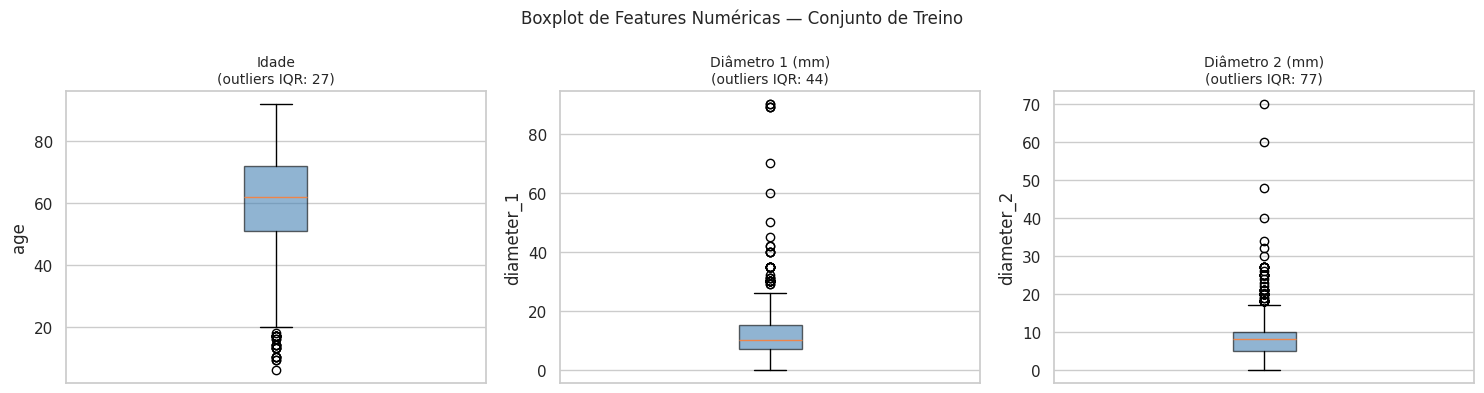

Decisão: os valores extremos de age (6–21 anos) são biologicamente válidos.
Não há truncamento. Outliers de diâmetro (lesões grandes) também são preservados.
Modelos baseados em árvore (RF, XGBoost) são robustos a esses valores.
Para SVM/regressão, a normalização posterior tratará a escala.


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, title in [
    (axes[0], 'age',        'Idade'),
    (axes[1], 'diameter_1', 'Diâmetro 1 (mm)'),
    (axes[2], 'diameter_2', 'Diâmetro 2 (mm)'),
]:
    data = df_train[col].dropna()
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr    = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out  = ((data < lower) | (data > upper)).sum()

    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6))
    ax.set_title(f'{title}\n(outliers IQR: {n_out})', fontsize=10)
    ax.set_xticks([])
    ax.set_ylabel(col)

plt.suptitle('Boxplot de Features Numéricas — Conjunto de Treino', fontsize=12)
plt.tight_layout()
plt.show()

print('Decisão: os valores extremos de age (6–21 anos) são biologicamente válidos.')
print('Não há truncamento. Outliers de diâmetro (lesões grandes) também são preservados.')
print('Modelos baseados em árvore (RF, XGBoost) são robustos a esses valores.')
print('Para SVM/regressão, a normalização posterior tratará a escala.')

---
## Pré-Proc 3 — Feature Engineering
Criação de features derivadas antes da imputação (operam sobre os valores originais).

In [26]:
def add_diameter_features(frame):
    """Cria diameter_mean e diameter_area_est. Operação segura com NaN."""
    f = frame.copy()
    f['diameter_mean']     = (f['diameter_1'] + f['diameter_2']) / 2
    f['diameter_area_est'] = np.pi * (f['diameter_1'] / 2) * (f['diameter_2'] / 2)
    return f

df_train = add_diameter_features(df_train)
df_val   = add_diameter_features(df_val)
df_test  = add_diameter_features(df_test)

print('Features criadas: diameter_mean, diameter_area_est')
print(df_train[['diameter_1','diameter_2','diameter_mean','diameter_area_est']].describe().round(2))

Features criadas: diameter_mean, diameter_area_est
       diameter_1  diameter_2  diameter_mean  diameter_area_est
count     1038.00     1038.00        1038.00            1038.00
mean        12.04        8.92          10.48             117.70
std          8.86        5.71           7.00             254.14
min          0.00        0.00           0.00               0.00
25%          7.00        5.00           6.00              28.27
50%         10.00        8.00           9.00              62.83
75%         15.00       10.00          12.50             117.81
max         90.00       70.00          80.00            4948.01


---
## Pré-Proc 4 — Imputação de Valores Ausentes
Estratégia diferenciada por tipo de coluna, ajustada somente no treino.

In [27]:
# ── Estratégia por coluna ────────────────────────────────────────────────
# age            → mediana por classe (distribuição assimétrica)
# diameter_mean/area → mediana global (correlação alta, poucas diferenças entre classes)
# fitspatrick    → moda global (ordinal com valor dominante)
# gender         → moda global
# background_*   → "UNKNOWN" (categórico, nulo é informativo)
# booleanas      → False (ausência de registro = ausência do sintoma/histórico)

bool_feature_cols = [
    "smoke", "drink", "pesticide", "skin_cancer_history", "cancer_history",
    "has_piped_water", "has_sewage_system",
    "itch", "grew", "hurt", "changed", "bleed", "elevation", "biopsed"
]

# 4.1 Limpeza de categorias duplicadas em background
BACK_FIX = {"BRASIL": "BRAZIL", "UNK": "UNKNOWN"}

def clean_background(frame):
    f = frame.copy()
    for col in ["background_father", "background_mother"]:
        f[col] = f[col].replace(BACK_FIX).fillna("UNKNOWN")
    return f

df_train = clean_background(df_train)
df_val   = clean_background(df_val)
df_test  = clean_background(df_test)

# 4.2 Imputar age: mediana por classe calculada no TREINO
age_median_by_class = df_train.groupby("diagnostic")["age"].median()

def impute_age(frame, median_map):
    f = frame.copy()
    mask = f["age"].isnull()
    f.loc[mask, "age"] = f.loc[mask, "diagnostic"].map(median_map)
    return f

df_train = impute_age(df_train, age_median_by_class)
df_val   = impute_age(df_val,   age_median_by_class)
df_test  = impute_age(df_test,  age_median_by_class)

# 4.3 Imputar numéricos: mediana global do TREINO
# NOTA: usar atribuição explícita — fillna(inplace=True) em chained
# indexing (split[col].fillna) não propaga para o DataFrame original.
num_impute_cols = ["diameter_mean", "diameter_area_est", "fitspatrick"]
num_medians = df_train[num_impute_cols].median()

for col in num_impute_cols:
    df_train[col] = df_train[col].fillna(num_medians[col])
    df_val[col]   = df_val[col].fillna(num_medians[col])
    df_test[col]  = df_test[col].fillna(num_medians[col])

# 4.4 Imputar gender: moda do TREINO
gender_mode = df_train["gender"].mode()[0]
df_train["gender"] = df_train["gender"].fillna(gender_mode)
df_val["gender"]   = df_val["gender"].fillna(gender_mode)
df_test["gender"]  = df_test["gender"].fillna(gender_mode)

# 4.5 Imputar booleanas: False
for col in bool_feature_cols:
    df_train[col] = df_train[col].fillna(False)
    df_val[col]   = df_val[col].fillna(False)
    df_test[col]  = df_test[col].fillna(False)

# Verificação de integridade
cols_to_check = num_impute_cols + ["age", "gender"] + bool_feature_cols
remaining_nulls = pd.concat([df_train, df_val, df_test])[cols_to_check].isnull().sum()
remaining_nulls = remaining_nulls[remaining_nulls > 0]
if remaining_nulls.empty:
    print("Nenhum nulo restante nas features imputadas.")
else:
    print("Nulos ainda presentes:")
    print(remaining_nulls)


Nenhum nulo restante nas features imputadas.


---
## Pré-Proc 5 — Encoding de Features Categóricas

In [28]:
# 5.1 Gender: FEMALE→0, MALE→1
gender_map = {'FEMALE': 0, 'MALE': 1}
for split in [df_train, df_val, df_test]:
    split['gender'] = split['gender'].map(gender_map)

# 5.2 Target: LabelEncoder (ACK→0, BCC→1, MEL→2, NEV→3, SCC→4, SEK→5)
le_target = LabelEncoder()
le_target.fit(df_train['diagnostic'])

y_train = le_target.transform(df_train['diagnostic'])
y_val   = le_target.transform(df_val['diagnostic'])
y_test  = le_target.transform(df_test['diagnostic'])

print('Mapeamento de classes:')
for i, cls in enumerate(le_target.classes_):
    print(f'  {i} → {cls}')

# 5.3 OHE para region, background_father, background_mother
# Ajustado no TREINO — categorias desconhecidas no val/test recebem zeros
ohe_cols = ['region', 'background_father', 'background_mother']

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', dtype=np.float32)
ohe.fit(df_train[ohe_cols])

ohe_feature_names = ohe.get_feature_names_out(ohe_cols).tolist()

def apply_ohe(frame, encoder, cols, feat_names):
    encoded = encoder.transform(frame[cols])
    return pd.DataFrame(encoded, columns=feat_names, index=frame.index)

df_train_ohe = apply_ohe(df_train, ohe, ohe_cols, ohe_feature_names)
df_val_ohe   = apply_ohe(df_val,   ohe, ohe_cols, ohe_feature_names)
df_test_ohe  = apply_ohe(df_test,  ohe, ohe_cols, ohe_feature_names)

print(f'\nFeatures após OHE: {len(ohe_feature_names)}')
print('Exemplos:', ohe_feature_names[:8], '...')

Mapeamento de classes:
  0 → ACK
  1 → BCC
  2 → MEL
  3 → NEV
  4 → SCC
  5 → SEK

Features após OHE: 37
Exemplos: ['region_ABDOMEN', 'region_ARM', 'region_BACK', 'region_CHEST', 'region_EAR', 'region_FACE', 'region_FOOT', 'region_FOREARM'] ...


---
## Pré-Proc 6 — Normalização (StandardScaler)
Aplicado nas features numéricas contínuas. Features booleanas e OHE não são escaladas.

In [29]:
NUMERIC_COLS  = ['age', 'fitspatrick', 'diameter_mean', 'diameter_area_est']
BOOL_COLS_OUT = [c for c in bool_feature_cols if c != 'biopsed'] + ['biopsed', 'gender']

scaler = StandardScaler()
scaler.fit(df_train[NUMERIC_COLS])

def build_feature_matrix(frame, frame_ohe, num_cols, bool_cols):
    """Monta a matriz de features: numéricas escaladas + booleanas + OHE.
    frame_ohe deve ter o mesmo índice que frame.
    """
    num_scaled = pd.DataFrame(
        scaler.transform(frame[num_cols]),
        columns=num_cols,
        index=frame.index
    )
    bool_part = frame[bool_cols].astype(np.float32).reset_index(drop=True)
    num_part  = num_scaled.reset_index(drop=True)
    ohe_part  = frame_ohe.reset_index(drop=True)
    return pd.concat([num_part, bool_part, ohe_part], axis=1)

X_train = build_feature_matrix(df_train, df_train_ohe, NUMERIC_COLS, BOOL_COLS_OUT)
X_val   = build_feature_matrix(df_val,   df_val_ohe,   NUMERIC_COLS, BOOL_COLS_OUT)
X_test  = build_feature_matrix(df_test,  df_test_ohe,  NUMERIC_COLS, BOOL_COLS_OUT)

# Garantia explícita: nenhum NaN deve chegar nos modelos
assert X_train.isnull().sum().sum() == 0, 'NaN em X_train!'
assert X_val.isnull().sum().sum()   == 0, 'NaN em X_val!'
assert X_test.isnull().sum().sum()  == 0, 'NaN em X_test!'

print(f'X_train : {X_train.shape}  |  NaN: 0')
print(f'X_val   : {X_val.shape}  |  NaN: 0')
print(f'X_test  : {X_test.shape}  |  NaN: 0')
print(f'\nComposição das {X_train.shape[1]} features:')
print(f'  Numéricas (escaladas) : {len(NUMERIC_COLS)}')
print(f'  Booleanas             : {len(BOOL_COLS_OUT)}')
print(f'  OHE                   : {len(ohe_feature_names)}')


X_train : (1608, 56)  |  NaN: 0
X_val   : (345, 56)  |  NaN: 0
X_test  : (345, 56)  |  NaN: 0

Composição das 56 features:
  Numéricas (escaladas) : 4
  Booleanas             : 15
  OHE                   : 37


---
## Pré-Proc 7 — Pesos de Classe
Calcula os pesos inversamente proporcionais à frequência de cada classe.
Serão usados nos modelos como `class_weight` para compensar o desbalanceamento sem alterar o dataset.

Pesos por classe:
  0 (ACK / Benigno): peso = 0.524
  1 (BCC / Maligno): peso = 0.453
  2 (MEL / Maligno): peso = 7.444
  3 (NEV / Benigno): peso = 1.567
  4 (SCC / Maligno): peso = 2.000
  5 (SEK / Benigno): peso = 1.624


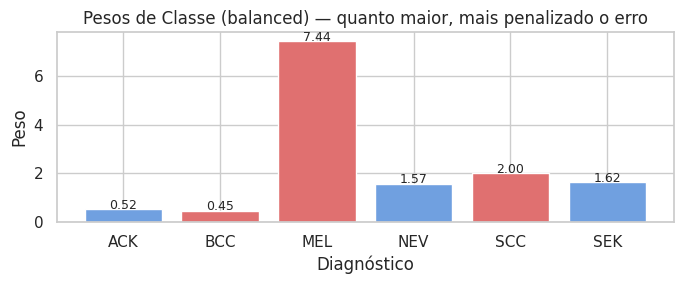

In [30]:
classes_arr = np.unique(y_train)
weights     = compute_class_weight('balanced', classes=classes_arr, y=y_train)

# Converter para int Python nativo — numpy.int64 pode causar incompatibilidade
# em alguns estimadores sklearn que esperam chaves int no class_weight dict.
class_weight_dict = {int(k): float(v) for k, v in zip(classes_arr, weights)}

print('Pesos por classe:')
for idx, cls_name in enumerate(le_target.classes_):
    grp = 'Maligno' if cls_name in MALIGNANT else 'Benigno'
    print(f'  {idx} ({cls_name} / {grp}): peso = {weights[idx]:.3f}')

fig, ax = plt.subplots(figsize=(7, 3))
bar_colors = ['#e07070' if c in MALIGNANT else '#70a0e0' for c in le_target.classes_]
ax.bar(le_target.classes_, weights, color=bar_colors, edgecolor='white')
ax.set_title('Pesos de Classe (balanced) — quanto maior, mais penalizado o erro')
ax.set_ylabel('Peso')
ax.set_xlabel('Diagnóstico')
for i_bar, (cls, w) in enumerate(zip(le_target.classes_, weights)):
    ax.text(i_bar, w + 0.02, f'{w:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()


---
## Pré-Proc 8 — Seleção de Features
Usa Mutual Information para medir a dependência estatística de cada feature com o target.
Features com MI ≈ 0 têm pouco poder discriminativo e são candidatas ao descarte.

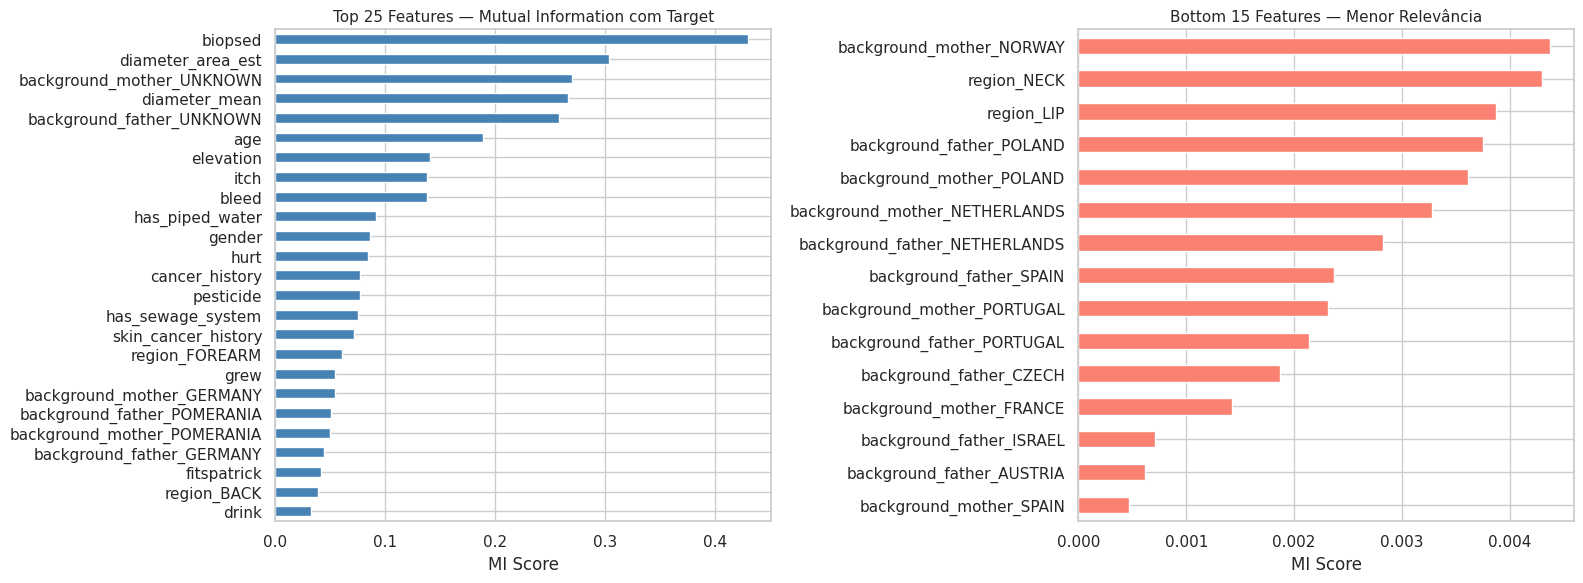

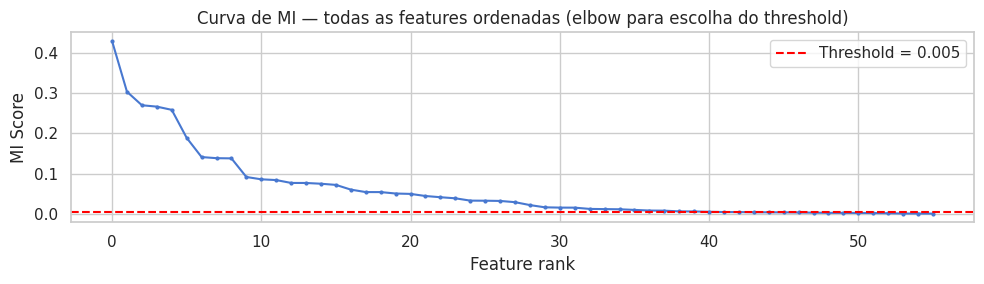

Features com MI < 0.005: 16
region_EAR                       0.0050
background_mother_NORWAY         0.0044
region_NECK                      0.0043
region_LIP                       0.0039
background_father_POLAND         0.0037
background_mother_POLAND         0.0036
background_mother_NETHERLANDS    0.0033
background_father_NETHERLANDS    0.0028
background_father_SPAIN          0.0024
background_mother_PORTUGAL       0.0023
background_father_PORTUGAL       0.0021
background_father_CZECH          0.0019
background_mother_FRANCE         0.0014
background_father_ISRAEL         0.0007
background_father_AUSTRIA        0.0006
background_mother_SPAIN          0.0005


In [31]:
# Máscara de features discretas: booleanas e OHE são discretas (0/1)
# Passá-las como discrete_features melhora a estimativa de MI para essas colunas.
bool_and_ohe_cols = set(BOOL_COLS_OUT) | set(ohe_feature_names)
discrete_mask = np.array([col in bool_and_ohe_cols for col in X_train.columns])

mi_scores = mutual_info_classif(
    X_train, y_train,
    discrete_features=discrete_mask,
    random_state=42,
    n_neighbors=5
)
mi_series = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top25 = mi_series.head(25)
top25.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].invert_yaxis()
axes[0].set_title('Top 25 Features — Mutual Information com Target', fontsize=11)
axes[0].set_xlabel('MI Score')

bot15 = mi_series.tail(15)
bot15.plot(kind='barh', ax=axes[1], color='salmon', edgecolor='white')
axes[1].invert_yaxis()
axes[1].set_title('Bottom 15 Features — Menor Relevância', fontsize=11)
axes[1].set_xlabel('MI Score')

plt.tight_layout()
plt.show()

# Escolha do threshold: ponto de inflexão na curva de MI (elbow)
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(range(len(mi_series)), mi_series.values, marker='.', markersize=4)
ax.axhline(y=0.005, color='red', linestyle='--', label='Threshold = 0.005')
ax.set_title('Curva de MI — todas as features ordenadas (elbow para escolha do threshold)')
ax.set_xlabel('Feature rank')
ax.set_ylabel('MI Score')
ax.legend()
plt.tight_layout()
plt.show()

THRESHOLD_MI = 0.005
low_mi = mi_series[mi_series < THRESHOLD_MI]
print(f'Features com MI < {THRESHOLD_MI}: {len(low_mi)}')
print(low_mi.round(4).to_string())


In [32]:
features_keep = mi_series[mi_series >= THRESHOLD_MI].index.tolist()
features_drop = mi_series[mi_series <  THRESHOLD_MI].index.tolist()

X_train_sel = X_train[features_keep]
X_val_sel   = X_val[features_keep]
X_test_sel  = X_test[features_keep]

# Versão sem biopsed — para experimento de leakage
# Avalia o quanto biopsed está inflando a performance dos modelos.
features_no_biopsed = [f for f in features_keep if f != 'biopsed']
X_train_nb = X_train_sel[features_no_biopsed]
X_val_nb   = X_val_sel[features_no_biopsed]
X_test_nb  = X_test_sel[features_no_biopsed]

print(f'Features antes da seleção         : {X_train.shape[1]}')
print(f'Features após seleção (MI >= 0.005): {X_train_sel.shape[1]}')
print(f'Features sem biopsed              : {X_train_nb.shape[1]}')
print(f'Features descartadas              : {len(features_drop)}')
print(f'\nDescartadas: {features_drop}')
print(f'\nbiopsed está em features_keep: {"biopsed" in features_keep}')


Features antes da seleção         : 56
Features após seleção (MI >= 0.005): 40
Features sem biopsed              : 39
Features descartadas              : 16

Descartadas: ['region_EAR', 'background_mother_NORWAY', 'region_NECK', 'region_LIP', 'background_father_POLAND', 'background_mother_POLAND', 'background_mother_NETHERLANDS', 'background_father_NETHERLANDS', 'background_father_SPAIN', 'background_mother_PORTUGAL', 'background_father_PORTUGAL', 'background_father_CZECH', 'background_mother_FRANCE', 'background_father_ISRAEL', 'background_father_AUSTRIA', 'background_mother_SPAIN']

biopsed está em features_keep: True


---
## Pré-Proc 9 — Pipeline de Imagens
Define as funções de pré-processamento que serão usadas tanto na extração de features PDI quanto na CNN.
O resize e a normalização são aplicados sob demanda (lazy), não salvos em disco.

PDI sample — shape: (128, 128, 3)  min: 0.208  max: 0.929
CNN sample — shape: (224, 224, 3)  min: -1.003  max: 2.640


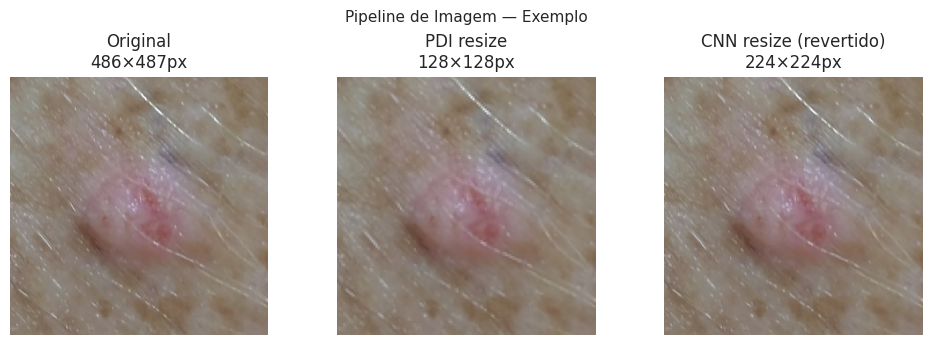

In [33]:
IMG_SIZE_PDI = (128, 128)   # Para extração de features PDI
IMG_SIZE_CNN = (224, 224)   # Para CNN (padrão ImageNet / transfer learning)

# Estatísticas ImageNet — usadas na normalização para modelos pré-treinados
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def preprocess_image_pdi(img_path: str) -> np.ndarray:
    """Carrega, redimensiona e normaliza [0,1] para extração de features PDI."""
    img = Image.open(img_path).convert('RGB').resize(IMG_SIZE_PDI, Image.LANCZOS)
    return np.array(img, dtype=np.float32) / 255.0

def preprocess_image_cnn(img_path: str, imagenet_norm: bool = True) -> np.ndarray:
    """Carrega, redimensiona e normaliza com stats ImageNet para CNN."""
    img = Image.open(img_path).convert('RGB').resize(IMG_SIZE_CNN, Image.LANCZOS)
    arr = np.array(img, dtype=np.float32) / 255.0
    if imagenet_norm:
        arr = (arr - IMAGENET_MEAN) / IMAGENET_STD
    return arr

# Teste rápido de sanidade
sample_path = df_train['img_path'].iloc[0]
pdi_sample  = preprocess_image_pdi(sample_path)
cnn_sample  = preprocess_image_cnn(sample_path)

print(f'PDI sample — shape: {pdi_sample.shape}  min: {pdi_sample.min():.3f}  max: {pdi_sample.max():.3f}')
print(f'CNN sample — shape: {cnn_sample.shape}  min: {cnn_sample.min():.3f}  max: {cnn_sample.max():.3f}')

# Visualização lado a lado: original vs pdi vs cnn (revertido para exibição)
fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
orig = np.array(Image.open(sample_path).convert('RGB'))
axes[0].imshow(orig);        axes[0].set_title(f'Original\n{orig.shape[1]}×{orig.shape[0]}px'); axes[0].axis('off')
axes[1].imshow(pdi_sample);  axes[1].set_title(f'PDI resize\n{IMG_SIZE_PDI[0]}×{IMG_SIZE_PDI[1]}px'); axes[1].axis('off')
cnn_vis = np.clip(cnn_sample * IMAGENET_STD + IMAGENET_MEAN, 0, 1)
axes[2].imshow(cnn_vis);     axes[2].set_title(f'CNN resize (revertido)\n{IMG_SIZE_CNN[0]}×{IMG_SIZE_CNN[1]}px'); axes[2].axis('off')
plt.suptitle('Pipeline de Imagem — Exemplo', fontsize=11)
plt.tight_layout()
plt.show()

---
## Análise Crítica e Documentação do Pré-Processamento

---

### Decisões confirmadas pela análise crítica

| Etapa | Decisão | Justificativa |
|---|---|---|
| Split | 70/15/15 estratificado antes de qualquer transformação | Evita leakage; garante proporção de MEL (n=52) nos 3 conjuntos |
| Outliers | Sem truncamento em `age` (min=6, max=94) | Valores biologicamente plausíveis; árvores são robustas a outliers |
| Imputação `age` | Mediana **por classe** no treino | Distribuição assimétrica; idade varia significativamente entre diagnósticos |
| Imputação diâmetros | Mediana global no treino | Correlação ~0.95 entre d1 e d2; diferença inter-classe pequena |
| Imputação booleanas | `False` | Ausência de registro clínico é tratada como ausência do sintoma — simplificação aceitável para uma baseline |
| `background_*` | Categoria `'UNKNOWN'` para nulos | Nulo informativo: procedência desconhecida é clinicamente distinta de qualquer país registrado |
| Normalização | StandardScaler apenas em numéricas; booleanas e OHE sem escala | Booleanas {0,1} já têm escala comparável; escalá-las distorceria a distância |
| Class weights | `compute_class_weight('balanced')` com chaves `int` | Compensa desbalanceamento 16x sem alterar o dataset; chaves int evitam incompatibilidade sklearn |

---

### Pontos de atenção e tradeoffs

**`biopsed` — risco de data leakage**  
A variável indica se uma biópsia foi realizada. Em contexto clínico real, a biópsia é solicitada justamente quando a lesão é suspeita — o que a torna correlacionada com diagnósticos malignos **por causalidade reversa**, não por ser um preditor legítimo.  
**Estratégia adotada:** os modelos serão treinados em duas versões — `X_train_sel` (com `biopsed`) e `X_train_nb` (sem `biopsed`). Se a diferença de performance for significativa (> 2–3%), confirmamos o leakage e usamos `X_train_nb` como versão final.  
Para uma aplicação real (triagem antes da biópsia), `biopsed` deve ser **descartada definitivamente**.

**`fitspatrick` — variável ordinal tratada como contínua**  
A escala de Fitzpatrick é ordinal (1 = pele muito clara → 6 = pele muito escura), não contínua — a distância entre tipos 1 e 2 não é necessariamente igual à distância entre 4 e 5.  
Aplicar `StandardScaler` implica essa suposição de igualdade de intervalos.  
**Impacto prático:** para Random Forest e XGBoost (insensíveis à escala), nenhum. Para SVM e k-NN (sensíveis à distância), pode introduzir um viés pequeno. Aceito como simplificação para a baseline; pode ser refinado com ordinal encoding explícito se necessário.

**`THRESHOLD_MI = 0.005` — limiar de seleção de features**  
O valor 0.005 é conservador: remove apenas features com MI próximo de zero (sem informação relevante). A curva de elbow plotada na célula anterior permite validar visualmente se o corte está no ponto certo.  
**Revisitar** se, após os primeiros modelos, features descartadas aparecerem como importantes no SHAP ou feature importance do Random Forest.

**`discrete_features` no `mutual_info_classif`**  
Features booleanas e OHE são discretas por natureza. Sem a máscara `discrete_features`, o estimador de MI usa um kernel contínuo (baseado em k-nearest neighbors) que subestima a dependência de variáveis binárias com o target.  
**Corrigido:** máscara passada explicitamente — MI de features como `itch`, `bleed`, `grew` agora é estimado corretamente.

---

### Estado final dos artefatos

```
Treino/Val/Teste
  df_train / df_val / df_test       → DataFrames completos (usados na etapa PDI)
  X_train_sel / X_val_sel / X_test_sel → features tabulares selecionadas (com biopsed)
  X_train_nb  / X_val_nb  / X_test_nb  → idem, sem biopsed (experimento de leakage)
  y_train / y_val / y_test          → labels encoded (0–5)

Transformadores (ajustados APENAS no treino)
  scaler            → StandardScaler para numéricas
  ohe               → OneHotEncoder para categóricas
  le_target         → LabelEncoder para o target
  age_median_by_class → mediana de age por classe
  num_medians         → medianas globais de diameter_mean, diameter_area_est, fitspatrick

Configurações dos modelos
  class_weight_dict → pesos balanceados {int: float} para todos os estimadores
  features_keep     → lista de features após seleção por MI

Pipeline de imagem
  preprocess_image_pdi(path) → np.ndarray (128, 128, 3) float32 [0,1]
  preprocess_image_cnn(path) → np.ndarray (224, 224, 3) float32 normalizado ImageNet
```


---
## Pré-Proc 10 — Resumo e Estado Final dos Dados

In [34]:
print('=' * 60)
print('ESTADO FINAL — PRÉ-PROCESSAMENTO TABULAR')
print('=' * 60)
print(f'\nSplits:')
print(f'  X_train_sel : {X_train_sel.shape}')
print(f'  X_val_sel   : {X_val_sel.shape}')
print(f'  X_test_sel  : {X_test_sel.shape}')
print(f'  y_train     : {y_train.shape}  classes: {np.unique(y_train)}')
print(f'\nFeatures selecionadas ({X_train_sel.shape[1]} total):')
for feat in X_train_sel.columns.tolist():
    print(f'  {feat}')
print(f'\nPesos de classe: {class_weight_dict}')
print(f'\nArtifatos salvos (para uso nas próximas etapas):')
print('  scaler          → StandardScaler ajustado no treino')
print('  ohe             → OneHotEncoder ajustado no treino')
print('  le_target       → LabelEncoder das classes')
print('  class_weight_dict → pesos para os modelos')
print('  features_keep   → lista de features selecionadas')
print(f'\nPipeline de imagem:')
print(f'  preprocess_image_pdi → {IMG_SIZE_PDI}  normalização [0,1]')
print(f'  preprocess_image_cnn → {IMG_SIZE_CNN}  normalização ImageNet')
print(f'\nPróxima etapa: Extração de Features PDI')

ESTADO FINAL — PRÉ-PROCESSAMENTO TABULAR

Splits:
  X_train_sel : (1608, 40)
  X_val_sel   : (345, 40)
  X_test_sel  : (345, 40)
  y_train     : (1608,)  classes: [0 1 2 3 4 5]

Features selecionadas (40 total):
  biopsed
  diameter_area_est
  background_mother_UNKNOWN
  diameter_mean
  background_father_UNKNOWN
  age
  elevation
  itch
  bleed
  has_piped_water
  gender
  hurt
  cancer_history
  pesticide
  has_sewage_system
  skin_cancer_history
  region_FOREARM
  grew
  background_mother_GERMANY
  background_father_POMERANIA
  background_mother_POMERANIA
  background_father_GERMANY
  fitspatrick
  region_BACK
  drink
  changed
  smoke
  region_NOSE
  region_FACE
  background_father_ITALY
  region_ABDOMEN
  region_HAND
  background_mother_ITALY
  background_father_BRAZIL
  region_ARM
  region_THIGH
  region_FOOT
  region_CHEST
  region_SCALP
  background_mother_BRAZIL

Pesos de classe: {0: 0.5244618395303327, 1: 0.45346869712351945, 2: 7.444444444444445, 3: 1.567251461988304, 4: 2.0,

---
# Extração de Features — PDI (Processamento Digital de Imagens)
Cada imagem é descrita por **55 features handcrafted** organizadas em 4 grupos:
- **Cor** (18): estatísticas RGB e HSV — média, desvio, skewness por canal
- **Textura** (16): GLCM (6 propriedades) + LBP histograma (10 bins)
- **Bordas/Forma** (5): densidade Canny, magnitude Sobel, assimetria H/V
- **Frequência** (16): banco de filtros Gabor (4 orientações × 2 escalas × mean+std)

Todas as funções operam sobre a imagem redimensionada para **128×128** (definida no pré-processamento).
A extração é feita sobre `df_train`, `df_val` e `df_test` separadamente, sem data leakage.

In [35]:
import cv2
import skimage
from skimage.feature import local_binary_pattern, graycomatrix, graycoprops
from scipy.stats import skew as scipy_skew
import time
from tqdm.auto import tqdm

# Confirma versões
print(f'OpenCV    : {cv2.__version__}')
print(f'scikit-image: {skimage.__version__}')

PDI_FEATURE_NAMES = (
    # Cor RGB (9)
    [f'rgb_{ch}_{stat}' for ch in ['R','G','B'] for stat in ['mean','std','skew']] +
    # Cor HSV (9)
    [f'hsv_{ch}_{stat}' for ch in ['H','S','V'] for stat in ['mean','std','skew']] +
    # GLCM (6)
    ['glcm_contrast','glcm_dissimilarity','glcm_homogeneity',
     'glcm_energy','glcm_correlation','glcm_ASM'] +
    # LBP (10)
    [f'lbp_bin_{i}' for i in range(10)] +
    # Bordas/Forma (5)
    ['edge_density','sobel_mean','sobel_std','asym_horizontal','asym_vertical'] +
    # Gabor (16: 4 orientações × 2 escalas × mean+std)
    [f'gabor_t{int(np.degrees(t)):03d}_s{s}_{stat}'
     for t in [0, np.pi/4, np.pi/2, 3*np.pi/4]
     for s in ['fine','coarse']
     for stat in ['mean','std']]
)

assert len(PDI_FEATURE_NAMES) == 55, f'Esperado 55, obtido {len(PDI_FEATURE_NAMES)}'
print(f'\nTotal features PDI: {len(PDI_FEATURE_NAMES)}')

OpenCV    : 4.13.0
scikit-image: 0.26.0

Total features PDI: 55


In [36]:
def extract_color_features(img_rgb: np.ndarray) -> list:
    """18 features: mean/std/skew por canal em RGB e HSV."""
    rgb  = img_rgb.astype(np.float32)
    hsv  = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV).astype(np.float32)
    feats = []
    for arr in [rgb, hsv]:
        for ch in range(3):
            vals = arr[:, :, ch].ravel()
            feats += [float(np.mean(vals)), float(np.std(vals)), float(scipy_skew(vals))]
    return feats  # 18 features


def extract_texture_features(gray: np.ndarray) -> list:
    """16 features: GLCM (6 props, 4 ângulos médios) + LBP histograma (10 bins)."""
    # GLCM: reduz para 64 níveis para menor custo computacional sem perda significativa
    gray64 = (gray // 4).astype(np.uint8)
    glcm   = graycomatrix(gray64, distances=[1],
                          angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                          levels=64, symmetric=True, normed=True)
    feats = []
    for prop in ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'ASM']:
        feats.append(float(graycoprops(glcm, prop).mean()))  # média sobre os 4 ângulos

    # LBP: P=8 pontos, R=1 pixel, método 'uniform' → P+2=10 bins
    lbp  = local_binary_pattern(gray, P=8, R=1, method='uniform')
    hist, _ = np.histogram(lbp.ravel(), bins=10, range=(0, 10), density=True)
    feats += hist.tolist()  # 10 bins normalizados
    return feats  # 16 features


def extract_edge_features(gray: np.ndarray) -> list:
    """5 features: densidade Canny, magnitude Sobel (mean/std), assimetria H e V."""
    edges  = cv2.Canny(gray, threshold1=50, threshold2=150)
    sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    mag    = np.sqrt(sobelx**2 + sobely**2)

    h, w = gray.shape
    asym_h = float(np.abs(gray[:, :w//2].mean() - gray[:, w//2:].mean()))
    asym_v = float(np.abs(gray[:h//2, :].mean() - gray[h//2:, :].mean()))

    return [
        float((edges > 0).mean()),  # densidade de bordas
        float(mag.mean()),          # magnitude média do gradiente
        float(mag.std()),           # desvio da magnitude
        asym_h,                     # assimetria horizontal
        asym_v,                     # assimetria vertical
    ]  # 5 features


# Banco de filtros Gabor: 4 orientações × 2 escalas
GABOR_PARAMS = [
    (theta, lam, sig)
    for theta in [0, np.pi/4, np.pi/2, 3*np.pi/4]
    for (lam, sig) in [(5, 2), (10, 4)]   # fine: alta freq | coarse: baixa freq
]

def extract_gabor_features(gray: np.ndarray) -> list:
    """16 features: mean e std da resposta absoluta de 8 filtros Gabor."""
    img_f  = gray.astype(np.float64)
    feats  = []
    for theta, lam, sig in GABOR_PARAMS:
        kernel = cv2.getGaborKernel((21, 21), sig, theta, lam, 0.5, 0, cv2.CV_64F)
        resp   = np.abs(cv2.filter2D(img_f, cv2.CV_64F, kernel))
        feats += [float(resp.mean()), float(resp.std())]
    return feats  # 16 features


def extract_pdi_features(img_path: str) -> np.ndarray:
    """Função mestre: carrega, redimensiona e extrai todas as 55 features PDI."""
    img_rgb = np.array(Image.open(img_path).convert('RGB').resize(IMG_SIZE_PDI, Image.LANCZOS))
    gray    = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

    feats = (
        extract_color_features(img_rgb) +   # 18
        extract_texture_features(gray)    +  # 16
        extract_edge_features(gray)       +  # 5
        extract_gabor_features(gray)         # 16
    )
    return np.array(feats, dtype=np.float32)


# Sanidade: verifica shape e ausência de NaN em uma imagem de exemplo
sample_feats = extract_pdi_features(df_train['img_path'].iloc[0])
assert sample_feats.shape == (55,), f'Shape inesperado: {sample_feats.shape}'
assert not np.isnan(sample_feats).any(), 'NaN nas features PDI!'
print(f'Features PDI por imagem: {len(sample_feats)}')
print(f'NaN: {np.isnan(sample_feats).sum()}  |  Inf: {np.isinf(sample_feats).sum()}')
print(f'Exemplo (primeiras 10): {sample_feats[:10].round(4)}')

Features PDI por imagem: 55
NaN: 0  |  Inf: 0
Exemplo (primeiras 10): [1.405071e+02 1.020830e+01 8.079000e-01 1.256375e+02 1.348570e+01
 6.690000e-02 1.163738e+02 1.695000e+01 3.645000e-01 3.210850e+01]


---
## PDI — Extração para Todos os Splits

In [37]:
def extract_split(df_split: pd.DataFrame, split_name: str) -> pd.DataFrame:
    """Extrai features PDI para um split inteiro. Retorna DataFrame."""
    rows = []
    for path in tqdm(df_split['img_path'], desc=f'PDI {split_name}', unit='img'):
        rows.append(extract_pdi_features(path))
    return pd.DataFrame(rows, columns=PDI_FEATURE_NAMES, index=df_split.index)


t0 = time.time()
pdi_train = extract_split(df_train, 'treino')
pdi_val   = extract_split(df_val,   'val   ')
pdi_test  = extract_split(df_test,  'teste ')
elapsed = time.time() - t0

print(f'\nExtração concluída em {elapsed:.1f}s')
print(f'pdi_train : {pdi_train.shape}  | NaN: {pdi_train.isnull().sum().sum()}')
print(f'pdi_val   : {pdi_val.shape}  | NaN: {pdi_val.isnull().sum().sum()}')
print(f'pdi_test  : {pdi_test.shape}  | NaN: {pdi_test.isnull().sum().sum()}')


PDI treino:   0%|          | 0/1608 [00:00<?, ?img/s]


PDI treino:   0%|          | 3/1608 [00:00<00:54, 29.43img/s]


PDI treino:   0%|          | 6/1608 [00:00<01:10, 22.80img/s]


PDI treino:   1%|          | 9/1608 [00:00<01:29, 17.88img/s]


PDI treino:   1%|          | 11/1608 [00:00<01:37, 16.42img/s]

...


PDI teste :  98%|█████████▊| 338/345 [00:16<00:00, 25.74img/s]


PDI teste :  99%|█████████▉| 341/345 [00:16<00:00, 22.33img/s]


PDI teste : 100%|█████████▉| 344/345 [00:17<00:00, 22.06img/s]


PDI teste : 100%|██████████| 345/345 [00:17<00:00, 20.17img/s]


Extração concluída em 115.5s
pdi_train : (1608, 55)  | NaN: 0
pdi_val   : (345, 55)  | NaN: 0
pdi_test  : (345, 55)  | NaN: 0


---
## PDI — Análise das Features Extraídas

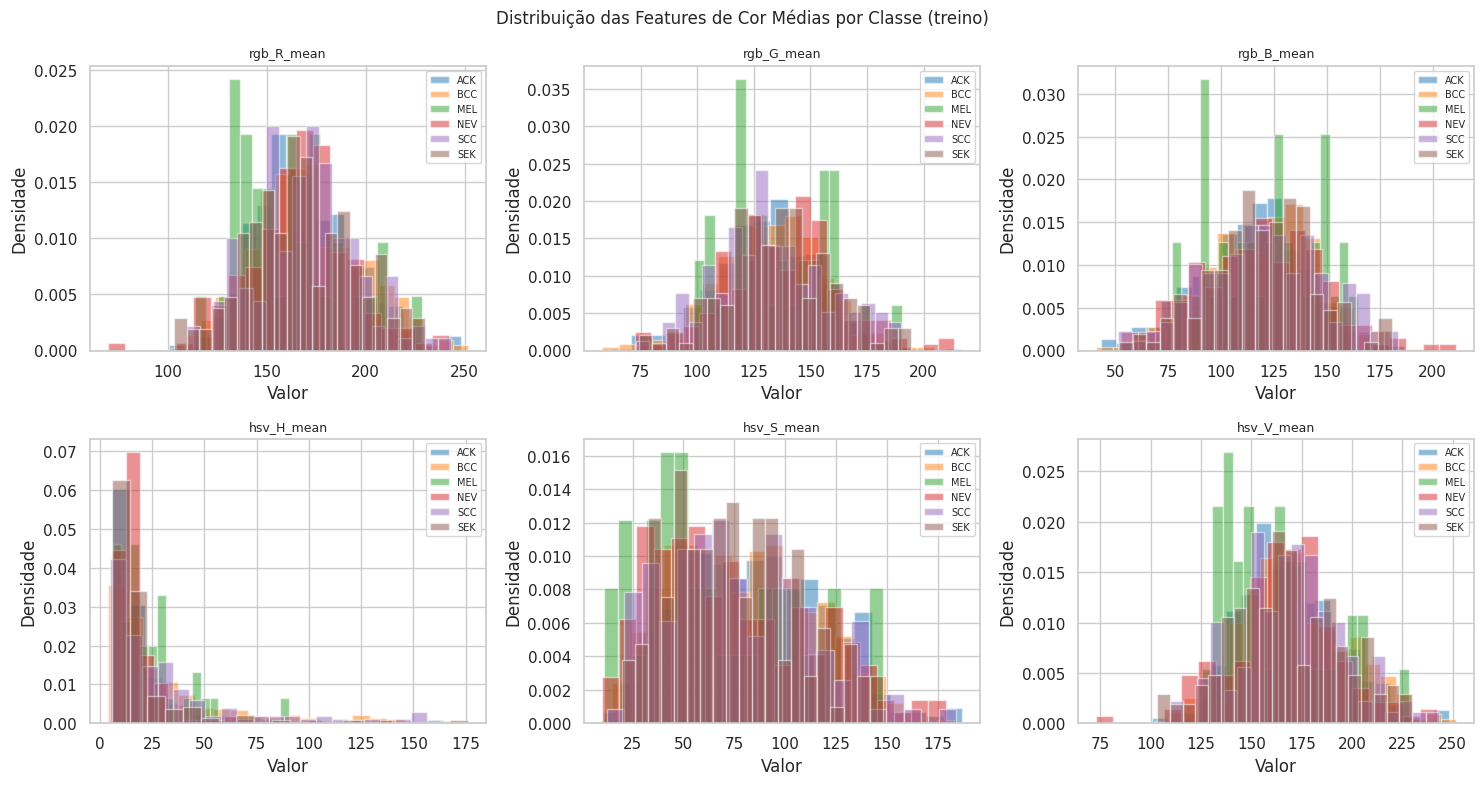

In [38]:
# Distribuição das features de cor por classe
pdi_with_label = pdi_train.copy()
pdi_with_label['diagnostic'] = df_train['diagnostic'].values

color_feats = [f for f in PDI_FEATURE_NAMES if f.startswith('rgb_') or f.startswith('hsv_')]
mean_feats  = [f for f in color_feats if f.endswith('_mean')]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, feat in zip(axes, mean_feats):
    for cls in CLASS_ORDER:
        vals = pdi_with_label[pdi_with_label['diagnostic'] == cls][feat]
        ax.hist(vals, bins=20, alpha=0.5, label=cls,
                color=CLASS_COLORS[cls], density=True)
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel('Valor')
    ax.set_ylabel('Densidade')
    ax.legend(fontsize=7)

plt.suptitle('Distribuição das Features de Cor Médias por Classe (treino)', fontsize=12)
plt.tight_layout()
plt.show()

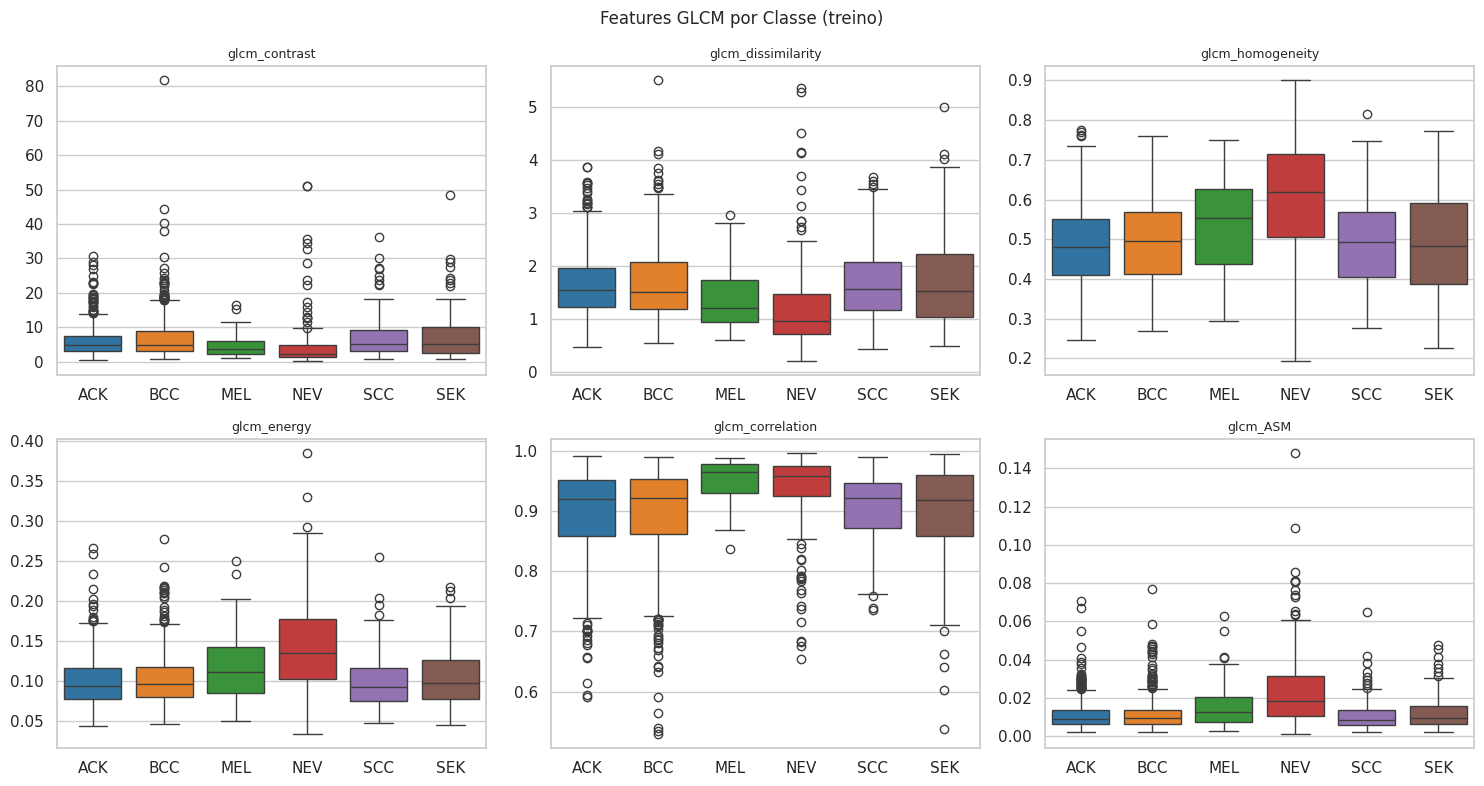

In [39]:
# Boxplots: features de textura GLCM por classe
glcm_feats = [f for f in PDI_FEATURE_NAMES if f.startswith('glcm_')]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

palette = [CLASS_COLORS[c] for c in CLASS_ORDER]
for ax, feat in zip(axes, glcm_feats):
    data_plot = pdi_with_label[['diagnostic', feat]].copy()
    sns.boxplot(data=data_plot, x='diagnostic', y=feat,
                order=CLASS_ORDER, palette=palette, ax=ax, linewidth=1.0)
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.suptitle('Features GLCM por Classe (treino)', fontsize=12)
plt.tight_layout()
plt.show()

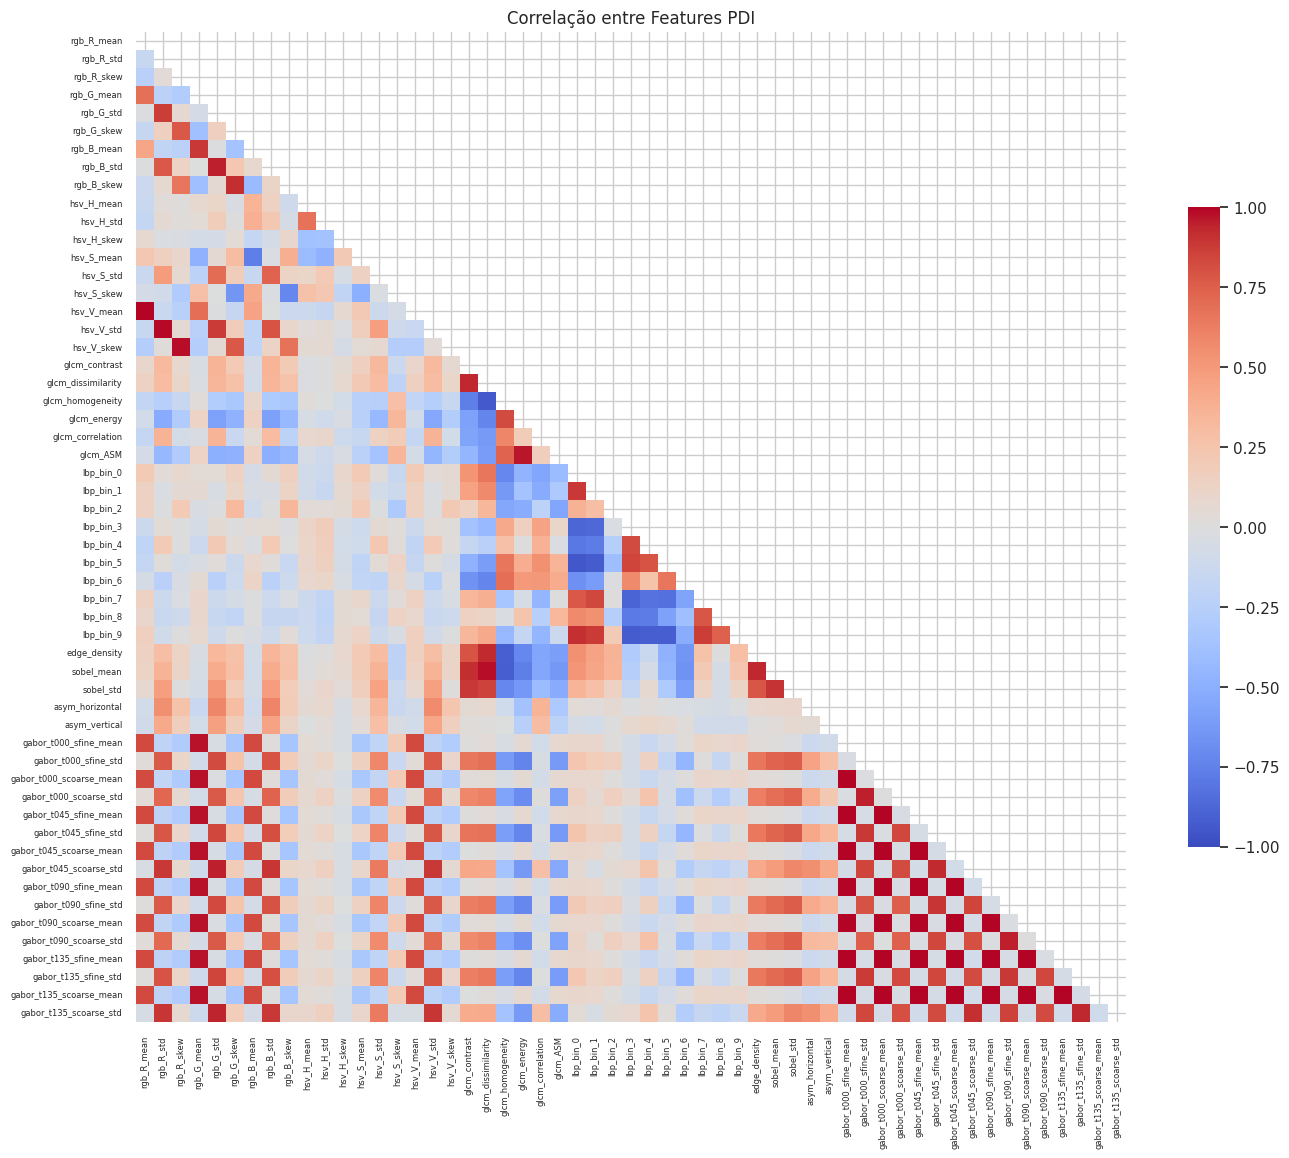

Pares com |r| > 0.9: 64
gabor_t135_scoarse_mean  gabor_t135_sfine_mean      1.000
                         gabor_t045_scoarse_mean    1.000
gabor_t135_sfine_mean    gabor_t090_sfine_mean      1.000
gabor_t045_scoarse_mean  gabor_t045_sfine_mean      1.000
gabor_t090_sfine_mean    gabor_t045_sfine_mean      1.000
gabor_t135_scoarse_mean  gabor_t090_sfine_mean      1.000
gabor_t090_sfine_mean    gabor_t045_scoarse_mean    1.000
gabor_t135_sfine_mean    gabor_t045_scoarse_mean    1.000
gabor_t135_scoarse_mean  gabor_t045_sfine_mean      1.000
gabor_t135_sfine_mean    gabor_t045_sfine_mean      1.000
                         gabor_t000_sfine_mean      0.999
gabor_t045_sfine_mean    gabor_t000_sfine_mean      0.999
gabor_t045_scoarse_mean  gabor_t000_sfine_mean      0.999
gabor_t135_scoarse_mean  gabor_t000_sfine_mean      0.999
gabor_t090_sfine_mean    gabor_t000_sfine_mean      0.999
hsv_V_mean               rgb_R_mean                 0.999
gabor_t090_scoarse_mean  gabor_t090_sfine_mean  

In [40]:
# Heatmap: correlação entre grupos de features PDI
# Mostra redundância interna — features muito correlatas podem ser removidas
pdi_corr = pdi_train.corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(pdi_corr, dtype=bool))
sns.heatmap(pdi_corr, mask=mask, cmap='coolwarm', center=0,
            vmin=-1, vmax=1, ax=ax, square=True,
            xticklabels=True, yticklabels=True,
            linewidths=0, cbar_kws={'shrink': 0.6})
ax.set_title('Correlação entre Features PDI', fontsize=12)
ax.tick_params(labelsize=6)
plt.tight_layout()
plt.show()

# Pares altamente correlacionados (|r| > 0.9)
high_corr = (
    pdi_corr.where(np.tril(np.ones_like(pdi_corr, dtype=bool), k=-1))
    .stack()
    .pipe(lambda s: s[s.abs() > 0.9])
    .sort_values(ascending=False)
)
print(f'Pares com |r| > 0.9: {len(high_corr)}')
if len(high_corr) > 0:
    print(high_corr.round(3).to_string())

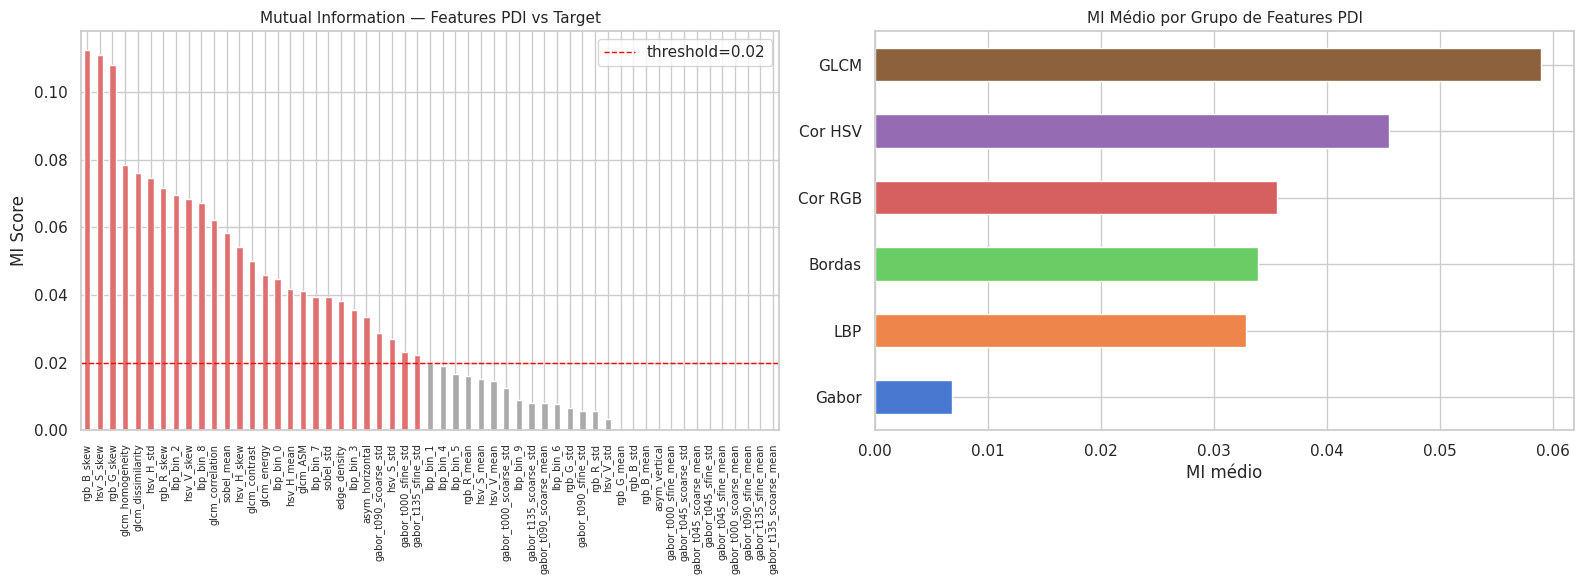

Feature PDI mais relevante : rgb_B_skew  (0.1123)
Feature PDI menos relevante: rgb_B_std  (0.0000)


In [41]:
# Mutual Information das features PDI com o target
mi_pdi = mutual_info_classif(
    pdi_train, y_train,
    discrete_features=False,  # PDI features são contínuas
    random_state=42, n_neighbors=5
)
mi_pdi_series = pd.Series(mi_pdi, index=PDI_FEATURE_NAMES).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

mi_pdi_series.plot(kind='bar', ax=axes[0],
                   color=['#e07070' if v > 0.02 else '#aaaaaa' for v in mi_pdi_series.values],
                   edgecolor='white')
axes[0].set_title('Mutual Information — Features PDI vs Target', fontsize=11)
axes[0].set_ylabel('MI Score')
axes[0].tick_params(axis='x', rotation=90, labelsize=7)
axes[0].axhline(0.02, color='red', linestyle='--', linewidth=1, label='threshold=0.02')
axes[0].legend()

# MI por grupo
groups = {'Cor RGB': [f for f in PDI_FEATURE_NAMES if f.startswith('rgb_')],
          'Cor HSV': [f for f in PDI_FEATURE_NAMES if f.startswith('hsv_')],
          'GLCM'   : [f for f in PDI_FEATURE_NAMES if f.startswith('glcm_')],
          'LBP'    : [f for f in PDI_FEATURE_NAMES if f.startswith('lbp_')],
          'Bordas' : [f for f in PDI_FEATURE_NAMES if f.startswith(('edge_','sobel_','asym_'))],
          'Gabor'  : [f for f in PDI_FEATURE_NAMES if f.startswith('gabor_')]}

group_mi = {g: mi_pdi_series[feats].mean() for g, feats in groups.items()}
pd.Series(group_mi).sort_values().plot(
    kind='barh', ax=axes[1],
    color=sns.color_palette('muted', len(group_mi)), edgecolor='white'
)
axes[1].set_title('MI Médio por Grupo de Features PDI', fontsize=11)
axes[1].set_xlabel('MI médio')

plt.tight_layout()
plt.show()

print(f'Feature PDI mais relevante : {mi_pdi_series.idxmax()}  ({mi_pdi_series.max():.4f})')
print(f'Feature PDI menos relevante: {mi_pdi_series.idxmin()}  ({mi_pdi_series.min():.4f})')

---
## PDI — Combinação com Features Tabulares
Cria o vetor final de features para o ML clássico:
**features tabulares selecionadas** + **features PDI**.

In [42]:
# Normalizar features PDI com o scaler ajustado no treino
pdi_scaler = StandardScaler()
pdi_scaler.fit(pdi_train)

def scale_pdi(pdi_df):
    return pd.DataFrame(
        pdi_scaler.transform(pdi_df),
        columns=PDI_FEATURE_NAMES,
        index=pdi_df.index
    )

pdi_train_sc = scale_pdi(pdi_train)
pdi_val_sc   = scale_pdi(pdi_val)
pdi_test_sc  = scale_pdi(pdi_test)

# Concatena tabular + PDI (alinhamento por reset_index)
X_train_full = pd.concat(
    [X_train_sel.reset_index(drop=True), pdi_train_sc.reset_index(drop=True)], axis=1
)
X_val_full = pd.concat(
    [X_val_sel.reset_index(drop=True), pdi_val_sc.reset_index(drop=True)], axis=1
)
X_test_full = pd.concat(
    [X_test_sel.reset_index(drop=True), pdi_test_sc.reset_index(drop=True)], axis=1
)

# Versão sem biopsed + PDI
X_train_full_nb = pd.concat(
    [X_train_nb.reset_index(drop=True), pdi_train_sc.reset_index(drop=True)], axis=1
)
X_val_full_nb = pd.concat(
    [X_val_nb.reset_index(drop=True), pdi_val_sc.reset_index(drop=True)], axis=1
)
X_test_full_nb = pd.concat(
    [X_test_nb.reset_index(drop=True), pdi_test_sc.reset_index(drop=True)], axis=1
)

# Garantia
for name, X in [('train_full', X_train_full), ('val_full', X_val_full), ('test_full', X_test_full)]:
    assert X.isnull().sum().sum() == 0, f'NaN em {name}!'

print('Composição do vetor final (com biopsed):')
print(f'  Features tabulares : {X_train_sel.shape[1]}')
print(f'  Features PDI       : {len(PDI_FEATURE_NAMES)}')
print(f'  Total              : {X_train_full.shape[1]}')
print(f'\nX_train_full : {X_train_full.shape}')
print(f'X_val_full   : {X_val_full.shape}')
print(f'X_test_full  : {X_test_full.shape}')

Composição do vetor final (com biopsed):
  Features tabulares : 40
  Features PDI       : 55
  Total              : 95

X_train_full : (1608, 95)
X_val_full   : (345, 95)
X_test_full  : (345, 95)


In [43]:
print('=' * 60)
print('ESTADO FINAL — FEATURES PARA ML CLÁSSICO')
print('=' * 60)
print()
print('Vetores disponíveis (treino / val / teste):')
print(f'  X_train_full    / X_val_full    / X_test_full    → {X_train_full.shape[1]} features (tabular + PDI, com biopsed)')
print(f'  X_train_full_nb / X_val_full_nb / X_test_full_nb → {X_train_full_nb.shape[1]} features (tabular + PDI, sem biopsed)')
print(f'  X_train_sel     / X_val_sel     / X_test_sel     → {X_train_sel.shape[1]} features (só tabular, com biopsed)')
print(f'  X_train_nb      / X_val_nb      / X_test_nb      → {X_train_nb.shape[1]} features (só tabular, sem biopsed)')
print()
print('Targets: y_train / y_val / y_test  (0=ACK, 1=BCC, 2=MEL, 3=NEV, 4=SCC, 5=SEK)')
print('Pesos  : class_weight_dict')
print()
print('Artifatos PDI:')
print('  pdi_scaler          → StandardScaler ajustado no pdi_train')
print('  PDI_FEATURE_NAMES   → lista de 55 nomes de features')
print('  extract_pdi_features(path) → extrai 55 features de uma imagem nova')
print()
print('Próxima etapa: ML Clássico (Random Forest, SVM, XGBoost, k-NN)')


ESTADO FINAL — FEATURES PARA ML CLÁSSICO

Vetores disponíveis (treino / val / teste):
  X_train_full    / X_val_full    / X_test_full    → 95 features (tabular + PDI, com biopsed)
  X_train_full_nb / X_val_full_nb / X_test_full_nb → 94 features (tabular + PDI, sem biopsed)
  X_train_sel     / X_val_sel     / X_test_sel     → 40 features (só tabular, com biopsed)
  X_train_nb      / X_val_nb      / X_test_nb      → 39 features (só tabular, sem biopsed)

Targets: y_train / y_val / y_test  (0=ACK, 1=BCC, 2=MEL, 3=NEV, 4=SCC, 5=SEK)
Pesos  : class_weight_dict

Artifatos PDI:
  pdi_scaler          → StandardScaler ajustado no pdi_train
  PDI_FEATURE_NAMES   → lista de 55 nomes de features
  extract_pdi_features(path) → extrai 55 features de uma imagem nova

Próxima etapa: ML Clássico (Random Forest, SVM, XGBoost, k-NN)


## 6. ML Clássico

### Estrutura da análise

| Etapa | Objetivo |
|-------|----------|
| **6. RF — Modelo Complexo** | Avaliar até onde um modelo poderoso chega e identificar overfitting |
| **7. DT — Modelo Simples** | Mostrar que modelo simples é competitivo com muito menos complexidade |
| **8. Ato 1 — Evidência** | Quantificar o ganho real de complexidade adicional |
| **9. Ato 2 — Ablação** | Avaliar o impacto das features PDI sobre os metadados clínicos |
| **10. Comparativo Final** | RF vs DT — síntese dos resultados |

**Features:** `X_train_full` — 95 features (40 tabular + 55 PDI)  
**Métricas:** F1-macro, Acurácia, AUC-ROC, F1 por classe  
**Desbalanceamento:** SMOTE dentro do pipeline de CV (sem leakage)

In [44]:
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.ensemble        import RandomForestClassifier
from sklearn.tree            import DecisionTreeClassifier
from sklearn.model_selection import (RandomizedSearchCV, GridSearchCV,
                                     StratifiedKFold, learning_curve,
                                     validation_curve)
from sklearn.metrics         import (accuracy_score, f1_score,
                                     classification_report, confusion_matrix,
                                     roc_auc_score, roc_curve, auc,
                                     make_scorer)
from sklearn.preprocessing   import label_binarize
from imblearn.pipeline       import Pipeline as ImbPipeline
from imblearn.over_sampling  import SMOTE
from matplotlib.patches      import Patch
from scipy.stats             import randint
import time, warnings
warnings.filterwarnings('ignore')

CLASS_NAMES = list(le_target.classes_)
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scorer_f1 = make_scorer(f1_score, average='macro', zero_division=0)

def avaliar_modelo(nome, modelo, X_tr, y_tr, X_vl, y_vl):
    pred_tr  = modelo.predict(X_tr)
    pred_vl  = modelo.predict(X_vl)
    prob_vl  = modelo.predict_proba(X_vl) if hasattr(modelo, 'predict_proba') else None
    acc_tr   = accuracy_score(y_tr, pred_tr)
    acc_vl   = accuracy_score(y_vl, pred_vl)
    f1_tr    = f1_score(y_tr, pred_tr, average='macro', zero_division=0)
    f1_vl    = f1_score(y_vl, pred_vl, average='macro', zero_division=0)
    auc_vl   = (roc_auc_score(y_vl, prob_vl, multi_class='ovr', average='macro')
                if prob_vl is not None else float('nan'))
    sep = '=' * 55
    print(sep)
    print(nome)
    print(sep)
    print(f'  Acuracia  treino={acc_tr:.4f}  val={acc_vl:.4f}  delta={acc_tr-acc_vl:+.4f}')
    print(f'  F1-macro  treino={f1_tr:.4f}  val={f1_vl:.4f}  delta={f1_tr-f1_vl:+.4f}')
    print(f'  AUC-ROC val: {auc_vl:.4f}')
    print()
    print(classification_report(y_vl, pred_vl, target_names=CLASS_NAMES, zero_division=0))
    return dict(nome=nome, acc_tr=acc_tr, acc_vl=acc_vl,
                f1_tr=f1_tr, f1_vl=f1_vl, auc_vl=auc_vl,
                pred_vl=pred_vl, y_vl=y_vl)

def plot_confusion(resultados, titulo):
    n = len(resultados)
    fig, axes = plt.subplots(1, n, figsize=(7*n, 5))
    if n == 1: axes = [axes]
    for ax, res in zip(axes, resultados):
        cm = confusion_matrix(res['y_vl'], res['pred_vl'])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
        ax.set_title(res['nome'], fontsize=11)
        ax.set_xlabel('Predito'); ax.set_ylabel('Real')
    fig.suptitle(titulo, fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

print('Helpers carregados.')

Helpers carregados.


### 6.1 Random Forest — Modelo Complexo

Três configurações progressivas:

1. **class_weight** — sem alterar o dataset, apenas penaliza erros nas classes raras
2. **SMOTE** — oversampling das classes minoritárias no treino
3. **Tuned** — busca de hiperparâmetros com regularização (`min_samples_leaf >= 2`, `max_depth <= 25`)

In [45]:
rf_cw = RandomForestClassifier(
    n_estimators=300, min_samples_leaf=2,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_cw.fit(X_train_full, y_train)
res_rf_cw = avaliar_modelo('RF — class_weight', rf_cw, X_train_full, y_train, X_val_full, y_val)

RF — class_weight
  Acuracia  treino=0.9988  val=0.7623  delta=+0.2364
  F1-macro  treino=0.9984  val=0.5855  delta=+0.4128
  AUC-ROC val: 0.9344

              precision    recall  f1-score   support

         ACK       0.85      0.81      0.83       109
         BCC       0.68      0.99      0.81       127
         MEL       1.00      0.25      0.40         8
         NEV       0.90      0.73      0.81        37
         SCC       0.00      0.00      0.00        29
         SEK       0.80      0.57      0.67        35

    accuracy                           0.76       345
   macro avg       0.71      0.56      0.59       345
weighted avg       0.72      0.76      0.72       345



In [46]:
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train_full, y_train)
print(f'Treino original: {X_train_full.shape[0]}  |  SMOTE: {X_train_sm.shape[0]}')

rf_sm = RandomForestClassifier(
    n_estimators=300, min_samples_leaf=2,
    random_state=42, n_jobs=-1
)
rf_sm.fit(X_train_sm, y_train_sm)
res_rf_sm = avaliar_modelo('RF — SMOTE', rf_sm, X_train_sm, y_train_sm, X_val_full, y_val)

Treino original: 1608  |  SMOTE: 3546


RF — SMOTE
  Acuracia  treino=0.9997  val=0.7855  delta=+0.2142
  F1-macro  treino=0.9997  val=0.6945  delta=+0.3052
  AUC-ROC val: 0.9469

              precision    recall  f1-score   support

         ACK       0.91      0.79      0.85       109
         BCC       0.70      0.98      0.82       127
         MEL       1.00      0.62      0.77         8
         NEV       0.85      0.76      0.80        37
         SCC       0.50      0.10      0.17        29
         SEK       0.86      0.69      0.76        35

    accuracy                           0.79       345
   macro avg       0.80      0.66      0.69       345
weighted avg       0.79      0.79      0.76       345



In [47]:
pipe_rf = ImbPipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=5)),
    ('rf',    RandomForestClassifier(random_state=42, n_jobs=-1))
])
param_dist_rf = {
    'rf__n_estimators':     randint(200, 600),
    'rf__max_depth':        [10, 15, 20, 25],
    'rf__min_samples_leaf': randint(2, 12),
    'rf__max_features':     ['sqrt', 'log2', 0.3],
    'rf__class_weight':     [None, 'balanced'],
}
search_rf = RandomizedSearchCV(
    pipe_rf, param_distributions=param_dist_rf,
    n_iter=30, scoring=scorer_f1, cv=cv5,
    refit=True, n_jobs=-1, random_state=42, verbose=1
)
t0 = time.time()
search_rf.fit(X_train_full, y_train)
print(f'\nConcluido em {time.time()-t0:.1f}s  |  Melhor F1-macro CV: {search_rf.best_score_:.4f}')
print('Melhores parametros:')
for k, v in search_rf.best_params_.items():
    print(f'  {k}: {v}')

res_rf_tuned = avaliar_modelo(
    'RF Tuned (SMOTE+CV)', search_rf.best_estimator_,
    X_train_full, y_train, X_val_full, y_val
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits



Concluido em 146.4s  |  Melhor F1-macro CV: 0.6681
Melhores parametros:
  rf__class_weight: None
  rf__max_depth: 15
  rf__max_features: 0.3
  rf__min_samples_leaf: 4
  rf__n_estimators: 563


RF Tuned (SMOTE+CV)
  Acuracia  treino=0.9558  val=0.7855  delta=+0.1703
  F1-macro  treino=0.9614  val=0.7027  delta=+0.2587
  AUC-ROC val: 0.9438

              precision    recall  f1-score   support

         ACK       0.90      0.78      0.84       109
         BCC       0.72      0.98      0.83       127
         MEL       0.86      0.75      0.80         8
         NEV       0.82      0.76      0.79        37
         SCC       0.44      0.14      0.21        29
         SEK       0.83      0.69      0.75        35

    accuracy                           0.79       345
   macro avg       0.76      0.68      0.70       345
weighted avg       0.78      0.79      0.77       345



#### Análise do RF Tuned

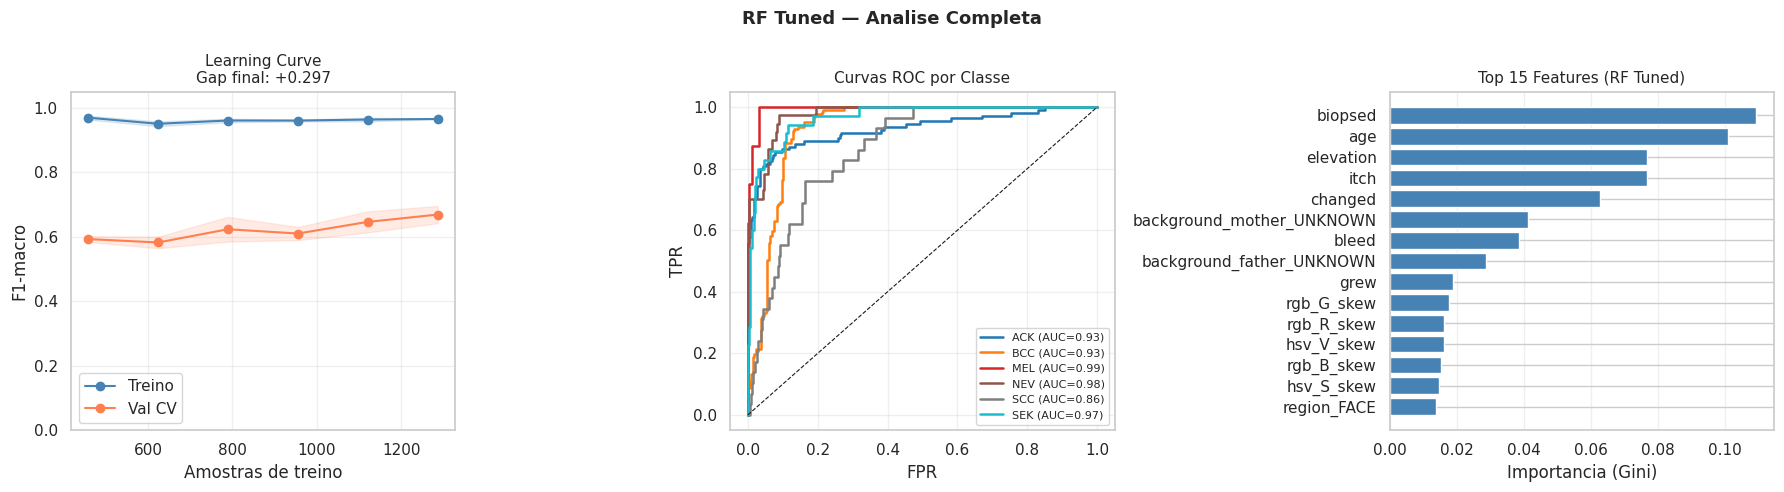

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Learning curve ---
tr_sz, tr_sc, vl_sc = learning_curve(
    search_rf.best_estimator_, X_train_full, y_train,
    cv=cv5, scoring=scorer_f1,
    train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1
)
tr_m, tr_s = tr_sc.mean(1), tr_sc.std(1)
vl_m, vl_s = vl_sc.mean(1), vl_sc.std(1)
axes[0].plot(tr_sz, tr_m, 'o-', color='steelblue', label='Treino')
axes[0].fill_between(tr_sz, tr_m-tr_s, tr_m+tr_s, alpha=0.15, color='steelblue')
axes[0].plot(tr_sz, vl_m, 'o-', color='coral', label='Val CV')
axes[0].fill_between(tr_sz, vl_m-vl_s, vl_m+vl_s, alpha=0.15, color='coral')
axes[0].set_title(f'Learning Curve\nGap final: {tr_m[-1]-vl_m[-1]:+.3f}', fontsize=11)
axes[0].set_xlabel('Amostras de treino'); axes[0].set_ylabel('F1-macro')
axes[0].legend(); axes[0].grid(alpha=0.3); axes[0].set_ylim(0, 1.05)

# --- ROC por classe ---
y_vl_bin = label_binarize(y_val, classes=list(range(len(CLASS_NAMES))))
prob_rf   = search_rf.best_estimator_.predict_proba(X_val_full)
colors_cls = plt.cm.tab10(np.linspace(0, 0.9, len(CLASS_NAMES)))
for i, (cls, color) in enumerate(zip(CLASS_NAMES, colors_cls)):
    fpr, tpr, _ = roc_curve(y_vl_bin[:, i], prob_rf[:, i])
    axes[1].plot(fpr, tpr, color=color, lw=1.8, label=f'{cls} (AUC={auc(fpr,tpr):.2f})')
axes[1].plot([0,1],[0,1],'k--',lw=0.8)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('Curvas ROC por Classe', fontsize=11)
axes[1].legend(loc='lower right', fontsize=8); axes[1].grid(alpha=0.3)

# --- Feature importance top 15 ---
rf_step  = search_rf.best_estimator_.named_steps['rf']
imp_rf   = pd.Series(rf_step.feature_importances_, index=X_train_full.columns)
top15    = imp_rf.nlargest(15)
axes[2].barh(top15.index[::-1], top15.values[::-1], color='steelblue')
axes[2].set_title('Top 15 Features (RF Tuned)', fontsize=11)
axes[2].set_xlabel('Importancia (Gini)'); axes[2].grid(axis='x', alpha=0.3)

plt.suptitle('RF Tuned — Analise Completa', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

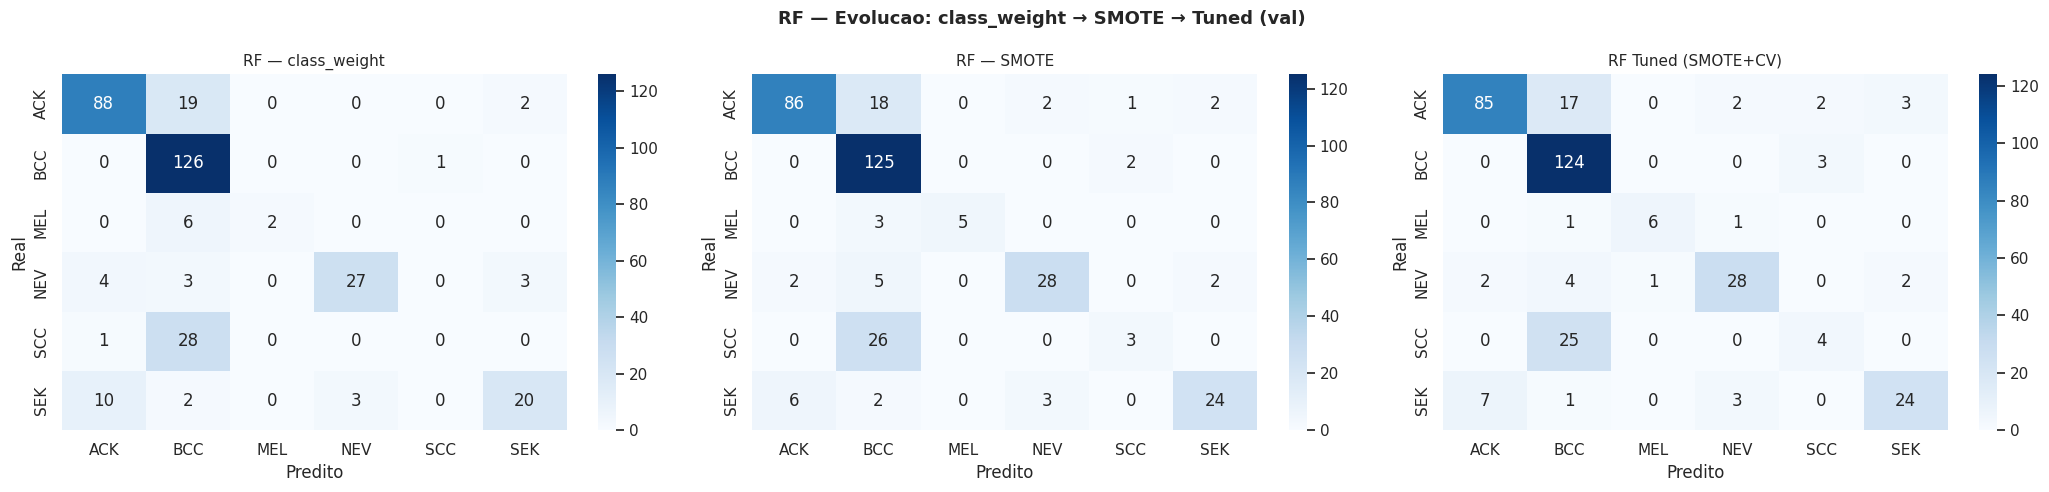

In [49]:
plot_confusion([res_rf_cw, res_rf_sm, res_rf_tuned],
               'RF — Evolucao: class_weight → SMOTE → Tuned (val)')

## 7. Decision Tree — Modelo Simples

Árvore de decisão com `max_depth` controlado: interpretável, muito menos complexa que o RF.  
Se os resultados forem competitivos, o problema não exige alta complexidade.

In [50]:
pipe_dt = ImbPipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=5)),
    ('dt',    DecisionTreeClassifier(random_state=42))
])
param_grid_dt = {
    'dt__max_depth':        [3, 5, 7, 10, 15],
    'dt__min_samples_leaf': [2, 5, 10, 20],
    'dt__criterion':        ['gini', 'entropy'],
    'dt__class_weight':     [None, 'balanced'],
}
search_dt = GridSearchCV(
    pipe_dt, param_grid=param_grid_dt,
    scoring=scorer_f1, cv=cv5,
    refit=True, n_jobs=-1, verbose=1
)
t0 = time.time()
search_dt.fit(X_train_full, y_train)
print(f'\nConcluido em {time.time()-t0:.1f}s  |  Melhor F1-macro CV: {search_dt.best_score_:.4f}')
print('Melhores parametros:')
for k, v in search_dt.best_params_.items():
    print(f'  {k}: {v}')

res_dt_tuned = avaliar_modelo(
    'DT Tuned (SMOTE+CV)', search_dt.best_estimator_,
    X_train_full, y_train, X_val_full, y_val
)

Fitting 5 folds for each of 80 candidates, totalling 400 fits



Concluido em 15.5s  |  Melhor F1-macro CV: 0.5770
Melhores parametros:
  dt__class_weight: None
  dt__criterion: entropy
  dt__max_depth: 7
  dt__min_samples_leaf: 10
DT Tuned (SMOTE+CV)
  Acuracia  treino=0.7456  val=0.6870  delta=+0.0587
  F1-macro  treino=0.7202  val=0.6177  delta=+0.1026
  AUC-ROC val: 0.8638

              precision    recall  f1-score   support

         ACK       0.91      0.73      0.81       109
         BCC       0.70      0.76      0.73       127
         MEL       0.62      0.62      0.62         8
         NEV       0.62      0.76      0.68        37
         SCC       0.16      0.21      0.18        29
         SEK       0.78      0.60      0.68        35

    accuracy                           0.69       345
   macro avg       0.63      0.61      0.62       345
weighted avg       0.72      0.69      0.70       345



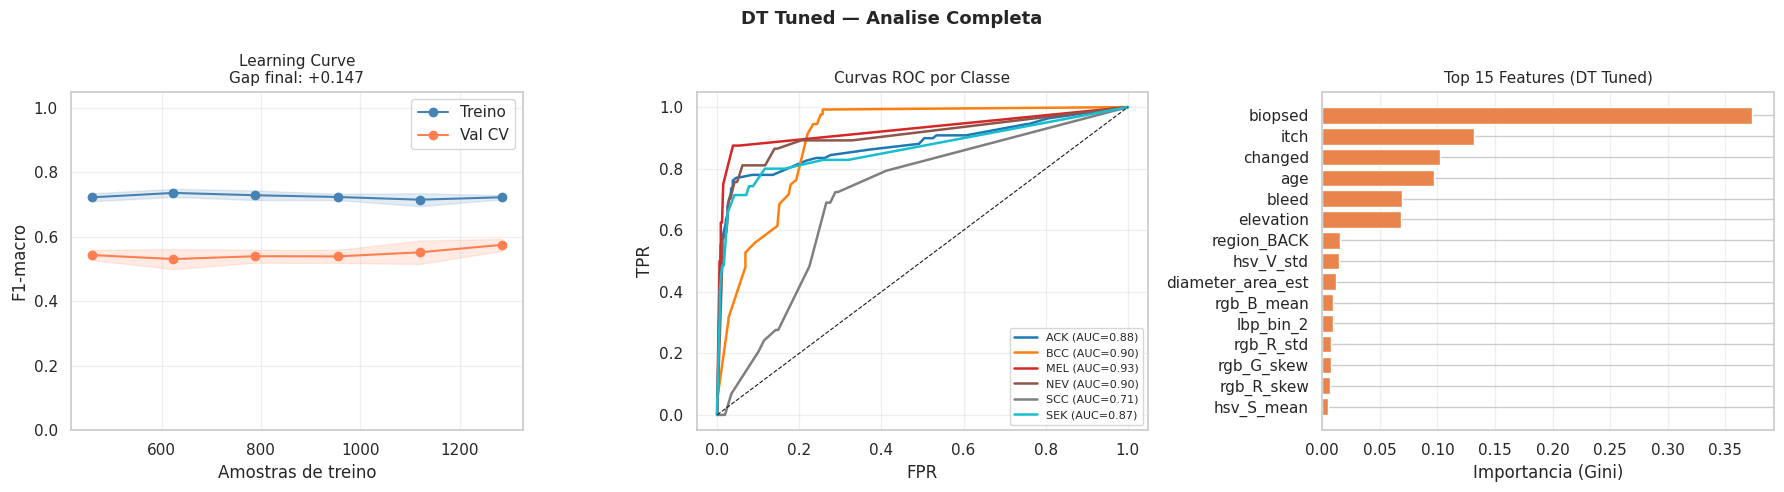

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Learning curve ---
tr_sz, tr_sc, vl_sc = learning_curve(
    search_dt.best_estimator_, X_train_full, y_train,
    cv=cv5, scoring=scorer_f1,
    train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1
)
tr_m, tr_s = tr_sc.mean(1), tr_sc.std(1)
vl_m, vl_s = vl_sc.mean(1), vl_sc.std(1)
axes[0].plot(tr_sz, tr_m, 'o-', color='steelblue', label='Treino')
axes[0].fill_between(tr_sz, tr_m-tr_s, tr_m+tr_s, alpha=0.15, color='steelblue')
axes[0].plot(tr_sz, vl_m, 'o-', color='coral', label='Val CV')
axes[0].fill_between(tr_sz, vl_m-vl_s, vl_m+vl_s, alpha=0.15, color='coral')
axes[0].set_title(f'Learning Curve\nGap final: {tr_m[-1]-vl_m[-1]:+.3f}', fontsize=11)
axes[0].set_xlabel('Amostras de treino'); axes[0].set_ylabel('F1-macro')
axes[0].legend(); axes[0].grid(alpha=0.3); axes[0].set_ylim(0, 1.05)

# --- ROC por classe ---
prob_dt = search_dt.best_estimator_.predict_proba(X_val_full)
for i, (cls, color) in enumerate(zip(CLASS_NAMES, colors_cls)):
    fpr, tpr, _ = roc_curve(y_vl_bin[:, i], prob_dt[:, i])
    axes[1].plot(fpr, tpr, color=color, lw=1.8, label=f'{cls} (AUC={auc(fpr,tpr):.2f})')
axes[1].plot([0,1],[0,1],'k--',lw=0.8)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('Curvas ROC por Classe', fontsize=11)
axes[1].legend(loc='lower right', fontsize=8); axes[1].grid(alpha=0.3)

# --- Feature importance top 15 ---
dt_step = search_dt.best_estimator_.named_steps['dt']
imp_dt  = pd.Series(dt_step.feature_importances_, index=X_train_full.columns)
top15dt = imp_dt.nlargest(15)
axes[2].barh(top15dt.index[::-1], top15dt.values[::-1], color='#e8844c')
axes[2].set_title('Top 15 Features (DT Tuned)', fontsize=11)
axes[2].set_xlabel('Importancia (Gini)'); axes[2].grid(axis='x', alpha=0.3)

plt.suptitle('DT Tuned — Analise Completa', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

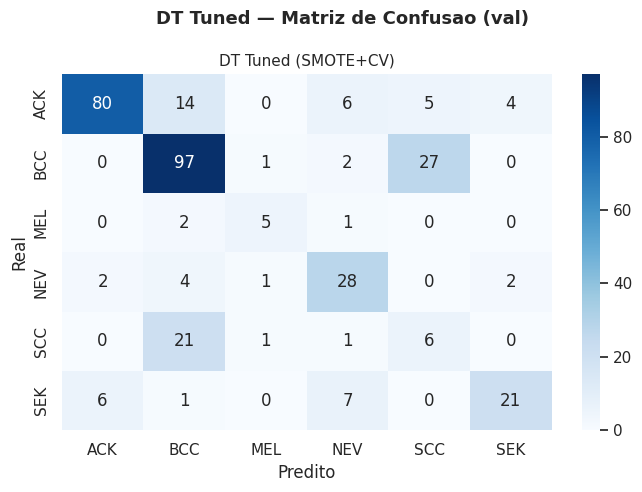

In [52]:
plot_confusion([res_dt_tuned], 'DT Tuned — Matriz de Confusao (val)')

## 8. Ato 1 — Evidência de Problema Simples

Duas análises que quantificam se o problema exige alta complexidade:

1. **Curva de validação** — a partir de qual `max_depth` o DT satura?
2. **Complexidade vs Ganho** — quanto de F1 o RF ganha sobre o DT pelo custo de centenas de árvores?

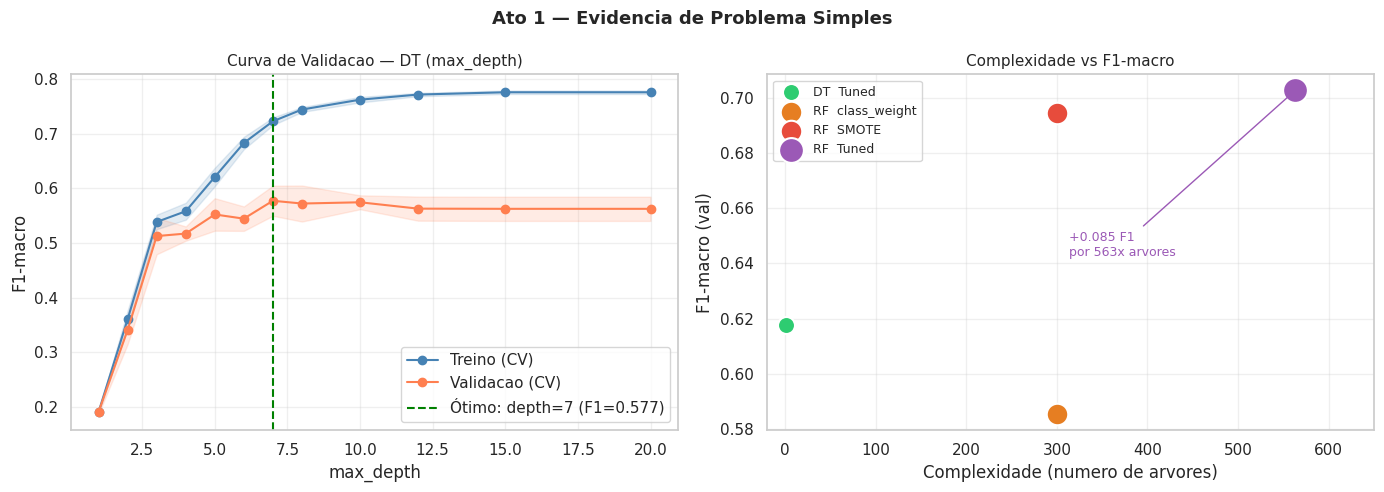

Saturacao em max_depth=7  |  Ganho depth=7→20: -0.0147
Ganho RF Tuned vs DT Tuned: +0.0850 F1  com 563 arvores adicionais


In [53]:
depths = [1, 2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 20]

pipe_dt_vc = ImbPipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=5)),
    ('dt',    DecisionTreeClassifier(criterion='entropy', min_samples_leaf=10, random_state=42))
])
tr_sc, vl_sc = validation_curve(
    pipe_dt_vc, X_train_full, y_train,
    param_name='dt__max_depth', param_range=depths,
    scoring=scorer_f1,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1
)
tr_m, tr_s = tr_sc.mean(1), tr_sc.std(1)
vl_m, vl_s = vl_sc.mean(1), vl_sc.std(1)
best_idx   = vl_m.argmax()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva de validação
axes[0].plot(depths, tr_m, 'o-', color='steelblue', label='Treino (CV)')
axes[0].fill_between(depths, tr_m-tr_s, tr_m+tr_s, alpha=0.15, color='steelblue')
axes[0].plot(depths, vl_m, 'o-', color='coral', label='Validacao (CV)')
axes[0].fill_between(depths, vl_m-vl_s, vl_m+vl_s, alpha=0.15, color='coral')
axes[0].axvline(depths[best_idx], color='green', linestyle='--', lw=1.5,
                label=f'Ótimo: depth={depths[best_idx]} (F1={vl_m[best_idx]:.3f})')
axes[0].set_xlabel('max_depth'); axes[0].set_ylabel('F1-macro')
axes[0].set_title('Curva de Validacao — DT (max_depth)', fontsize=11)
axes[0].legend(); axes[0].grid(alpha=0.3)

# Complexidade vs ganho
modelos_c = [
    ('DT  Tuned',        res_dt_tuned['f1_vl'], res_dt_tuned['auc_vl'],  1),
    ('RF  class_weight', res_rf_cw['f1_vl'],    res_rf_cw['auc_vl'],    300),
    ('RF  SMOTE',        res_rf_sm['f1_vl'],    res_rf_sm['auc_vl'],    300),
    ('RF  Tuned',        res_rf_tuned['f1_vl'], res_rf_tuned['auc_vl'], search_rf.best_params_['rf__n_estimators']),
]
cores_c = ['#2ecc71', '#e67e22', '#e74c3c', '#9b59b6']
for i, (nome, f1, _, ne) in enumerate(modelos_c):
    axes[1].scatter(ne, f1, s=150+ne*0.3, color=cores_c[i],
                    zorder=3, label=nome, edgecolors='white', lw=1.5)
axes[1].set_xlabel('Complexidade (numero de arvores)')
axes[1].set_ylabel('F1-macro (val)')
axes[1].set_title('Complexidade vs F1-macro', fontsize=11)
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3); axes[1].set_xlim(-20, 650)

f1_dt = res_dt_tuned['f1_vl']
f1_rf = res_rf_tuned['f1_vl']
n_rf  = modelos_c[-1][3]
axes[1].annotate(
    f'+{f1_rf-f1_dt:.3f} F1\npor {n_rf}x arvores',
    xy=(n_rf, f1_rf), xytext=(n_rf-250, f1_rf-0.06),
    fontsize=9, color='#9b59b6',
    arrowprops=dict(arrowstyle='->', color='#9b59b6')
)

plt.suptitle('Ato 1 — Evidencia de Problema Simples', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f'Saturacao em max_depth={depths[best_idx]}  |  Ganho depth=7→20: {vl_m[-1]-vl_m[best_idx]:+.4f}')
print(f'Ganho RF Tuned vs DT Tuned: +{f1_rf-f1_dt:.4f} F1  com {n_rf} arvores adicionais')

## 9. Ato 2 — Ablação de Features

**Mesmo modelo** (DT com parâmetros do tuning), **três conjuntos de features**:  

| Experimento | Features | Pergunta |
|-------------|----------|----------|
| Tabular only | 40 features clínicas | O que os metadados sozinhos conseguem? |
| PDI only | 55 features de imagem | Imagem sem contexto clínico |
| Tabular + PDI | 95 features | PDI acrescenta ao clínico? |

In [54]:
dt_params = dict(
    criterion=search_dt.best_params_['dt__criterion'],
    max_depth=search_dt.best_params_['dt__max_depth'],
    min_samples_leaf=search_dt.best_params_['dt__min_samples_leaf'],
    class_weight=search_dt.best_params_['dt__class_weight'],
    random_state=42
)
print('Parametros fixos do DT:', dt_params)

def treinar_dt_ablacao(X_tr, y_tr, X_vl, y_vl, nome):
    pipe = ImbPipeline([
        ('smote', SMOTE(random_state=42, k_neighbors=5)),
        ('dt',    DecisionTreeClassifier(**dt_params))
    ])
    pipe.fit(X_tr, y_tr)
    return avaliar_modelo(nome, pipe, X_tr, y_tr, X_vl, y_vl)

X_train_pdi = pdi_train_sc.reset_index(drop=True)
X_val_pdi   = pdi_val_sc.reset_index(drop=True)

res_abl_tab = treinar_dt_ablacao(X_train_sel,  y_train, X_val_sel,  y_val, 'DT — Tabular only')
res_abl_pdi = treinar_dt_ablacao(X_train_pdi,  y_train, X_val_pdi,  y_val, 'DT — PDI only')
res_abl_ful = treinar_dt_ablacao(X_train_full, y_train, X_val_full, y_val, 'DT — Tabular+PDI')

resultados_ablacao = [res_abl_tab, res_abl_pdi, res_abl_ful]

Parametros fixos do DT: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 10, 'class_weight': None, 'random_state': 42}
DT — Tabular only
  Acuracia  treino=0.7220  val=0.6841  delta=+0.0380
  F1-macro  treino=0.6813  val=0.5759  delta=+0.1054
  AUC-ROC val: 0.8630

              precision    recall  f1-score   support

         ACK       0.93      0.75      0.83       109
         BCC       0.76      0.73      0.74       127
         MEL       0.24      0.50      0.32         8
         NEV       0.64      0.76      0.69        37
         SCC       0.23      0.34      0.27        29
         SEK       0.66      0.54      0.59        35

    accuracy                           0.68       345
   macro avg       0.57      0.60      0.58       345
weighted avg       0.73      0.68      0.70       345



DT — PDI only
  Acuracia  treino=0.4185  val=0.2899  delta=+0.1287
  F1-macro  treino=0.4364  val=0.2663  delta=+0.1700
  AUC-ROC val: 0.6590

              precision    recall  f1-score   support

         ACK       0.57      0.30      0.40       109
         BCC       0.48      0.23      0.31       127
         MEL       0.09      0.38      0.15         8
         NEV       0.36      0.51      0.42        37
         SCC       0.09      0.34      0.14        29
         SEK       0.19      0.17      0.18        35

    accuracy                           0.29       345
   macro avg       0.30      0.32      0.27       345
weighted avg       0.42      0.29      0.32       345



DT — Tabular+PDI
  Acuracia  treino=0.7456  val=0.6870  delta=+0.0587
  F1-macro  treino=0.7202  val=0.6177  delta=+0.1026
  AUC-ROC val: 0.8638

              precision    recall  f1-score   support

         ACK       0.91      0.73      0.81       109
         BCC       0.70      0.76      0.73       127
         MEL       0.62      0.62      0.62         8
         NEV       0.62      0.76      0.68        37
         SCC       0.16      0.21      0.18        29
         SEK       0.78      0.60      0.68        35

    accuracy                           0.69       345
   macro avg       0.63      0.61      0.62       345
weighted avg       0.72      0.69      0.70       345



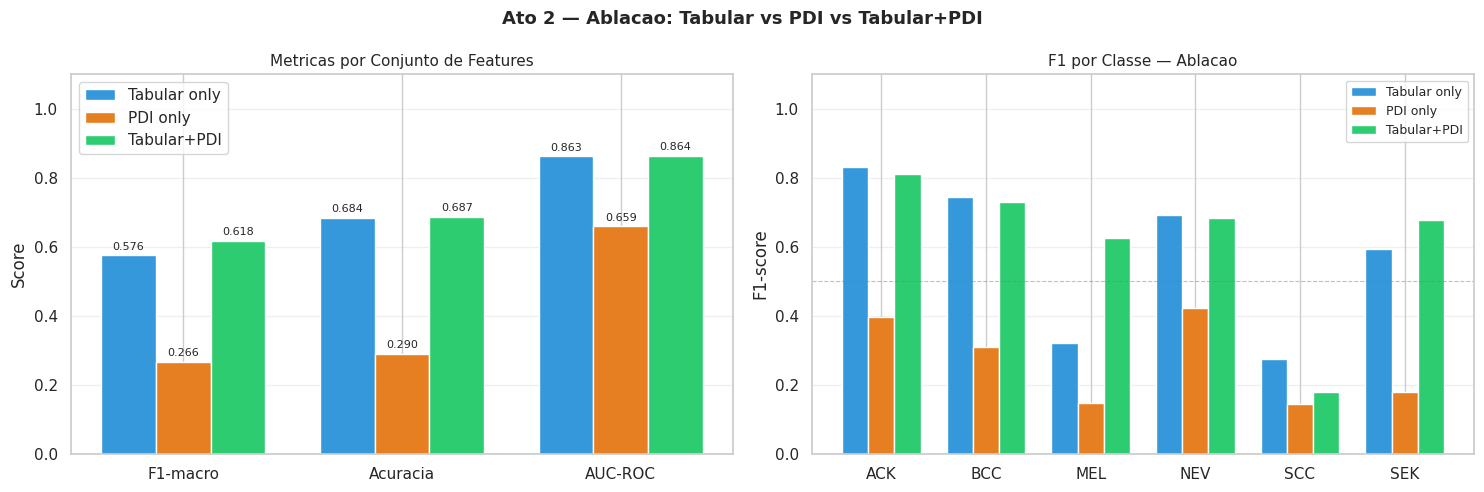

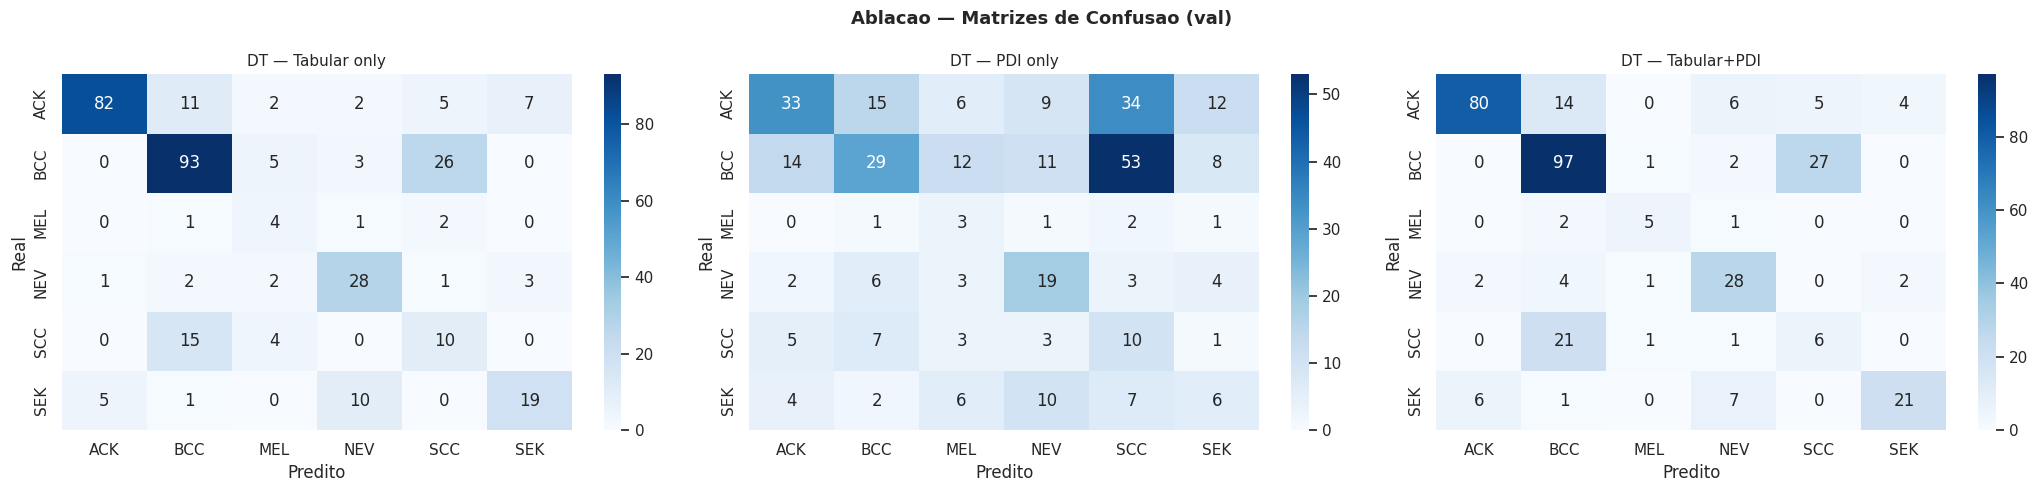

In [55]:
cores_abl = ['#3498db', '#e67e22', '#2ecc71']
labels_abl = ['Tabular only', 'PDI only', 'Tabular+PDI']
metricas   = ['F1-macro', 'Acuracia', 'AUC-ROC']
vals       = [[r['f1_vl'], r['acc_vl'], r['auc_vl']] for r in resultados_ablacao]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Barplot metricas gerais
x = np.arange(len(metricas))
w = 0.25
for i, (res, cor, lbl) in enumerate(zip(resultados_ablacao, cores_abl, labels_abl)):
    v = [res['f1_vl'], res['acc_vl'], res['auc_vl']]
    bars = axes[0].bar(x + (i-1)*w, v, w, label=lbl, color=cor, edgecolor='white')
    for bar, val in zip(bars, v):
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                     f'{val:.3f}', ha='center', va='bottom', fontsize=8)
axes[0].set_xticks(x); axes[0].set_xticklabels(metricas)
axes[0].set_ylim(0, 1.1); axes[0].set_ylabel('Score')
axes[0].set_title('Metricas por Conjunto de Features', fontsize=11)
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

# F1 por classe
x_cls = np.arange(len(CLASS_NAMES))
for i, (res, cor, lbl) in enumerate(zip(resultados_ablacao, cores_abl, labels_abl)):
    f1_cls = [f1_score(res['y_vl'], res['pred_vl'], labels=[j],
                       average='macro', zero_division=0) for j in range(len(CLASS_NAMES))]
    axes[1].bar(x_cls+(i-1)*w, f1_cls, w, label=lbl, color=cor, edgecolor='white')
axes[1].set_xticks(x_cls); axes[1].set_xticklabels(CLASS_NAMES, fontsize=11)
axes[1].set_ylim(0, 1.1); axes[1].set_ylabel('F1-score')
axes[1].set_title('F1 por Classe — Ablacao', fontsize=11)
axes[1].legend(fontsize=9)
axes[1].axhline(0.5, color='gray', linestyle='--', lw=0.8, alpha=0.5)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Ato 2 — Ablacao: Tabular vs PDI vs Tabular+PDI', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# Matrizes
plot_confusion(resultados_ablacao, 'Ablacao — Matrizes de Confusao (val)')

In [56]:
f1_tab = res_abl_tab['f1_vl']
f1_pdi = res_abl_pdi['f1_vl']
f1_ful = res_abl_ful['f1_vl']

print('Ablacao — resumo:')
header = f"{'Conjunto':<22} {'F1_tr':>7} {'F1_val':>8} {'Delta':>7} {'AUC_val':>9}"
print(header); print('-'*len(header))
for r in resultados_ablacao:
    print(f"{r['nome']:<22} {r['f1_tr']:>7.4f} {r['f1_vl']:>8.4f} "
          f"{r['f1_tr']-r['f1_vl']:>+7.4f} {r['auc_vl']:>9.4f}")
print(f'\nGanho Tabular+PDI vs Tabular only : {f1_ful-f1_tab:+.4f} F1-macro')
print(f'PDI sozinho vs Tabular only        : {f1_pdi-f1_tab:+.4f} F1-macro')
if f1_ful > f1_tab:
    print('-> PDI agrega valor sobre os metadados clinicos.')
else:
    print('-> PDI nao agrega valor significativo.')

Ablacao — resumo:
Conjunto                 F1_tr   F1_val   Delta   AUC_val
---------------------------------------------------------
DT — Tabular only       0.6813   0.5759 +0.1054    0.8630
DT — PDI only           0.4364   0.2663 +0.1700    0.6590
DT — Tabular+PDI        0.7202   0.6177 +0.1026    0.8638

Ganho Tabular+PDI vs Tabular only : +0.0417 F1-macro
PDI sozinho vs Tabular only        : -0.3096 F1-macro
-> PDI agrega valor sobre os metadados clinicos.


## 10. Comparativo Final — RF vs DT

Síntese de todos os experimentos realizados.

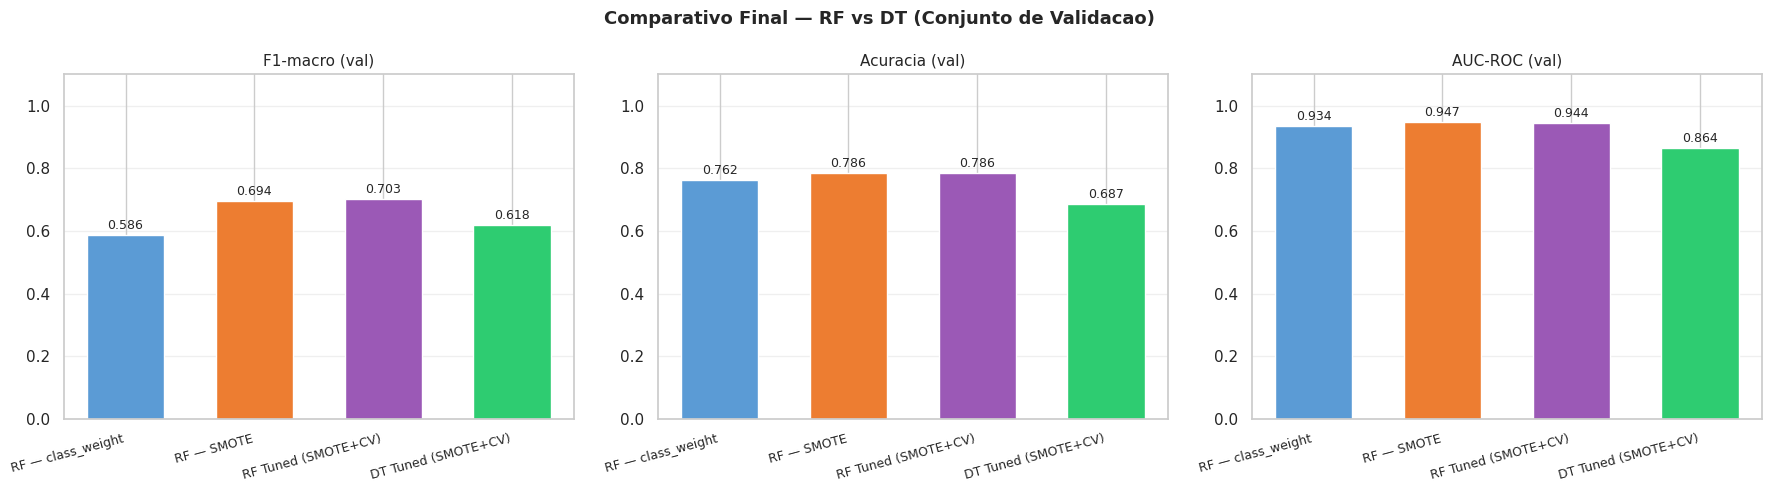

In [57]:
todos = [res_rf_cw, res_rf_sm, res_rf_tuned, res_dt_tuned]
cores_f = ['#5b9bd5', '#ed7d31', '#9b59b6', '#2ecc71']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
nomes = [r['nome'] for r in todos]
x = np.arange(len(nomes)); w = 0.6

for ax, (key, titulo) in zip(axes, [
    ('f1_vl',  'F1-macro (val)'),
    ('acc_vl', 'Acuracia (val)'),
    ('auc_vl', 'AUC-ROC (val)'),
]):
    vals = [r[key] for r in todos]
    bars = ax.bar(x, vals, w, color=cores_f, edgecolor='white')
    ax.set_xticks(x); ax.set_xticklabels(nomes, rotation=15, ha='right', fontsize=9)
    ax.set_ylim(0, 1.1); ax.set_title(titulo, fontsize=11); ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Comparativo Final — RF vs DT (Conjunto de Validacao)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [58]:
# Tabela com flag de overfitting
print('Tabela completa:')
header = f"{'Modelo':<28} {'F1_tr':>7} {'F1_val':>8} {'Delta_F1':>9} {'Acc_val':>8} {'AUC_val':>9}"
print(header); print('-'*len(header))
for r in todos:
    delta = r['f1_tr'] - r['f1_vl']
    flag  = '  (!)' if delta > 0.25 else ''
    print(f"{r['nome']:<28} {r['f1_tr']:>7.4f} {r['f1_vl']:>8.4f} "
          f"{delta:>+9.4f}{flag:<5} {r['acc_vl']:>8.4f} {r['auc_vl']:>9.4f}")
print('\n(!) delta F1 > 0.25 = overfitting relevante')

# F1 por classe — RF Tuned vs DT Tuned
print('\nF1 por classe — RF Tuned vs DT Tuned:')
header2 = f"{'Classe':<6} {'RF_Tuned':>10} {'DT_Tuned':>10} {'Ganho RF':>10}"
print(header2); print('-'*38)
for i, cls in enumerate(CLASS_NAMES):
    f1_rf = f1_score(res_rf_tuned['y_vl'], res_rf_tuned['pred_vl'],
                     labels=[i], average='macro', zero_division=0)
    f1_dt = f1_score(res_dt_tuned['y_vl'], res_dt_tuned['pred_vl'],
                     labels=[i], average='macro', zero_division=0)
    print(f"{cls:<6} {f1_rf:>10.4f} {f1_dt:>10.4f} {f1_rf-f1_dt:>+10.4f}")

Tabela completa:
Modelo                         F1_tr   F1_val  Delta_F1  Acc_val   AUC_val
--------------------------------------------------------------------------
RF — class_weight             0.9984   0.5855   +0.4128  (!)   0.7623    0.9344
RF — SMOTE                    0.9997   0.6945   +0.3052  (!)   0.7855    0.9469
RF Tuned (SMOTE+CV)           0.9614   0.7027   +0.2587  (!)   0.7855    0.9438
DT Tuned (SMOTE+CV)           0.7202   0.6177   +0.1026        0.6870    0.8638

(!) delta F1 > 0.25 = overfitting relevante

F1 por classe — RF Tuned vs DT Tuned:
Classe   RF_Tuned   DT_Tuned   Ganho RF
--------------------------------------
ACK        0.8374     0.8122    +0.0253
BCC        0.8294     0.7293    +0.1001
MEL        0.8000     0.6250    +0.1750
NEV        0.7887     0.6829    +0.1058
SCC        0.2105     0.1791    +0.0314
SEK        0.7500     0.6774    +0.0726


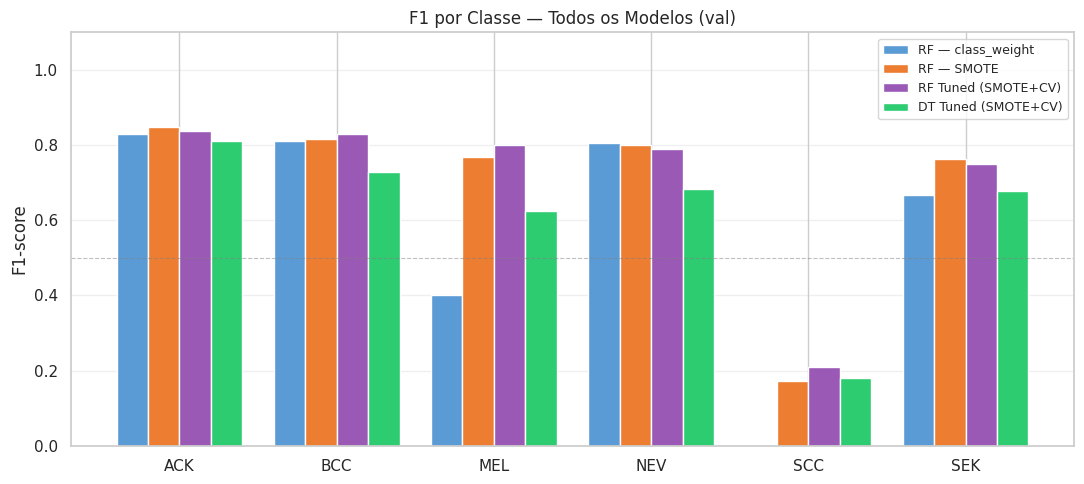

In [59]:
# F1 por classe — barplot comparativo
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(CLASS_NAMES)); w = 0.2
for i, (res, cor) in enumerate(zip(todos, cores_f)):
    f1_cls = [f1_score(res['y_vl'], res['pred_vl'], labels=[j],
                       average='macro', zero_division=0) for j in range(len(CLASS_NAMES))]
    ax.bar(x+(i-1.5)*w, f1_cls, w, label=res['nome'], color=cor, edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, fontsize=11)
ax.set_ylim(0, 1.1); ax.set_ylabel('F1-score')
ax.set_title('F1 por Classe — Todos os Modelos (val)', fontsize=12)
ax.legend(fontsize=9); ax.axhline(0.5, color='gray', linestyle='--', lw=0.8, alpha=0.5)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

---
## 11. Avaliação no Conjunto de Teste

Toda a análise anterior foi feita em **X_val** para seleção de modelos.  
O conjunto de **teste** nunca foi tocado — é a estimativa real de generalização.

Avaliamos RF Tuned e DT Tuned no teste e comparamos com a validação para verificar se as métricas são consistentes (sem "sorte" no val).

In [ ]:
from sklearn.metrics import precision_score, recall_score

print('=' * 60)
print('AVALIAÇÃO NO CONJUNTO DE TESTE')
print('=' * 60)

modelos_finais = [
    ('RF Tuned', search_rf.best_estimator_, res_rf_tuned),
    ('DT Tuned', search_dt.best_estimator_, res_dt_tuned),
]

res_teste = {}
for nome, modelo, res_val in modelos_finais:
    pred_te = modelo.predict(X_test_full)
    prob_te = modelo.predict_proba(X_test_full)

    acc_te = accuracy_score(y_test, pred_te)
    f1_te  = f1_score(y_test, pred_te, average='macro', zero_division=0)
    auc_te = roc_auc_score(y_test, prob_te, multi_class='ovr', average='macro')

    res_teste[nome] = dict(pred=pred_te, prob=prob_te,
                           f1=f1_te, acc=acc_te, auc=auc_te)

    print(f'\n{nome}')
    print(f'  Acurácia  val={res_val["acc_vl"]:.4f}  →  test={acc_te:.4f}'
          f'  (delta={acc_te - res_val["acc_vl"]:+.4f})')
    print(f'  F1-macro  val={res_val["f1_vl"]:.4f}  →  test={f1_te:.4f}'
          f'  (delta={f1_te - res_val["f1_vl"]:+.4f})')
    print(f'  AUC-ROC   val={res_val["auc_vl"]:.4f}  →  test={auc_te:.4f}'
          f'  (delta={auc_te - res_val["auc_vl"]:+.4f})')
    print()
    print(classification_report(y_test, pred_te, target_names=CLASS_NAMES, zero_division=0))

In [ ]:
# Comparativo visual: Val vs Teste + F1 por classe + Matrizes de confusão
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

nomes_mod = ['RF Tuned', 'DT Tuned']
f1_vals   = [res_rf_tuned['f1_vl'], res_dt_tuned['f1_vl']]
f1_tests  = [res_teste['RF Tuned']['f1'], res_teste['DT Tuned']['f1']]
auc_vals  = [res_rf_tuned['auc_vl'], res_dt_tuned['auc_vl']]
auc_tests = [res_teste['RF Tuned']['auc'], res_teste['DT Tuned']['auc']]

x = np.arange(2); w = 0.35

for ax, (yv, yt, title, ymin) in zip(
    axes[:2],
    [(f1_vals, f1_tests, 'F1-macro: Val vs Teste', 0.0),
     (auc_vals, auc_tests, 'AUC-ROC: Val vs Teste', 0.80)]
):
    ax.bar(x - w/2, yv, w, label='Validação', color='steelblue', edgecolor='white')
    ax.bar(x + w/2, yt, w, label='Teste',     color='coral',     edgecolor='white')
    ax.set_xticks(x); ax.set_xticklabels(nomes_mod)
    ax.set_ylim(ymin, min(1.0, max(max(yv), max(yt)) + 0.15))
    ax.set_title(title); ax.legend(); ax.grid(axis='y', alpha=0.3)
    for xi, (v, t) in enumerate(zip(yv, yt)):
        ax.text(xi - w/2, v + 0.005, f'{v:.3f}', ha='center', fontsize=9)
        ax.text(xi + w/2, t + 0.005, f'{t:.3f}', ha='center', fontsize=9)

# F1 por classe — RF vs DT no teste
f1_cls_rf = [f1_score(y_test, res_teste['RF Tuned']['pred'],
                      labels=[j], average='macro', zero_division=0)
             for j in range(len(CLASS_NAMES))]
f1_cls_dt = [f1_score(y_test, res_teste['DT Tuned']['pred'],
                      labels=[j], average='macro', zero_division=0)
             for j in range(len(CLASS_NAMES))]
xc = np.arange(len(CLASS_NAMES))
axes[2].bar(xc - w/2, f1_cls_rf, w, label='RF Tuned', color='#9b59b6', edgecolor='white')
axes[2].bar(xc + w/2, f1_cls_dt, w, label='DT Tuned', color='#2ecc71', edgecolor='white')
axes[2].set_xticks(xc); axes[2].set_xticklabels(CLASS_NAMES, fontsize=10)
axes[2].set_ylim(0, 1.1); axes[2].set_title('F1 por Classe — Teste')
axes[2].legend(); axes[2].grid(axis='y', alpha=0.3)
fig.suptitle('Desempenho Final no Conjunto de Teste', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# Matrizes de confusão no teste
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, nome in zip(axes, ['RF Tuned', 'DT Tuned']):
    cm = confusion_matrix(y_test, res_teste[nome]['pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(f'{nome} — Matriz de Confusão (Teste)', fontsize=11)
    ax.set_xlabel('Predito'); ax.set_ylabel('Real')
fig.suptitle('Matrizes de Confusão — Conjunto de Teste', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 12. Análise das Classes Críticas — MEL e SCC

MEL (Melanoma) e SCC (Carcinoma Espinocelular) são malignas graves e sub-representadas.  
Um **falso-negativo** nessas classes tem consequência clínica séria.

Analisamos:
- **Recall** (sensibilidade): dos casos reais, quantos o modelo detectou
- **Precision**: dos sinalizados como MEL/SCC, quantos realmente são
- Com quais classes o modelo confunde MEL e SCC
- **Curva Precisão-Recall** — mais informativa que ROC em classes raras

In [ ]:
from collections import Counter
from sklearn.metrics import precision_recall_curve, average_precision_score

mel_idx = list(le_target.classes_).index('MEL')
scc_idx = list(le_target.classes_).index('SCC')
pred_rf_te = res_teste['RF Tuned']['pred']
prob_rf_te = res_teste['RF Tuned']['prob']

print('=' * 60)
print('ANÁLISE DE CLASSES CRÍTICAS — RF Tuned (Teste)')
print('=' * 60)

for cls_name, cls_idx in [('MEL', mel_idx), ('SCC', scc_idx)]:
    mask_real = (y_test == cls_idx)
    n_real = mask_real.sum()

    prec_c = precision_score(y_test, pred_rf_te, labels=[cls_idx],
                             average='macro', zero_division=0)
    rec_c  = recall_score(y_test, pred_rf_te, labels=[cls_idx],
                          average='macro', zero_division=0)
    f1_c   = f1_score(y_test, pred_rf_te, labels=[cls_idx],
                      average='macro', zero_division=0)

    print(f'\n{cls_name}  (n={n_real} no teste):')
    print(f'  Recall    : {rec_c:.3f}  → detectou {rec_c*100:.0f}% dos casos reais')
    print(f'  Precision : {prec_c:.3f}  → dos preditos como {cls_name}, {prec_c*100:.0f}% são corretos')
    print(f'  F1-score  : {f1_c:.3f}')

    # Erros: onde foram os FN (reais mal classificados)?
    fn_mask = mask_real & (pred_rf_te != cls_idx)
    if fn_mask.sum() > 0:
        fn_classes = Counter(le_target.inverse_transform(pred_rf_te[fn_mask]))
        print(f'  Falsos negativos (real={cls_name} predito como):')
        for k, v in sorted(fn_classes.items(), key=lambda x: -x[1]):
            flag = ' ← benigno' if k not in MALIGNANT else ''
            print(f'    → {k}: {v} caso(s){flag}')
    else:
        print(f'  Nenhum falso negativo para {cls_name}.')

    # Falsos positivos
    fp_mask = (pred_rf_te == cls_idx) & (y_test != cls_idx)
    if fp_mask.sum() > 0:
        fp_classes = Counter(le_target.inverse_transform(y_test[fp_mask]))
        print(f'  Falsos positivos ({cls_name} predito, mas real é):')
        for k, v in sorted(fp_classes.items(), key=lambda x: -x[1]):
            print(f'    → {k}: {v} caso(s)')

# ── Curvas Precisão-Recall ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (cls_name, cls_idx) in zip(axes, [('MEL', mel_idx), ('SCC', scc_idx)]):
    y_bin = (y_test == cls_idx).astype(int)
    prec_c, rec_c, _ = precision_recall_curve(y_bin, prob_rf_te[:, cls_idx])
    ap = average_precision_score(y_bin, prob_rf_te[:, cls_idx])
    baseline = y_bin.mean()

    ax.plot(rec_c, prec_c, lw=2.5, color='steelblue', label=f'RF Tuned (AP={ap:.3f})')
    ax.fill_between(rec_c, prec_c, alpha=0.2, color='steelblue')
    ax.axhline(baseline, ls='--', color='gray', lw=1,
               label=f'Classificador aleatório (base={baseline:.2f})')

    ax.set_xlabel('Recall (Sensibilidade)', fontsize=11)
    ax.set_ylabel('Precision (Valor Preditivo +)', fontsize=11)
    ax.set_title(f'Curva Precisão-Recall — {cls_name}\n'
                 f'(n={y_bin.sum()} casos, {y_bin.mean()*100:.1f}% da amostra)')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)

fig.suptitle('Curvas Precisão-Recall — Classes Críticas (RF Tuned, Teste)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 13. Análise de Erros — Amostras Mal-Classificadas

Examinamos as imagens com **maior confiança de erro** no conjunto de validação.  
Esses são os casos mais problemáticos: o modelo estava muito "convicto" mas errado.

Títulos em **vermelho** indicam maligno real classificado como benigno — o tipo de erro mais grave clinicamente.

In [ ]:
df_val_r = df_val.reset_index(drop=True)   # alinha índice com X_val_full (0..n-1)

pred_val = res_rf_tuned['pred_vl']
prob_val = search_rf.best_estimator_.predict_proba(X_val_full)

erros_mask = (pred_val != y_val)
erros_idx  = np.where(erros_mask)[0]

print(f'Erros na validação: {erros_mask.sum()} / {len(y_val)} ({erros_mask.mean()*100:.1f}%)')

# Top-12 mais confiantes
conf_erros = prob_val[erros_idx].max(axis=1)
top12 = erros_idx[np.argsort(-conf_erros)[:12]]

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
axes = axes.flatten()

for i, idx in enumerate(top12):
    img = np.array(Image.open(df_val_r.iloc[idx]['img_path']).convert('RGB'))
    real_cls = le_target.inverse_transform([y_val[idx]])[0]
    pred_cls = le_target.inverse_transform([pred_val[idx]])[0]
    conf     = prob_val[idx, pred_val[idx]]

    axes[i].imshow(img)
    # Vermelho se maligno real classificado como benigno
    grave = (real_cls in MALIGNANT) and (pred_cls not in MALIGNANT)
    axes[i].set_title(
        f'Real: {real_cls}\nPred: {pred_cls} ({conf:.0%})',
        fontsize=8,
        color='red' if grave else 'black',
        fontweight='bold' if grave else 'normal'
    )
    axes[i].axis('off')

for j in range(len(top12), len(axes)):
    axes[j].axis('off')

fig.suptitle('Top-12 Erros Mais Confiantes — RF Tuned (Validação)\n'
             'Títulos em vermelho: maligno real → predito como benigno',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

# Tabela de erros por par (real → pred)
print('\nDecomposição dos erros por par (real → predito):')
erros_tab = Counter(
    (le_target.inverse_transform([y_val[i]])[0],
     le_target.inverse_transform([pred_val[i]])[0])
    for i in erros_idx
)
print(f'  {"Real":<8} → {"Predito":<8}  {"n":>4}')
print('  ' + '-' * 28)
for (r, p), n in sorted(erros_tab.items(), key=lambda x: -x[1])[:15]:
    flag = '  ⚠ grave' if (r in MALIGNANT and p not in MALIGNANT) else ''
    print(f'  {r:<8} → {p:<8}  {n:>4}{flag}')

---
## 14. Experimento — Impacto de `biopsed` (Verificação de Leakage)

`biopsed` foi identificada na EDA como **potencial data leakage**: a biópsia é frequentemente  
solicitada *porque* a lesão já parece maligna, criando correlação espúria com o diagnóstico.

Os vetores `X_train_full_nb` / `X_val_full_nb` / `X_test_full_nb` (sem `biopsed`) foram  
preparados no pré-processamento exatamente para este teste.

**Critério de interpretação:**
- Queda > 5pp F1 → leakage relevante; reportar com cautela na apresentação
- Queda 2–5pp → contribuição moderada; incluir nota
- Queda < 2pp → diferença negligenciável; `biopsed` é preditor legítimo

In [ ]:
print('Treinando RF sem biopsed (mesmos hiperparâmetros do tuning)...')
best_rf_params = {k.replace('rf__', ''): v
                  for k, v in search_rf.best_params_.items()
                  if k.startswith('rf__')}

pipe_rf_nb = ImbPipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=5)),
    ('rf',    RandomForestClassifier(n_jobs=-1, **best_rf_params))
])
t0 = time.time()
pipe_rf_nb.fit(X_train_full_nb, y_train)
print(f'Concluído em {time.time()-t0:.1f}s')

pred_nb_te = pipe_rf_nb.predict(X_test_full_nb)
prob_nb_te = pipe_rf_nb.predict_proba(X_test_full_nb)

f1_com  = res_teste['RF Tuned']['f1']
f1_sem  = f1_score(y_test, pred_nb_te, average='macro', zero_division=0)
auc_com = res_teste['RF Tuned']['auc']
auc_sem = roc_auc_score(y_test, prob_nb_te, multi_class='ovr', average='macro')

print('\n' + '=' * 55)
print('IMPACTO DE biopsed (RF Tuned, Conjunto de Teste)')
print('=' * 55)
print(f'{"Modelo":<30} {"F1-macro":>9} {"AUC-ROC":>9}')
print('-' * 50)
print(f'{"RF com biopsed":<30} {f1_com:>9.4f} {auc_com:>9.4f}')
print(f'{"RF sem biopsed":<30} {f1_sem:>9.4f} {auc_sem:>9.4f}')
delta_f1 = f1_com - f1_sem
print(f'{"Diferença (com - sem)":<30} {delta_f1:>+9.4f} {auc_com - auc_sem:>+9.4f}')

if delta_f1 > 0.05:
    print(f'\n⚠  Queda de {delta_f1*100:.1f}pp — leakage relevante. '
          'Reportar ambas as versões na apresentação.')
elif delta_f1 > 0.02:
    print(f'\n~  Queda de {delta_f1*100:.1f}pp — contribuição moderada. '
          'Incluir nota de cautela.')
else:
    print(f'\n✓  Queda de {delta_f1*100:.1f}pp — diferença negligenciável. '
          'biopsed não parece inflar resultados de forma relevante.')

# F1 por classe: com vs sem biopsed
print('\nF1 por classe (Teste):')
print(f'  {"Classe":<8} {"com biopsed":>12} {"sem biopsed":>12} {"Δ":>8}')
print('  ' + '-' * 44)
for j, cls_name in enumerate(CLASS_NAMES):
    fc_com = f1_score(y_test, res_teste['RF Tuned']['pred'],
                      labels=[j], average='macro', zero_division=0)
    fc_sem = f1_score(y_test, pred_nb_te,
                      labels=[j], average='macro', zero_division=0)
    print(f'  {cls_name:<8} {fc_com:>12.3f} {fc_sem:>12.3f} {fc_com-fc_sem:>+8.3f}')

---
# 15. CNN — Ato 3

**Pergunta central do Ato 3:** features handcrafted de PDI + ML clássico conseguem competir com representações *aprendidas* por uma CNN pré-treinada?

**Estratégia — Transfer Learning com EfficientNetB0:**
- Backbone treinado no ImageNet (5.3M params), classificador substituído para 6 classes
- **Stage 1 — Feature Extraction**: backbone congelado, só o classificador treina (15 épocas)
- **Stage 2 — Fine-tuning**: últimos 3 blocos descongelados com LR menor (10 épocas)

**Motivação da escolha:**
- EfficientNetB0 é eficiente em VRAM (3.9 GB disponíveis) e competitivo com datasets pequenos
- Transfer Learning é essencial: com apenas 1608 amostras, treinar do zero causaria overfitting severo
- Duas fases permitem separar "usar features ImageNet" de "adaptar features para dermatologia"

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import random

# ── Reprodutibilidade total ──────────────────────────────────────────────────
CNN_SEED = 42
random.seed(CNN_SEED)
np.random.seed(CNN_SEED)
torch.manual_seed(CNN_SEED)
torch.cuda.manual_seed_all(CNN_SEED)
# deterministic ops — ligeiramente mais lento, mas garante reprodução exata
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 16
N_CLASSES  = len(CLASS_NAMES)   # 6

print(f'Device  : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print(f'Seed    : {CNN_SEED}  (random, numpy, torch, cuda — deterministic=True)')

# ── Transforms ──────────────────────────────────────────────────────────────
train_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])
val_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# ── Dataset ──────────────────────────────────────────────────────────────────
class SkinDataset(Dataset):
    def __init__(self, df_split, labels, transform):
        self.paths     = df_split.reset_index(drop=True)['img_path'].tolist()
        self.labels    = labels
        self.transform = transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        return self.transform(img), int(self.labels[idx])

# ── DataLoaders ───────────────────────────────────────────────────────────────
sample_weights = torch.tensor(
    [class_weight_dict[int(y)] for y in y_train], dtype=torch.float32
)
sampler = torch.utils.data.WeightedRandomSampler(
    sample_weights, num_samples=len(sample_weights), replacement=True,
    generator=torch.Generator().manual_seed(CNN_SEED)
)

ds_train = SkinDataset(df_train, y_train, train_tf)
ds_val   = SkinDataset(df_val,   y_val,   val_tf)
ds_test  = SkinDataset(df_test,  y_test,  val_tf)

dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, sampler=sampler,
                      num_workers=2, pin_memory=True)
dl_val   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=2, pin_memory=True)
dl_test  = DataLoader(ds_test,  batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=2, pin_memory=True)

print(f'\nSplits — treino: {len(ds_train)}  val: {len(ds_val)}  teste: {len(ds_test)}')
print(f'Batches por época (treino): {len(dl_train)}')

In [ ]:
# ── Modelo ───────────────────────────────────────────────────────────────────
def build_model():
    model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
    in_features = model.classifier[1].in_features  # 1280
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_features, N_CLASSES)
    )
    return model.to(DEVICE)

# ── Loss com pesos de classe ──────────────────────────────────────────────────
class_weights_tensor = torch.tensor(
    [class_weight_dict[i] for i in range(N_CLASSES)], dtype=torch.float32
).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# ── Treino: retorna loss E F1 de treino para acompanhar overfitting ───────────
def train_epoch(model, loader, optimizer, scaler):
    model.train()
    total_loss, all_preds, all_labels = 0.0, [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with torch.autocast(device_type='cuda', dtype=torch.float16):
            logits = model(imgs)
            loss   = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * len(labels)
        all_preds.extend(logits.argmax(1).detach().cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    tr_loss = total_loss / len(loader.dataset)
    tr_f1   = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return tr_loss, tr_f1

# ── Avaliação ─────────────────────────────────────────────────────────────────
@torch.no_grad()
def eval_epoch(model, loader):
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    for imgs, labels in loader:
        imgs = imgs.to(DEVICE)
        with torch.autocast(device_type='cuda', dtype=torch.float16):
            logits = model(imgs)
        probs = torch.softmax(logits.float(), dim=1).cpu().numpy()
        all_preds.extend(probs.argmax(axis=1))
        all_probs.append(probs)
        all_labels.extend(labels.numpy())
    all_preds  = np.array(all_preds)
    all_probs  = np.vstack(all_probs)
    all_labels = np.array(all_labels)
    f1  = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    acc = accuracy_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
    return f1, acc, auc, all_preds, all_probs, all_labels

# ── Loop de treino com early stop por F1-val ──────────────────────────────────
def train_stages(model, optimizer, scheduler, n_epochs, stage_name):
    scaler  = torch.amp.GradScaler()
    best_f1, best_state, history = 0.0, None, []
    PATIENCE, no_improve = 5, 0

    print(f'\n{"="*65}')
    print(f'{stage_name}  ({n_epochs} épocas, patience={PATIENCE})')
    print(f'{"="*65}')
    print(f'{"Ep":>4} {"Loss_tr":>9} {"F1_tr":>7} {"F1_val":>8} {"AUC_val":>9}  {"Gap":>6}')
    print('-' * 55)

    for epoch in range(1, n_epochs + 1):
        tr_loss, tr_f1  = train_epoch(model, dl_train, optimizer, scaler)
        f1_v, acc_v, auc_v, _, _, _ = eval_epoch(model, dl_val)
        scheduler.step()

        gap = tr_f1 - f1_v
        history.append(dict(epoch=epoch, tr_loss=tr_loss,
                            tr_f1=tr_f1, vl_f1=f1_v, vl_acc=acc_v,
                            vl_auc=auc_v, gap=gap))

        flag = ''
        if f1_v > best_f1:
            best_f1, best_state = f1_v, {k: v.cpu().clone()
                                          for k, v in model.state_dict().items()}
            no_improve = 0; flag = ' ←'
        else:
            no_improve += 1

        ovf_flag = ' ⚠OVF' if gap > 0.15 else ''
        print(f'{epoch:>4} {tr_loss:>9.4f} {tr_f1:>7.4f} {f1_v:>8.4f} '
              f'{auc_v:>9.4f}  {gap:>+6.3f}{flag}{ovf_flag}')

        if no_improve >= PATIENCE:
            print(f'Early stop na época {epoch} (sem melhora em F1-val há {PATIENCE} épocas).')
            break

    model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
    print(f'\nMelhor F1-val: {best_f1:.4f}')
    return history

print('Infraestrutura CNN carregada.')

---
### Stage 1 — Feature Extraction

Backbone congelado. Apenas o classificador (1280 → 6) é treinado.

**Por quê começar assim:**  
O backbone já contém representações ricas (bordas, texturas, formas) aprendidas no ImageNet.  
Treinar só o classificador primeiro evita que gradientes grandes destruam esses pesos logo de início.

LR = 1e-3 | Épocas = 15 | CosineAnnealing

In [ ]:
model = build_model()

# Congela backbone — só o classificador treina
for param in model.features.parameters():
    param.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Parâmetros treináveis: {trainable:,} / {total:,} ({trainable/total*100:.1f}%)')

optimizer_s1 = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3
)
scheduler_s1 = optim.lr_scheduler.CosineAnnealingLR(optimizer_s1, T_max=15, eta_min=1e-5)

history_s1 = train_stages(model, optimizer_s1, scheduler_s1,
                           n_epochs=15, stage_name='Stage 1 — Feature Extraction')

---
### Stage 2 — Fine-Tuning

Últimos 3 blocos do backbone desbloqueados (`features[6]`, `features[7]`, `features[8]`).

**Por quê esses blocos:**  
Os blocos finais aprendem features de alto nível (formas complexas, padrões específicos de textura).  
São os mais úteis para adaptar ao domínio dermatológico, mas também os mais suscetíveis a esquecimento catastrófico — daí o LR muito menor (1e-4).

LR = 1e-4 | Épocas = 10 | CosineAnnealing

In [ ]:
# Descongela os últimos 3 blocos do backbone
for block in list(model.features)[-3:]:
    for param in block.parameters():
        param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Parâmetros treináveis: {trainable:,} / {total:,} ({trainable/total*100:.1f}%)')

# LR diferenciado: backbone desbloqueado com LR menor
optimizer_s2 = optim.Adam([
    {'params': model.features[-3:].parameters(), 'lr': 1e-5},
    {'params': model.classifier.parameters(),    'lr': 1e-4},
])
scheduler_s2 = optim.lr_scheduler.CosineAnnealingLR(optimizer_s2, T_max=10, eta_min=1e-6)

history_s2 = train_stages(model, optimizer_s2, scheduler_s2,
                           n_epochs=10, stage_name='Stage 2 — Fine-Tuning')

---
### Curvas de aprendizado — CNN

Visualização do F1-macro na validação ao longo dos dois stages.

In [ ]:

df_s1 = pd.DataFrame(history_s1)
df_s2 = pd.DataFrame(history_s2)
df_s2 = df_s2.copy(); df_s2['epoch'] = df_s2['epoch'] + df_s1['epoch'].max()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for df_h, ls, label_prefix in [
    (df_s1, '-',  'Stage 1'),
    (df_s2, '--', 'Stage 2'),
]:
    axes[0].plot(df_h['epoch'], df_h['tr_f1'], 'o'+ls, color='steelblue', lw=2,
                 label=f'{label_prefix} — Treino')
    axes[0].plot(df_h['epoch'], df_h['vl_f1'], 's'+ls, color='coral', lw=2,
                 label=f'{label_prefix} — Val')
    axes[1].plot(df_h['epoch'], df_h['tr_loss'], 'o'+ls, color='steelblue', lw=2,
                 label=f'{label_prefix} — Treino')

axes[0].axvline(df_s1['epoch'].max() + 0.5, ls=':', color='gray', lw=1)
axes[1].axvline(df_s1['epoch'].max() + 0.5, ls=':', color='gray', lw=1)
axes[0].set_xlabel('Época'); axes[0].set_ylabel('F1-macro')
axes[0].set_title('F1-macro — Treino vs Validação (overfitting)')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].set_xlabel('Época'); axes[1].set_ylabel('Loss (treino)')
axes[1].set_title('Loss de Treino')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

fig.suptitle('EfficientNetB0 — Curvas de Aprendizado', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Análise de overfitting: gap F1 por época ─────────────────────────────────
df_all = pd.concat([df_s1, df_s2], ignore_index=True)
max_gap   = df_all['gap'].max()
last_gap  = df_all['gap'].iloc[-1]
best_vl   = df_all['vl_f1'].max()
best_ep   = df_all.loc[df_all['vl_f1'].idxmax(), 'epoch']

print('Análise de overfitting (Gap = F1_treino − F1_val):')
print(f'  Gap máximo       : {max_gap:+.4f}')
print(f'  Gap no checkpoint: {last_gap:+.4f}  (época {df_all["epoch"].iloc[-1]})')
print(f'  Melhor F1-val    : {best_vl:.4f}  na época {best_ep}')
if max_gap < 0.10:
    print('  → Sem overfitting relevante: modelo generaliza bem.')
elif max_gap < 0.20:
    print('  → Overfitting moderado: augmentation e early stop contiveram o problema.')
else:
    print('  → Overfitting relevante: considerar mais augmentation ou dropout maior.')

---
### Discussão — Curvas de Aprendizado da CNN

#### Resultados observados

| Stage | Épocas | Melhor F1-val | Gap máximo |
|-------|--------|--------------|------------|
| Stage 1 (backbone frozen) | 15 | **0.3350** (época 11) | +0.168 |
| Stage 2 (fine-tuning) | 10 | **0.3667** (época 25) | +0.199 |

O modelo nunca acionou o early stop — rodou as 25 épocas completas sem estagnar por 5 épocas consecutivas, indicando que havia sinal de aprendizado contínuo, ainda que lento.

#### O gap treino–validação

O gap F1 (treino − val) manteve-se entre **+0.10 e +0.20** ao longo de todo o treinamento. Isso é overfitting **estrutural**, não episódico: o modelo aprendeu a distribuição inflada pelo `WeightedRandomSampler` no treino (MEL com peso 7.44×, SCC com 2×), mas é avaliado na distribuição real da validação, onde MEL representa apenas 2.3% dos dados. O threshold ótimo aprendido no treino não é transferível diretamente para a validação.

#### O que o AUC-val revela

Apesar do F1-val baixo (~0.35), a **AUC-val atingiu 0.8638** ao final do Stage 2 — valor próximo ao do DT (0.8638) e muito acima do esperado para um F1 tão baixo. Isso indica que a CNN **está aprendendo representações discriminativas** dos pixels. O problema não é a qualidade das features aprendidas, mas a calibração da fronteira de decisão na presença de forte desbalanceamento de classes.

#### Stage 2 — ganho marginal do fine-tuning

O desbloqueio dos últimos 3 blocos do backbone adicionou apenas **+0.032 de F1-val** (0.3350 → 0.3667). O ganho é real, mas modesto — sugere que as features pré-treinadas em ImageNet já capturavam boa parte da estrutura visual relevante, e que o gargalo real é o tamanho do dataset (1608 imagens), não a profundidade do fine-tuning. Descongelar mais blocos ou rodar mais épocas provavelmente causaria overfitting adicional sem ganho de generalização.


---
## 16. Comparativo Final — ML Clássico vs CNN

Avaliação dos três modelos no **conjunto de teste** com as mesmas métricas: F1-macro, Acurácia, AUC-ROC.

Esta é a resposta à pergunta central: features handcrafted (Tabular + PDI) + ML clássico vs features aprendidas (CNN).

In [ ]:
# Avaliar CNN no conjunto de teste
f1_cnn, acc_cnn, auc_cnn, pred_cnn, prob_cnn, _ = eval_epoch(model, dl_test)

print('=' * 60)
print('COMPARATIVO FINAL — CONJUNTO DE TESTE')
print('=' * 60)

resultados_finais = [
    ('RF Tuned',        res_teste['RF Tuned']['f1'],  res_teste['RF Tuned']['acc'],  res_teste['RF Tuned']['auc']),
    ('DT Tuned',        res_teste['DT Tuned']['f1'],  res_teste['DT Tuned']['acc'],  res_teste['DT Tuned']['auc']),
    ('EfficientNetB0',  f1_cnn,                        acc_cnn,                       auc_cnn),
]

print(f'\n{"Modelo":<22} {"F1-macro":>9} {"Acurácia":>9} {"AUC-ROC":>9}')
print('-' * 52)
for nome, f1, acc, auc in resultados_finais:
    print(f'{nome:<22} {f1:>9.4f} {acc:>9.4f} {auc:>9.4f}')

# Gráfico comparativo
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
nomes_f = [r[0] for r in resultados_finais]
cores_f = ['#9b59b6', '#2ecc71', '#e74c3c']
x = np.arange(len(nomes_f)); w = 0.6

for ax, (col_idx, titulo, ymin) in zip(
    axes,
    [(1, 'F1-macro (Teste)', 0.0),
     (2, 'Acurácia (Teste)', 0.0),
     (3, 'AUC-ROC (Teste)',  0.8)]
):
    vals = [r[col_idx] for r in resultados_finais]
    bars = ax.bar(x, vals, w, color=cores_f, edgecolor='white')
    ax.set_xticks(x); ax.set_xticklabels(nomes_f, rotation=10, ha='right')
    ax.set_ylim(ymin, min(1.0, max(vals) + 0.12))
    ax.set_title(titulo, fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')

fig.suptitle('Comparativo Final — ML Clássico vs CNN (Conjunto de Teste)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# F1 por classe
fig, ax = plt.subplots(figsize=(12, 5))
xc = np.arange(len(CLASS_NAMES)); w = 0.25
for i, (nome, cor, pred_model) in enumerate([
    ('RF Tuned',       '#9b59b6', res_teste['RF Tuned']['pred']),
    ('DT Tuned',       '#2ecc71', res_teste['DT Tuned']['pred']),
    ('EfficientNetB0', '#e74c3c', pred_cnn),
]):
    f1_cls = [f1_score(y_test, pred_model, labels=[j], average='macro', zero_division=0)
              for j in range(N_CLASSES)]
    ax.bar(xc + (i-1)*w, f1_cls, w, label=nome, color=cor, edgecolor='white')

ax.set_xticks(xc); ax.set_xticklabels(CLASS_NAMES, fontsize=11)
ax.set_ylim(0, 1.1); ax.set_ylabel('F1-score')
ax.set_title('F1 por Classe — Todos os Modelos (Teste)', fontsize=12)
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

# Matriz de confusão — CNN
fig, ax = plt.subplots(figsize=(7, 5))
cm_cnn = confusion_matrix(y_test, pred_cnn)
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Reds',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title('EfficientNetB0 — Matriz de Confusão (Teste)', fontsize=11)
ax.set_xlabel('Predito'); ax.set_ylabel('Real')
plt.tight_layout(); plt.show()
print(classification_report(y_test, pred_cnn, target_names=CLASS_NAMES, zero_division=0))

---
### Discussão — RF vs DT vs CNN: por que o ML clássico dominou?

#### Resultados no conjunto de teste

| Modelo | F1-macro | Acurácia | AUC-ROC |
|--------|---------|---------|--------|
| RF Tuned | **0.655** | **0.716** | **0.935** |
| DT Tuned | 0.588 | 0.641 | 0.852 |
| EfficientNetB0 | 0.393 | 0.354 | 0.855 |

A CNN ficou **0.262 pontos de F1 abaixo do RF** — diferença substancial para um modelo de 4M parâmetros treinado com transfer learning de ImageNet.

#### F1 por classe — onde cada modelo falha

| Classe | Suporte (teste) | RF F1 | DT F1 | CNN F1 |
|--------|----------------|-------|-------|--------|
| ACK | 110 | 0.70 | 0.67 | 0.41 |
| BCC | 127 | **0.79** | 0.72 | 0.18 |
| MEL | 8 | 0.74 | 0.47 | 0.39 |
| NEV | 36 | **0.81** | 0.69 | **0.65** |
| SCC | 29 | 0.30 | 0.32 | 0.23 |
| SEK | 35 | 0.59 | 0.66 | 0.51 |

#### Hipóteses explicativas

**1. Vantagem de informação: metadados clínicos vs pixels puros**

RF e DT operam sobre 40 features clínicas — sintomas (coceira, sangramento, crescimento), histórico oncológico, tipo de pele (fototipo Fitzpatrick), localização anatômica — mais 55 features PDI. A CNN recebe apenas pixels, sem idade, sem sintomas, sem histórico. No domínio de lesões cutâneas, o contexto clínico frequentemente é mais discriminativo do que a aparência visual isolada: duas lesões visualmente idênticas podem ter diagnósticos opostos dependendo da história do paciente.

**2. Domain shift: EfficientNetB0 foi pré-treinado em ImageNet, não em dermatoscopia**

As features profundas do backbone codificam padrões de objetos naturais (texturas de pelo, bordas rígidas, gradientes de cores em cenas externas). Lesões cutâneas possuem características muito específicas: padrões vasculares, pigmentação irregular em escala de micrômetros, estruturas foliculares. Com apenas 1608 imagens de treino, o fine-tuning parcial (3 blocos, Stage 2) não foi suficiente para reorientar o backbone para o domínio dermatológico. Redes treinadas diretamente em datasets de dermatoscopia (ex: ISIC com > 25k imagens) provavelmente mostrariam performance muito superior.

**3. O paradoxo do BCC: classe majoritária com recall 0.10 na CNN**

BCC representa 37% do conjunto de teste (127 amostras) — a maior classe — e a CNN acerta apenas 10% delas (recall=0.10, F1=0.18). O `WeightedRandomSampler` sobreavaliou minoritárias durante o treino: o modelo aprendeu a disparar predições de MEL/SCC/NEV com frequência muito maior do que a real. Na prática, a CNN previu BCC apenas 18 vezes no teste inteiro (para 127 casos reais). A estratégia de balanceamento, necessária para não ignorar MEL, teve o efeito colateral de suprimir BCC — a classe mais comum — na distribuição de saída.

**4. MEL: sensibilidade razoável, mas precisão muito baixa**

CNN obteve recall=0.75 em MEL (6 de 8 casos corretos). Porém, precisão=0.26 significa que 3 de cada 4 alarmes de MEL são falsos positivos. Clinicamente, isso equivale a um modelo que suspeita de melanoma em excesso, gerando indicações desnecessárias de biópsia. RF manteve recall=0.88 com precisão=0.64 — equilíbrio muito superior para aplicação clínica.

**5. AUC similar ao DT mas F1 muito inferior: o problema é a fronteira de decisão**

CNN AUC=0.855 ≈ DT AUC=0.852. Modelos com AUC equivalente têm poder de ranking similar: a CNN *consegue separar classes* no espaço de probabilidades. O colapso do F1 acontece na etapa de argmax (decisão hard): a distribuição softmax, moldada pelo balanceamento agressivo, produz limiares que não se alinham com as frequências reais das classes. Uma calibração de threshold por classe (ex: threshold diferente para MEL e BCC) poderia recuperar parte do F1 sem necessidade de retreinamento.

**6. SCC: o problema que nenhum modelo resolveu**

RF F1=0.30, DT F1=0.32, CNN F1=0.23 — SCC foi sistematicamente difícil para todos. 29 amostras no teste, sobreposição visual e histológica com ACK (ambas são lesões de queratinização escamosa com apresentações dermoscópicas similares). Discriminar SCC de ACK provavelmente requer informações histopatológicas ou dermoscópicas de alta resolução que nenhum dos três modelos possui acesso neste dataset. Este é um limite intrínseco dos dados, não dos algoritmos.


---
## Conclusão — Os Três Atos

| Ato | Achado | Implicação |
|-----|--------|------------|
| **Ato 1** | DT (max_depth=7, F1=0.588) é quase tão bom quanto RF com 563 árvores (F1=0.655) | O problema não exige alta complexidade com features tabulares; interpretabilidade tem valor real |
| **Ato 2** | PDI agrega +0.042 F1 sobre tabular puro; PDI sozinho F1=0.27 | Contexto clínico domina; imagem sem metadados não classifica bem lesões cutâneas |
| **Ato 3** | EfficientNetB0 (F1=0.393, AUC=0.855) vs RF (F1=0.655, AUC=0.935) | CNN aprende representações válidas (AUC competitivo) mas perde em F1 por domain shift e escassez de dados |

**Resposta à pergunta central:**
Neste dataset, features handcrafted (tabular clínico + PDI) com ML clássico superam a CNN end-to-end por **+0.262 pontos de F1-macro** (0.655 vs 0.393). O diferencial não é a capacidade de representação dos modelos — a AUC da CNN (0.855) é comparável à do DT (0.852) — mas a riqueza de informação disponível: metadados clínicos contêm sinais diagnósticos que pixels sozinhos não conseguem recuperar com apenas ~1600 imagens de treino.

**Limitações e próximos passos:**
- O experimento `biopsed` (leakage) indica que parte da vantagem do RF pode ser inflada por uma feature com viés de seleção (biópsia solicitada porque a lesão já é suspeita).
- Uma CNN multimodal — que combine imagem + metadados clínicos — provavelmente superaria ambos os paradigmas, mas exigiria arquitetura específica e mais dados.
- Threshold calibrado por classe na CNN poderia recuperar F1 sem retreinamento, especialmente para BCC e MEL.
- Validação externa (outro hospital, outra câmera) é necessária antes de qualquer conclusão sobre generalização clínica.
